# SD-WAN Bandwidth Analysis & Optimization — Single Hub Example

End-to-end pipeline untuk menganalisis penggunaan bandwidth interface pada sebuah hub SD-WAN (data statistik interface dari Cisco vManage): assessment, cleaning, feature engineering, EDA, prediksi bandwidth TX/RX (Random Forest, XGBoost, LightGBM), time series forecasting (SARIMAX), deteksi anomali berbasis threshold, dan rekomendasi alokasi bandwidth.

> ⚠️ **Data:** Data asli bersifat confidential dan tidak disertakan. Notebook ini dijalankan menggunakan **data sintetis** (`data/sample_hub_data.json`) yang memiliki struktur sama dengan data asli, sehingga angka dan grafik di bawah **bukan** hasil dari jaringan sebenarnya.

Setiap section menambahkan method baru ke class `BandwidthAnalyzer`; cell terakhir berisi pipeline lengkap.

## Import Packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Standard Libraries
import os
import json
from datetime import datetime
from pathlib import Path
import glob

# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Model Evaluation and Selection
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold, TimeSeriesSplit
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score, explained_variance_score,
    confusion_matrix
)

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model Persistence
import joblib

# Time Series Analysis
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope

# Optimization
from scipy.optimize import minimize

# Dashboard (optional, jika ingin membuat visualisasi interaktif)
import plotly.express as px
import plotly.graph_objects as go

## Load and Preview Data

In [2]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {
            'tx': None,
            'rx': None
        }
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}

    def load_data(self, file_path):
        # Memeriksa apakah file ada di lokasi yang ditentukan
        if os.path.exists(file_path):
            try:
                # Membaca file JSON dan menyimpannya ke dalam DataFrame
                with open(file_path, 'r') as file:
                    data = json.load(file)

                df = pd.json_normalize(data['data'])

                # Menampilkan pesan berhasil beserta jumlah baris data yang dimuat
                print(f"Data berhasil dimuat dari {file_path} dengan {len(df)} baris.")

                # Tampilkan beberapa data pertama untuk memastikan formatnya benar
                print("\nPreview data yang dimuat:")
                display(df.head(len(df)))

                # Preprocess data
                df_processed = self.preprocess_data(df)
                print("\nData setelah diproses:")
                display(df_processed.head(len(df)))

                # Menyimpan data yang telah diproses
                self.datasets['current'] = df_processed

                return df_processed

            except Exception as e:
                print(f"Terjadi kesalahan saat memuat file JSON {file_path}: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan. Silakan periksa jalur file.")
            return None

    def preprocess_data(self, df):
        try:
            # Convert timestamp to datetime
            df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Extract temporal features
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            # Encode categorical variables
            df['interface_encoded'] = self.label_encoder.fit_transform(df['interface'])

            print("Preprocessing berhasil dilakukan.")
            return df

        except KeyError as e:
            print(f"Kolom {str(e)} tidak ditemukan dalam dataset.")
            return None
        except Exception as e:
            print(f"Terjadi kesalahan saat preprocessing data: {str(e)}")
            return None

    def prepare_time_series(self, df=None):
        # Tambahkan indentasi untuk baris setelah if
        if df is None:
            df = self.datasets['current']  # Tambahkan indentasi di sini

        ts_data = df.set_index('entry_time')
        ts_data = ts_data.resample('h').agg({
            'tx_kbps': 'mean',
            'rx_kbps': 'mean'
        }).ffill()  # Ganti .ffill() dengan .ffill()

        return ts_data

    def train_time_series_model(self, feature='tx_kbps', forecast_horizon=24): # Indent this function to make it part of the class
        ts_data = self.prepare_time_series()

        # Bagi data untuk training dan testing
        train_size = int(len(ts_data) * 0.8)
        train_data = ts_data[:train_size]
        test_data = ts_data[train_size:]

        # Fit SARIMAX model
        model = SARIMAX(train_data[feature],
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 24))
        results = model.fit()

        # Simpan model
        self.models[feature] = results

        return results, train_data, test_data

    def calculate_thresholds(self, df=None):
        if df is None:
            df = self.datasets['current']

        self.thresholds = {
            'tx': {
                'critical': df['tx_kbps'].quantile(0.95),
                'warning': df['tx_kbps'].quantile(0.75),
                'normal': df['tx_kbps'].quantile(0.50)
            },
            'rx': {
                'critical': df['rx_kbps'].quantile(0.95),
                'warning': df['rx_kbps'].quantile(0.75),
                'normal': df['rx_kbps'].quantile(0.50)
            }
        }
        return self.thresholds

    def detect_anomalies(self, new_data):
        if not hasattr(self, 'thresholds'):
            self.calculate_thresholds()

        anomalies = pd.DataFrame()
        anomalies['timestamp'] = new_data['entry_time']

        for metric in ['tx', 'rx']:
            column = f'{metric}_kbps'
            anomalies[f'{metric}_status'] = 'normal'

            mask_critical = new_data[column] > self.thresholds[metric]['critical']
            mask_warning = new_data[column] > self.thresholds[metric]['warning']

            anomalies.loc[mask_critical, f'{metric}_status'] = 'critical'
            anomalies.loc[mask_warning & ~mask_critical, f'{metric}_status'] = 'warning'

        return anomalies

    def optimize_bandwidth(self, current_usage, interface_capacity=1000000):
        if not hasattr(self, 'thresholds'):
            self.calculate_thresholds()

        def get_allocation_rules(usage_level):
            rules = {
                'critical': {'high_priority': 0.6, 'medium_priority': 0.3, 'low_priority': 0.1},
                'warning': {'high_priority': 0.5, 'medium_priority': 0.35, 'low_priority': 0.15},
                'normal': {'high_priority': 0.4, 'medium_priority': 0.4, 'low_priority': 0.2}
            }
            return rules[usage_level]

        # Tentukan level penggunaan
        if current_usage > self.thresholds['tx']['critical']:
            level = 'critical'
        elif current_usage > self.thresholds['tx']['warning']:
            level = 'warning'
        else:
            level = 'normal'

        # Hitung alokasi bandwidth
        rules = get_allocation_rules(level)
        allocation = {
            category: int(percentage * interface_capacity)
            for category, percentage in rules.items()
        }

        return allocation

def print_analysis_results(self, thresholds, anomalies, optimized_allocation):
        print("\n Hasil Analisis Bandwidth:")
        print("\n Threshold Bandwidth:")
        print("Transmisi (TX):")
        print(f"  - Kritis    : {thresholds['tx']['critical']:.2f} kbps")
        print(f"  - Peringatan: {thresholds['tx']['warning']:.2f} kbps")
        print(f"  - Normal    : {thresholds['tx']['normal']:.2f} kbps")

        print("\nPenerima (RX):")
        print(f"  - Kritis    : {thresholds['rx']['critical']:.2f} kbps")
        print(f"  - Peringatan: {thresholds['rx']['warning']:.2f} kbps")
        print(f"  - Normal    : {thresholds['rx']['normal']:.2f} kbps")

        print("\n⚠️ Anomali:")
        anomaly_count = {
            'tx_critical': len(anomalies[anomalies['tx_status'] == 'critical']),
            'rx_critical': len(anomalies[anomalies['rx_status'] == 'critical']),
            'tx_warning': len(anomalies[anomalies['tx_status'] == 'warning']),
            'rx_warning': len(anomalies[anomalies['rx_status'] == 'warning'])
        }

        print(f"  - TX Kritis   : {anomaly_count['tx_critical']} kejadian")
        print(f"  - RX Kritis   : {anomaly_count['rx_critical']} kejadian")
        print(f"  - TX Peringatan: {anomaly_count['tx_warning']} kejadian")
        print(f"  - RX Peringatan: {anomaly_count['rx_warning']} kejadian")

        print("\n Rekomendasi Alokasi Bandwidth:")
        for priority, value in optimized_allocation.items():
            print(f"  - {priority.replace('_', ' ').title()}: {value} kbps")

def main():
    analyzer = BandwidthAnalyzer()

    # Load single file
    single_file_path = '../data/sample_hub_data.json'
    df_single = analyzer.load_data(single_file_path)

    if df_single is not None:
        # Time series analysis
        model, train_data, test_data = analyzer.train_time_series_model()

        # Threshold monitoring
        thresholds = analyzer.calculate_thresholds()
        anomalies = analyzer.detect_anomalies(df_single)

        # Bandwidth optimization
        current_usage = df_single['tx_kbps'].iloc[-1]
        optimized_allocation = analyzer.optimize_bandwidth(current_usage)

        # Cetak hasil analisis dalam format yang mudah dibaca
        print("\nHasil Analisis Bandwidth:")
        print("\nThreshold Bandwidth:")
        print("Transmisi (TX):")
        print(f"  - Kritis    : {thresholds['tx']['critical']:.2f} kbps")
        print(f"  - Peringatan: {thresholds['tx']['warning']:.2f} kbps")
        print(f"  - Normal    : {thresholds['tx']['normal']:.2f} kbps")

        print("\nPenerima (RX):")
        print(f"  - Kritis    : {thresholds['rx']['critical']:.2f} kbps")
        print(f"  - Peringatan: {thresholds['rx']['warning']:.2f} kbps")
        print(f"  - Normal    : {thresholds['rx']['normal']:.2f} kbps")

        print("\nAnomali:")
        anomali_kritis_tx = len(anomalies[anomalies['tx_status'] == 'critical'])
        print(f"  - Jumlah Anomali Kritis (TX): {anomali_kritis_tx}")

        print("\nRekomendasi Alokasi Bandwidth:")
        for prioritas, nilai in optimized_allocation.items():
            print(f"  - {prioritas.replace('_', ' ').title()}: {nilai} kbps")
    else:
        print("\nTidak dapat melanjutkan analisis karena data tidak tersedia.")

if __name__ == "__main__":
    main()

Data berhasil dimuat dari ../data/sample_hub_data.json dengan 240 baris.

Preview data yang dimuat:


,entry_time,count,interface,tx_kbps,rx_kbps
0,1709251200000,256,10ge0/0,932.264518,1.000000
1,1709251200000,256,ge2/0,918.748284,4332.056121
2,1709251200000,256,ge2/1,1057.202896,5246.912010
3,1709251200000,256,mgmt0,0.000000,10.995078
4,1709251200000,256,system,0.000000,0.000000
...,...,...,...,...,...
235,1713312000000,254,10ge0/0,1178.076161,1.000000
236,1713312000000,254,ge2/0,1275.203869,6047.442916
237,1713312000000,254,ge2/1,1577.240589,5453.066396
238,1713312000000,254,mgmt0,0.000000,11.008055


Preprocessing berhasil dilakukan.

Data setelah diproses:


,entry_time,count,interface,tx_kbps,rx_kbps,hour,day_of_week,is_weekend,month,interface_encoded
0,2024-03-01,256,10ge0/0,932.264518,1.000000,0,4,0,3,0
1,2024-03-01,256,ge2/0,918.748284,4332.056121,0,4,0,3,1
2,2024-03-01,256,ge2/1,1057.202896,5246.912010,0,4,0,3,2
3,2024-03-01,256,mgmt0,0.000000,10.995078,0,4,0,3,3
4,2024-03-01,256,system,0.000000,0.000000,0,4,0,3,4
...,...,...,...,...,...,...,...,...,...,...
235,2024-04-17,254,10ge0/0,1178.076161,1.000000,0,2,0,4,0
236,2024-04-17,254,ge2/0,1275.203869,6047.442916,0,2,0,4,1
237,2024-04-17,254,ge2/1,1577.240589,5453.066396,0,2,0,4,2
238,2024-04-17,254,mgmt0,0.000000,11.008055,0,2,0,4,3



Hasil Analisis Bandwidth:

Threshold Bandwidth:
Transmisi (TX):
  - Kritis    : 1371.33 kbps
  - Peringatan: 1062.40 kbps
  - Normal    : 592.49 kbps

Penerima (RX):
  - Kritis    : 6850.67 kbps
  - Peringatan: 4855.34 kbps
  - Normal    : 11.00 kbps

Anomali:
  - Jumlah Anomali Kritis (TX): 12

Rekomendasi Alokasi Bandwidth:
  - High Priority: 400000 kbps
  - Medium Priority: 400000 kbps
  - Low Priority: 200000 kbps


## Assessing Data


Preprocessing berhasil dilakukan.

=== Melakukan Penilaian Data Komprehensif ===
=== Struktur Data ===
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   entry_time         240 non-null    datetime64[ms]
 1   count              240 non-null    int64         
 2   interface          240 non-null    str           
 3   tx_kbps            240 non-null    float64       
 4   rx_kbps            240 non-null    float64       
 5   hour               240 non-null    int32         
 6   day_of_week        240 non-null    int32         
 7   is_weekend         240 non-null    int64         
 8   month              240 non-null    int32         
 9   interface_encoded  240 non-null    int64         
dtypes: datetime64[ms](1), float64(2), int32(3), int64(3), str(1)
memory usage: 16.1 KB
None

=== Statistik Deskriptif ===
                entr

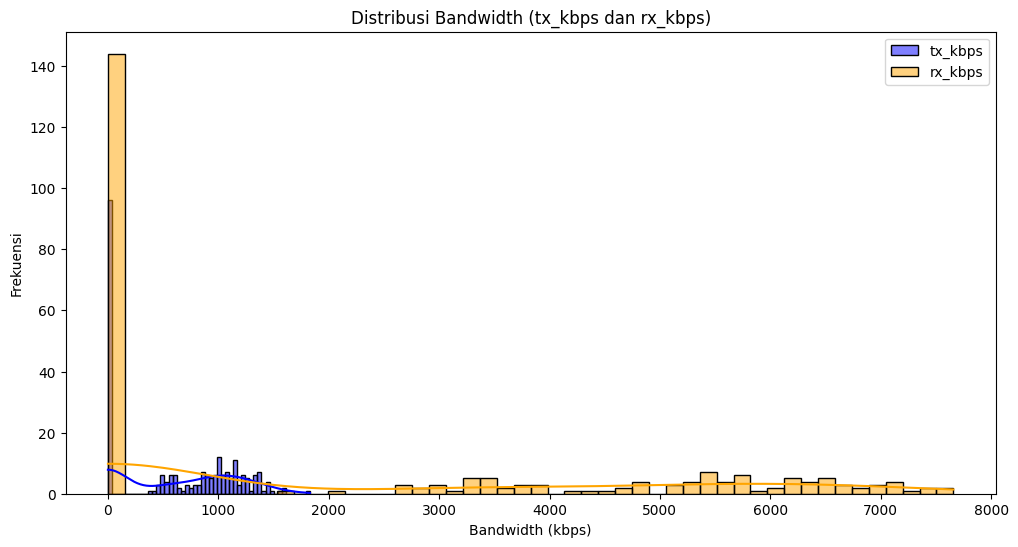


=== Analisis Pola Temporal ===


<Figure size 1200x600 with 0 Axes>

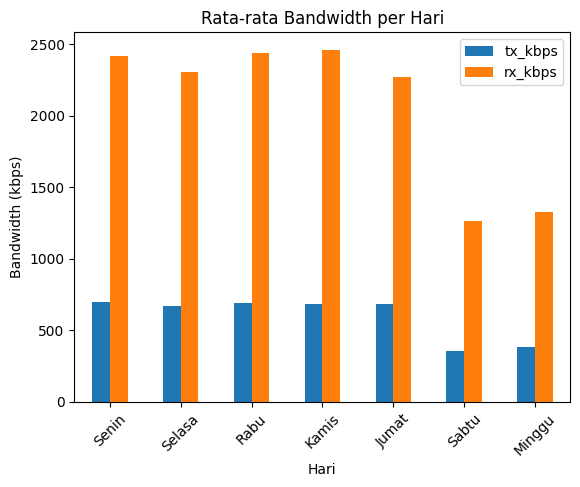


=== Analisis Pola Bandwidth ===

Statistik Penggunaan Bandwidth:
Rata-rata: 2651.74 kbps
Maksimum: 9203.15 kbps
Minimum: 0.00 kbps
Standar Deviasi: 3106.36 kbps
Median: 955.42 kbps

=== Analisis Korelasi ===


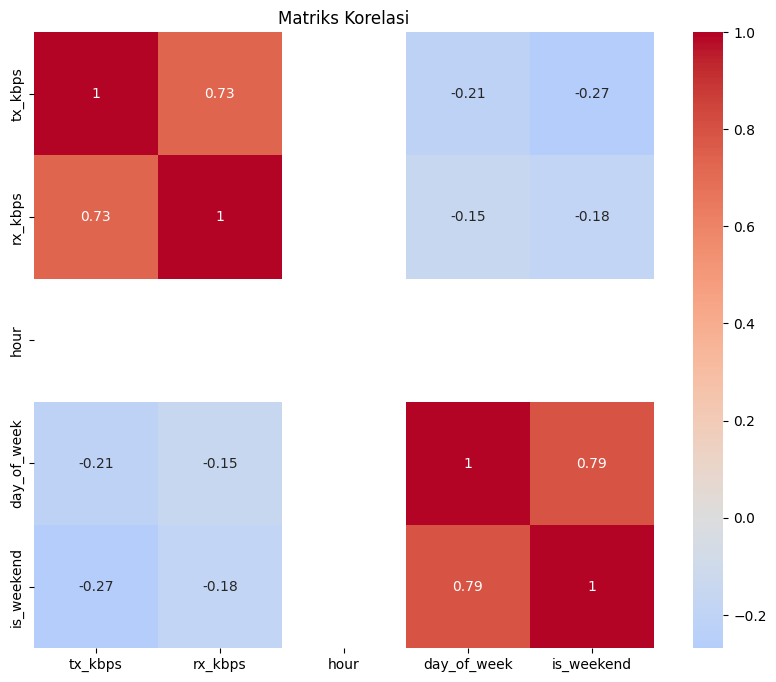

In [3]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {
            'tx': None,
            'rx': None
        }
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}

    def load_data(self, file_path):
        # Memeriksa apakah file ada di lokasi yang ditentukan
        if os.path.exists(file_path):
            try:
                # Membaca file JSON dan menyimpannya ke dalam DataFrame
                with open(file_path, 'r') as file:
                    data = json.load(file)

                df = pd.json_normalize(data['data'])  # Pastikan sesuai dengan struktur JSON
                return df

            except Exception as e:
                print(f"Terjadi kesalahan saat memuat file JSON {file_path}: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan. Silakan periksa jalur file.")
            return None

    def preprocess_data(self, df):
        try:
            # Convert timestamp to datetime
            df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Extract temporal features
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            # Encode categorical variables
            df['interface_encoded'] = self.label_encoder.fit_transform(df['interface'])

            print("Preprocessing berhasil dilakukan.")
            return df

        except KeyError as e:
            print(f"Kolom {str(e)} tidak ditemukan dalam dataset.")
            return None
        except Exception as e:
            print(f"Terjadi kesalahan saat preprocessing data: {str(e)}")
            return None

    def assess_data(self, df):
        """Melakukan analisis komprehensif terhadap data bandwidth"""
        print("=== Struktur Data ===")
        print(df.info())

        print("\n=== Statistik Deskriptif ===")
        print(df.describe())

        print("\n=== Nilai Kosong (Missing Values) ===")
        missing_values = df.isnull().sum()
        print(missing_values)

        # Visualisasi distribusi bandwidth
        print("\n=== Distribusi Kolom Bandwidth (tx_kbps & rx_kbps) ===")
        plt.figure(figsize=(12, 6))
        sns.histplot(df['tx_kbps'], kde=True, color='blue', bins=50, label='tx_kbps')
        sns.histplot(df['rx_kbps'], kde=True, color='orange', bins=50, label='rx_kbps')
        plt.legend()
        plt.title("Distribusi Bandwidth (tx_kbps dan rx_kbps)")
        plt.xlabel("Bandwidth (kbps)")
        plt.ylabel("Frekuensi")
        plt.show()

        # Panggil method analisis lainnya
        self._assess_temporal_patterns(df)
        self._assess_bandwidth_patterns(df)
        self._assess_correlations(df)

    def _assess_temporal_patterns(self, df):
        print("\n=== Analisis Pola Temporal ===")

        # Daily patterns
        daily_avg = df.groupby('day_of_week')[['tx_kbps', 'rx_kbps']].mean()
        daily_avg.index = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
        plt.figure(figsize=(12, 6))
        daily_avg.plot(kind='bar')
        plt.title("Rata-rata Bandwidth per Hari")
        plt.xlabel("Hari")
        plt.ylabel("Bandwidth (kbps)")
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()

    def _assess_bandwidth_patterns(self, df):
        print("\n=== Analisis Pola Bandwidth ===")

        # Calculate total bandwidth
        df['total_kbps'] = df['tx_kbps'] + df['rx_kbps']

        # Bandwidth utilization statistics
        print("\nStatistik Penggunaan Bandwidth:")
        utilization_stats = {
            'Rata-rata': df['total_kbps'].mean(),
            'Maksimum': df['total_kbps'].max(),
            'Minimum': df['total_kbps'].min(),
            'Standar Deviasi': df['total_kbps'].std(),
            'Median': df['total_kbps'].median()
        }
        for metric, value in utilization_stats.items():
            print(f"{metric}: {value:.2f} kbps")

    def _assess_correlations(self, df):
        print("\n=== Analisis Korelasi ===")
        correlation = df[['tx_kbps', 'rx_kbps', 'hour', 'day_of_week', 'is_weekend']].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
        plt.title('Matriks Korelasi')
        plt.show()

def main():
    analyzer = BandwidthAnalyzer()

    # Load single file
    single_file_path = '../data/sample_hub_data.json'
    df_single = analyzer.load_data(single_file_path)

    if df_single is not None:
        # Preprocess data
        df_processed = analyzer.preprocess_data(df_single)

        if df_processed is not None:
            print("\n=== Melakukan Penilaian Data Komprehensif ===")
            analyzer.assess_data(df_processed)
        else:
            print("Gagal melakukan preprocessing data.")
    else:
        print("Gagal memuat data.")

if __name__ == "__main__":
    main()

## Cleaning Data

In [4]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {
            'tx': None,
            'rx': None
        }
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()

    def load_data(self, file_path):
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan. Silakan periksa jalur file.")
            return None

    def assess_data(self, df):
        """Melakukan penilaian awal pada data"""
        try:
            # Konversi entry_time ke datetime
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Menambahkan fitur temporal
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            print("\n=== Data Assessment Complete ===")
            return df

        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        try:
            print("=== Proses Cleaning Data ===")

            # 1. Menghapus duplikasi
            print("\n1. Menghapus duplikasi...")
            initial_rows = len(df)
            df_cleaned = df.drop_duplicates()
            print(f"Duplikat dihapus: {initial_rows - len(df_cleaned)} baris")

            # 2. Menyaring interface
            print("\n2. Menyaring data berdasarkan interface...")
            initial_rows = len(df_cleaned)
            allowed_interfaces = ['10ge0/0', 'ge2/0', 'ge2/1', 'mgmt0']
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(allowed_interfaces)]
            print(f"Data interface difilter: {initial_rows - len(df_cleaned)} baris dihapus")

            # 3. Menangani outlier
            print("\n3. Menangani outlier dengan metode IQR...")
            initial_rows = len(df_cleaned)

            # Hitung IQR untuk tx_kbps dan rx_kbps
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1

            # Filter outlier
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                    (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]
            print(f"Outlier dihapus: {initial_rows - len(df_cleaned)} baris")

            # 4. Standardisasi data numerik
            print("\n4. Melakukan standardisasi data...")
            numeric_columns = ['tx_kbps', 'rx_kbps']
            df_cleaned[numeric_columns] = self.scaler.fit_transform(df_cleaned[numeric_columns])

            # 5. Tambahkan total bandwidth
            df_cleaned['total_kbps'] = df_cleaned['tx_kbps'] + df_cleaned['rx_kbps']

            print("\n=== Ringkasan Hasil Cleaning ===")
            print(f"Total baris akhir: {len(df_cleaned)}")
            print(f"Kolom yang tersedia: {', '.join(df_cleaned.columns)}")

            return df_cleaned

        except Exception as e:
            print(f"Error dalam cleaning data: {e}")
            return None

    def process_data(self, file_path):
        """Method utama untuk memproses data dari awal sampai akhir"""
        try:
            # Load data
            print("Loading data...")
            df = self.load_data(file_path)
            if df is None:
                return None

            # Assess data
            print("\nAssessing data...")
            df_assessed = self.assess_data(df)
            if df_assessed is None:
                return None

            # Clean data
            print("\nCleaning data...")
            df_cleaned = self.clean_data(df_assessed)
            if df_cleaned is None:
                return None

            # Simpan data yang sudah diproses
            self.datasets['processed'] = df_cleaned

            return df_cleaned

        except Exception as e:
            print(f"Error in data processing: {e}")
            return None

def main():
    analyzer = BandwidthAnalyzer()
    file_path = '../data/sample_hub_data.json'

    # Proses data
    df_processed = analyzer.process_data(file_path)

    if df_processed is not None:
        print("\n=== Hasil Pemrosesan Data ===")
        print("\nInformasi Dataset:")
        display(df_processed.info())

        print("\nStatistik Deskriptif:")
        display(df_processed.describe())

        print("\nSample Data:")
        display(df_processed.head(len(df_processed)))
    else:
        print("Pemrosesan data gagal.")

if __name__ == "__main__":
    main()

Loading data...

Assessing data...

=== Data Assessment Complete ===

Cleaning data...
=== Proses Cleaning Data ===

1. Menghapus duplikasi...
Duplikat dihapus: 0 baris

2. Menyaring data berdasarkan interface...
Data interface difilter: 48 baris dihapus

3. Menangani outlier dengan metode IQR...
Outlier dihapus: 0 baris

4. Melakukan standardisasi data...

=== Ringkasan Hasil Cleaning ===
Total baris akhir: 192
Kolom yang tersedia: entry_time, count, interface, tx_kbps, rx_kbps, hour, day_of_week, is_weekend, month, total_kbps

=== Hasil Pemrosesan Data ===

Informasi Dataset:
<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 238
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   entry_time   192 non-null    datetime64[ms]
 1   count        192 non-null    int64         
 2   interface    192 non-null    str           
 3   tx_kbps      192 non-null    float64       
 4   rx_kbps      192 non-null  

None


Statistik Deskriptif:


,entry_time,count,tx_kbps,rx_kbps,hour,day_of_week,is_weekend,month,total_kbps
count,192,192.000000,1.920000e+02,1.920000e+02,192.0,192.000000,192.000000,192.000000,192.000000
mean,2024-03-24 12:00:00,279.979167,-5.551115e-17,5.088522e-17,0.0,3.000000,0.291667,3.354167,0.000000
min,2024-03-01 00:00:00,254.000000,-1.479280e+00,-9.276657e-01,0.0,0.000000,0.000000,3.000000,-2.403350
25%,2024-03-12 18:00:00,275.750000,-8.993716e-01,-9.249695e-01,0.0,1.000000,0.000000,3.000000,-1.826135
50%,2024-03-24 12:00:00,281.500000,2.726224e-01,-6.280017e-01,0.0,3.000000,0.000000,3.000000,-0.134894
75%,2024-04-05 06:00:00,286.000000,8.024354e-01,1.020429e+00,0.0,5.000000,1.000000,4.000000,1.746243
max,2024-04-17 00:00:00,291.000000,2.180293e+00,1.832076e+00,0.0,6.000000,1.000000,4.000000,3.484926
std,NaN,7.988184,1.002614e+00,1.002614e+00,0.0,2.026009,0.455718,0.479510,1.833565



Sample Data:


,entry_time,count,interface,tx_kbps,rx_kbps,hour,day_of_week,is_weekend,month,total_kbps
0,2024-03-01,256,10ge0/0,0.385024,-0.927666,0,4,0,3,-0.542642
1,2024-03-01,256,ge2/0,0.357994,0.633270,0,4,0,3,0.991264
2,2024-03-01,256,ge2/1,0.634870,0.962989,0,4,0,3,1.597859
3,2024-03-01,256,mgmt0,-1.479280,-0.924063,0,4,0,3,-2.403343
5,2024-03-02,283,10ge0/0,-0.557606,-0.927666,0,5,1,3,-1.485272
...,...,...,...,...,...,...,...,...,...,...
233,2024-04-16,278,mgmt0,-1.479280,-0.924064,0,1,0,4,-2.403344
235,2024-04-17,254,10ge0/0,0.876587,-0.927666,0,2,0,4,-0.051078
236,2024-04-17,254,ge2/0,1.070819,1.251504,0,2,0,4,2.322323
237,2024-04-17,254,ge2/1,1.674820,1.037288,0,2,0,4,2.712107


## Feature Engineering

In [5]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {
            'tx': None,
            'rx': None
        }
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()
        self.interface_capacity = {
            '10ge0/0': 10000,
            'ge2/0': 10000,
            'ge2/1': 10000,
            'mgmt0': 10000
        }

    def load_data(self, file_path):
        """Load data dari file JSON"""
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                print(f"Data berhasil dimuat: {len(df)} baris")
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan")
            return None

    def assess_data(self, df):
        try:
            # Konversi entry_time ke datetime
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Fitur temporal dasar
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            print("Data assessment selesai")
            return df
        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        """Membersihkan data"""
        try:
            print("=== Proses Cleaning Data ===")

            # Hapus duplikasi
            initial_rows = len(df)
            df_cleaned = df.drop_duplicates()
            print(f"Duplikat dihapus: {initial_rows - len(df_cleaned)} baris")

            # Filter interface
            initial_rows = len(df_cleaned)
            allowed_interfaces = ['10ge0/0', 'ge2/0', 'ge2/1', 'mgmt0']
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(allowed_interfaces)]
            print(f"Data interface difilter: {initial_rows - len(df_cleaned)} baris dihapus")

            # Handle outliers dengan IQR
            initial_rows = len(df_cleaned)
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                    (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]
            print(f"Outlier dihapus: {initial_rows - len(df_cleaned)} baris")

            print("Cleaning data selesai")
            return df_cleaned
        except Exception as e:
            print(f"Error in data cleaning: {e}")
            return None

    def feature_engineering(self, df):
        """Melakukan feature engineering"""
        try:
            print("\n=== Feature Engineering ===")

            # Bandwidth Features
            print("Menambahkan fitur bandwidth...")
            df['total_kbps'] = df['tx_kbps'] + df['rx_kbps']
            df['tx_rx_ratio'] = df['tx_kbps'] / df['rx_kbps'].replace(0, 1)

            # Usage Features
            print("Menambahkan fitur penggunaan...")
            df['usage_percentage'] = df.apply(
                lambda row: (row['total_kbps'] / self.interface_capacity.get(row['interface'], 10000)) * 100,
                axis=1
            )

            # Time-based Features
            print("Menambahkan fitur waktu...")
            df['time_since_last_entry'] = df.groupby('interface')['entry_time'].diff().dt.total_seconds().fillna(0)

            # Change Features
            print("Menambahkan fitur perubahan...")
            for col in ['tx_kbps', 'rx_kbps', 'total_kbps']:
                df[f'{col}_change'] = df.groupby('interface')[col].diff().fillna(0)
                df[f'{col}_pct_change'] = df.groupby('interface')[col].pct_change().fillna(0)

            # Kategori penggunaan
            df['usage_category'] = pd.cut(df['usage_percentage'],
                                        bins=[0, 20, 40, 60, 80, 100],
                                        labels=['very_low', 'low', 'medium', 'high', 'very_high'])

            print("Feature engineering selesai")
            return df

        except Exception as e:
            print(f"Error in feature engineering: {e}")
            return None

    def process_data(self, file_path):
        """Proses utama data"""
        try:
            # Load data
            print("Loading data...")
            df = self.load_data(file_path)
            if df is None:
                return None

            # Assess data
            print("\nAssessing data...")
            df_assessed = self.assess_data(df)
            if df_assessed is None:
                return None

            # Clean data
            print("\nCleaning data...")
            df_cleaned = self.clean_data(df_assessed)
            if df_cleaned is None:
                return None

            # Feature engineering
            print("\nPerforming feature engineering...")
            df_engineered = self.feature_engineering(df_cleaned)
            if df_engineered is None:
                return None

            self.datasets['processed'] = df_engineered
            return df_engineered

        except Exception as e:
            print(f"Error in data processing: {e}")
            return None

def main():
    # Inisialisasi analyzer
    analyzer = BandwidthAnalyzer()

    # Path file
    file_path = '../data/sample_hub_data.json'

    # Proses data
    df_processed = analyzer.process_data(file_path)

    if df_processed is not None:
        print("\n=== Hasil Pemrosesan Data ===")
        print("\nInformasi Dataset:")
        print(df_processed.info())

        print("\nSample Data:")
        display(df_processed.head(len(df_processed)))
    else:
        print("Pemrosesan data gagal.")

if __name__ == "__main__":
    main()

Loading data...
Data berhasil dimuat: 240 baris

Assessing data...
Data assessment selesai

Cleaning data...
=== Proses Cleaning Data ===
Duplikat dihapus: 0 baris
Data interface difilter: 48 baris dihapus


Outlier dihapus: 0 baris
Cleaning data selesai

Performing feature engineering...

=== Feature Engineering ===
Menambahkan fitur bandwidth...
Menambahkan fitur penggunaan...
Menambahkan fitur waktu...
Menambahkan fitur perubahan...
Feature engineering selesai

=== Hasil Pemrosesan Data ===

Informasi Dataset:
<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 238
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   entry_time             192 non-null    datetime64[ms]
 1   count                  192 non-null    int64         
 2   interface              192 non-null    str           
 3   tx_kbps                192 non-null    float64       
 4   rx_kbps                192 non-null    float64       
 5   hour                   192 non-null    int32         
 6   day_of_week            192 non-null    int32         
 7   is_weekend             192 non-null    int64         
 8   month

,entry_time,count,interface,tx_kbps,rx_kbps,hour,day_of_week,is_weekend,month,total_kbps,tx_rx_ratio,usage_percentage,time_since_last_entry,tx_kbps_change,tx_kbps_pct_change,rx_kbps_change,rx_kbps_pct_change,total_kbps_change,total_kbps_pct_change,usage_category
0,2024-03-01,256,10ge0/0,932.264518,1.000000,0,4,0,3,933.264518,932.264518,9.332645,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,very_low
1,2024-03-01,256,ge2/0,918.748284,4332.056121,0,4,0,3,5250.804405,0.212081,52.508044,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,medium
2,2024-03-01,256,ge2/1,1057.202896,5246.912010,0,4,0,3,6304.114906,0.201490,63.041149,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,high
3,2024-03-01,256,mgmt0,0.000000,10.995078,0,4,0,3,10.995078,0.000000,0.109951,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,very_low
5,2024-03-02,283,10ge0/0,460.892654,1.000000,0,5,1,3,461.892654,460.892654,4.618927,86400.0,-471.371864,-0.505620,0.000000,0.000000,-471.371864,-0.505079,very_low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,2024-04-16,278,mgmt0,0.000000,10.992159,0,1,0,4,10.992159,0.000000,0.109922,86400.0,0.000000,0.000000,-0.003953,-0.000359,-0.003953,-0.000359,very_low
235,2024-04-17,254,10ge0/0,1178.076161,1.000000,0,2,0,4,1179.076161,1178.076161,11.790762,86400.0,208.787323,0.215403,0.000000,0.000000,208.787323,0.215181,very_low
236,2024-04-17,254,ge2/0,1275.203869,6047.442916,0,2,0,4,7322.646785,0.210867,73.226468,86400.0,273.034058,0.272443,-1092.716339,-0.153038,-819.682281,-0.100669,high
237,2024-04-17,254,ge2/1,1577.240589,5453.066396,0,2,0,4,7030.306985,0.289239,70.303070,86400.0,6.273821,0.003994,-2179.115919,-0.285517,-2172.842098,-0.236098,high


## Exploratory Data Analysis (EDA)


=== Melakukan Exploratory Data Analysis (EDA) ===

=== Exploratory Data Analysis (EDA) ===

1. Distribusi Bandwidth (tx_kbps dan rx_kbps)


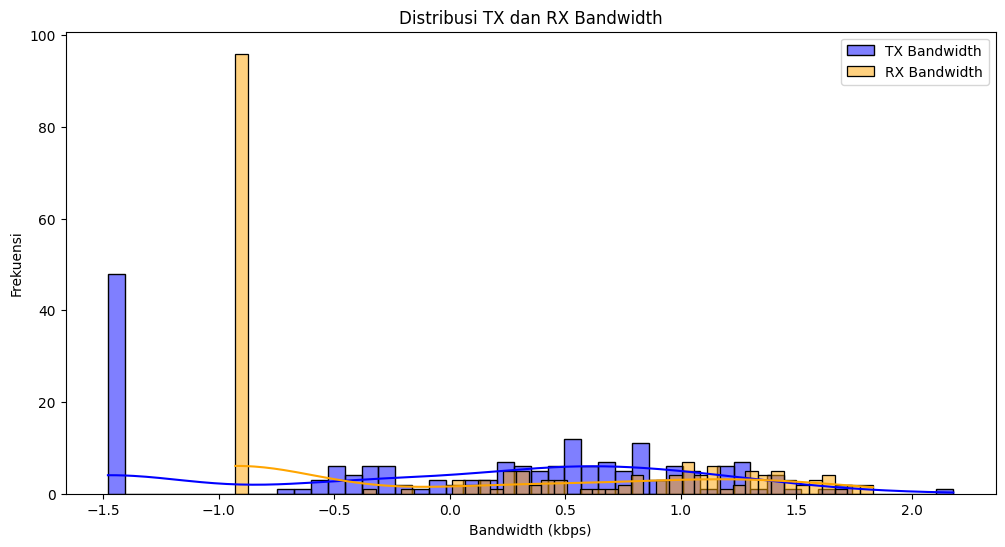


2. Korelasi Antar Fitur


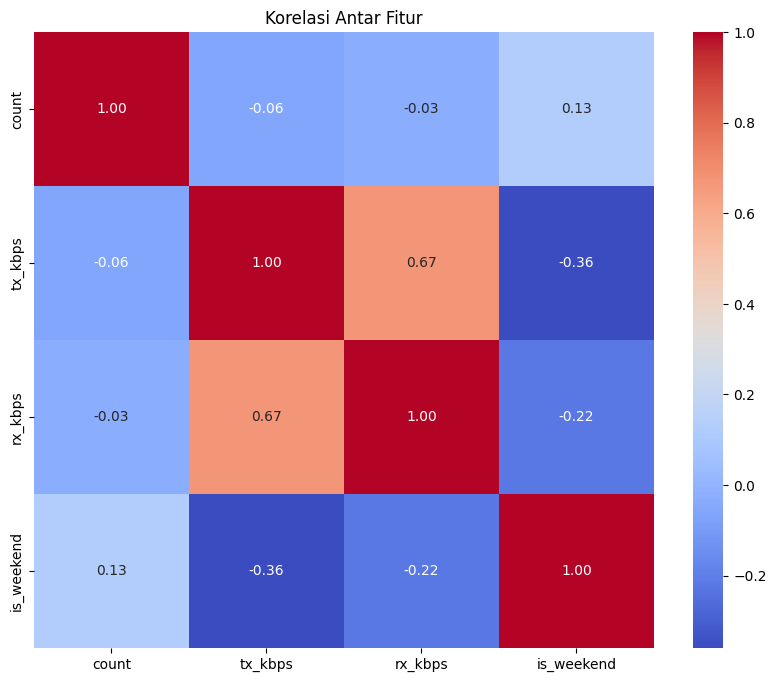


3. Tren Waktu Bandwidth


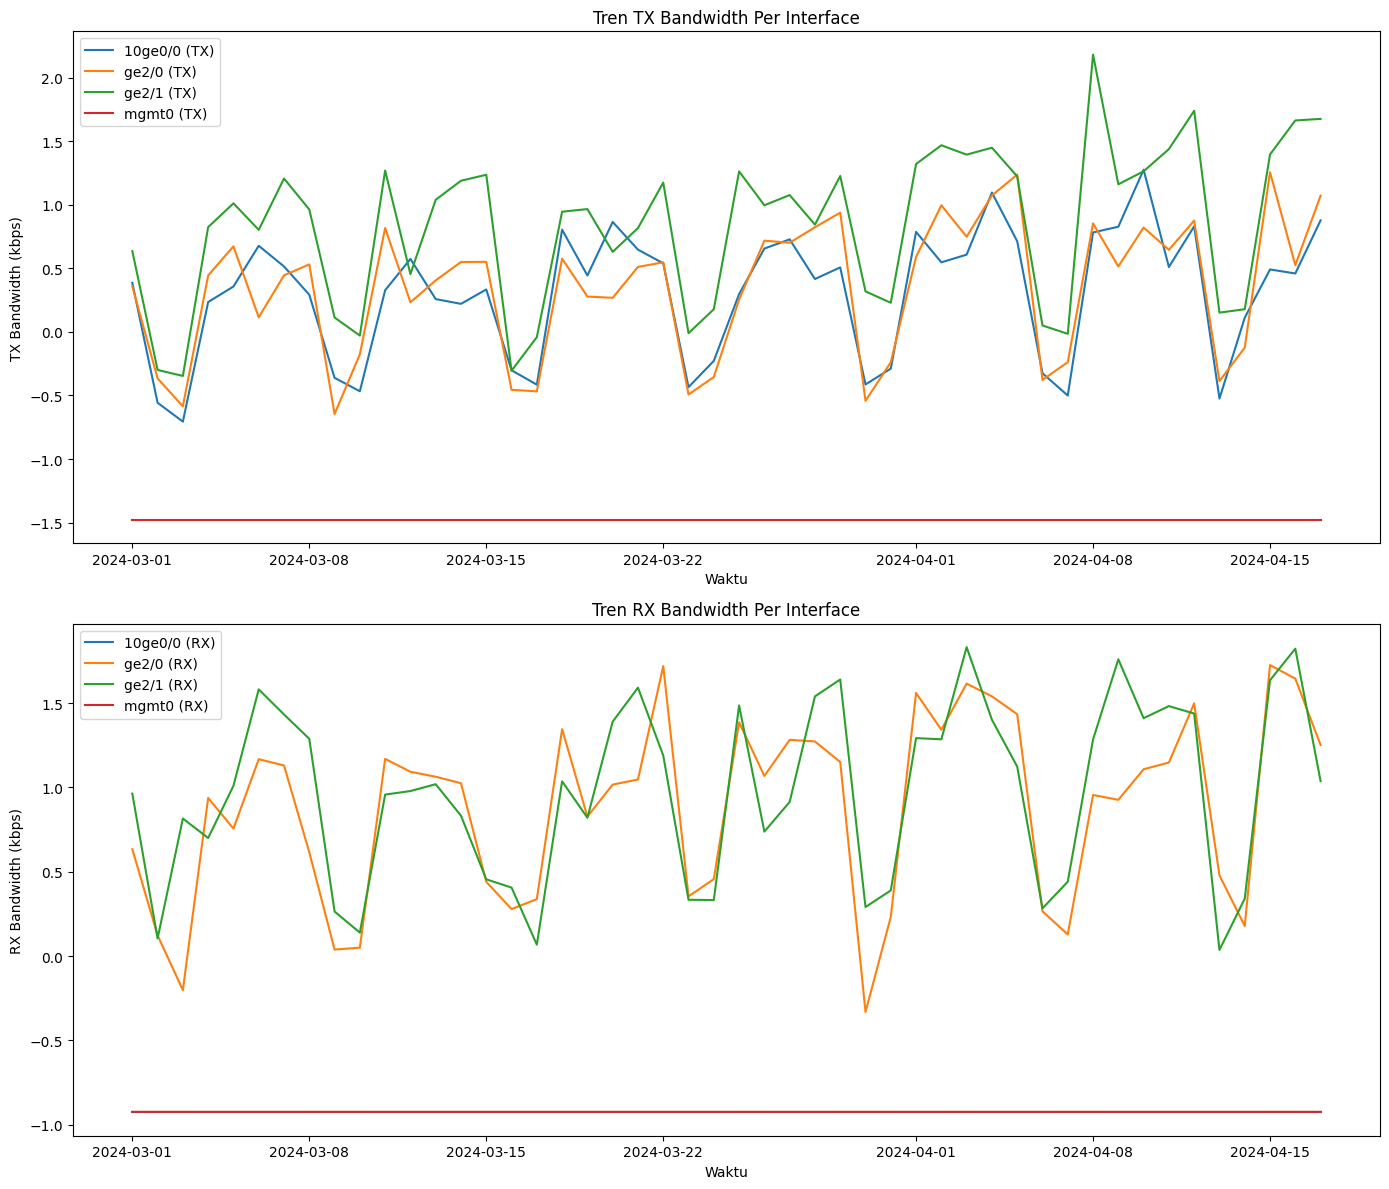


4. Statistik Deskriptif:


,tx_kbps,rx_kbps
count,1.920000e+02,1.920000e+02
mean,-5.551115e-17,5.088522e-17
std,1.002614e+00,1.002614e+00
min,-1.479280e+00,-9.276657e-01
25%,-8.993716e-01,-9.249695e-01
50%,2.726224e-01,-6.280017e-01
75%,8.024354e-01,1.020429e+00
max,2.180293e+00,1.832076e+00



5. Analisis Penggunaan Bandwidth per Jam


<Figure size 1200x600 with 0 Axes>

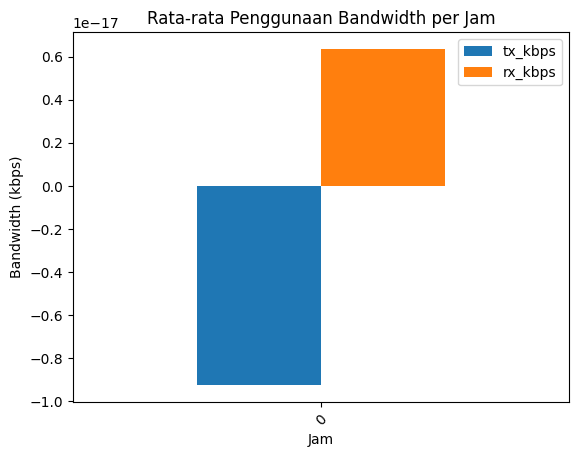


6. Analisis Weekday vs Weekend


<Figure size 1000x600 with 0 Axes>

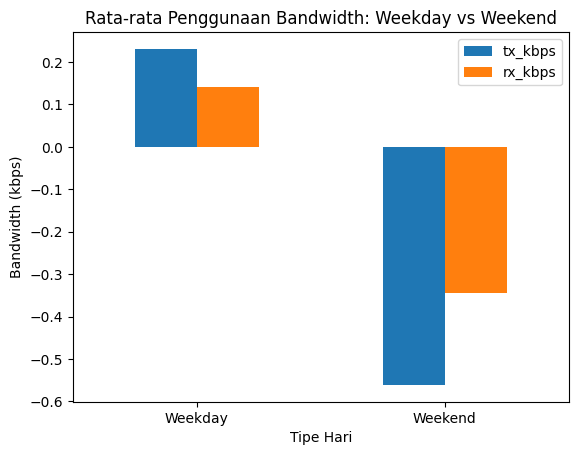


7. Box Plot Analisis Outlier


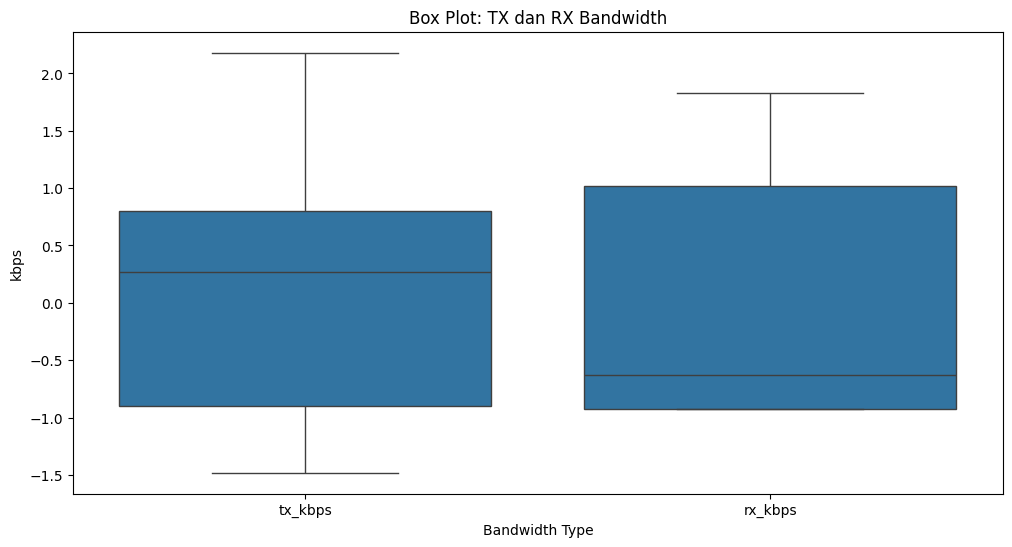


8. Analisis Penggunaan per Interface

Statistik per Interface:


tx_kbps                       rx_kbps                    
               mean       max       min      mean       max       min
interface                                                            
10ge0/0    0.301049  1.275278 -0.706069 -0.927666 -0.927666 -0.927666
ge2/0      0.343136  1.255411 -0.646063  0.880773  1.725340 -0.331948
ge2/1      0.835095  2.180293 -0.346749  0.970956  1.832076  0.036064
mgmt0     -1.479280 -1.479280 -1.479280 -0.924063 -0.924055 -0.924071


=== EDA Selesai ===


In [6]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {
            'tx': None,
            'rx': None
        }
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()

    def load_data(self, file_path):
        """Load data dari file JSON"""
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan")
            return None

    def assess_data(self, df):
        """Melakukan penilaian awal pada data"""
        try:
            # Konversi entry_time ke datetime
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Menambahkan fitur temporal
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            return df
        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        try:
            # 1. Menghapus duplikasi data
            initial_rows = len(df)
            df_cleaned = df.drop_duplicates()

            # 2. Menyaring data untuk interface tertentu
            initial_rows = len(df_cleaned)
            allowed_interfaces = ['10ge0/0', 'ge2/0', 'ge2/1', 'mgmt0']
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(allowed_interfaces)]

            # 3. Menghapus outlier menggunakan metode IQR
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1
            initial_rows = len(df_cleaned)
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                  (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]

            # 4. Standarisasi data untuk kolom tx_kbps dan rx_kbps
            df_cleaned[['tx_kbps', 'rx_kbps']] = self.scaler.fit_transform(df_cleaned[['tx_kbps', 'rx_kbps']])
            return df_cleaned

        except Exception as e:
            print(f"Error in data cleaning: {e}")
            return None

    def exploratory_data_analysis(self, df):
        """Melakukan Exploratory Data Analysis"""
        try:
            print("\n=== Exploratory Data Analysis (EDA) ===")

            # 1. Distribusi Bandwidth
            print("\n1. Distribusi Bandwidth (tx_kbps dan rx_kbps)")
            plt.figure(figsize=(12, 6))
            sns.histplot(df['tx_kbps'], kde=True, color='blue', bins=50, label='TX Bandwidth')
            sns.histplot(df['rx_kbps'], kde=True, color='orange', bins=50, label='RX Bandwidth')
            plt.legend()
            plt.title("Distribusi TX dan RX Bandwidth")
            plt.xlabel("Bandwidth (kbps)")
            plt.ylabel("Frekuensi")
            plt.show()

            # 2. Korelasi Matrix
            print("\n2. Korelasi Antar Fitur")
            numeric_cols = df.select_dtypes(include=['float64', 'int64'])
            corr = numeric_cols.corr()
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
            plt.title("Korelasi Antar Fitur")
            plt.show()

            # 3. Time Series Analysis
            print("\n3. Tren Waktu Bandwidth")
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

            # TX Bandwidth per Interface
            for interface, group in df.groupby('interface'):
                ax1.plot(group['entry_time'], group['tx_kbps'],
                        label=f"{interface} (TX)")
            ax1.set_title("Tren TX Bandwidth Per Interface")
            ax1.set_xlabel("Waktu")
            ax1.set_ylabel("TX Bandwidth (kbps)")
            ax1.legend()

            # RX Bandwidth per Interface
            for interface, group in df.groupby('interface'):
                ax2.plot(group['entry_time'], group['rx_kbps'],
                        label=f"{interface} (RX)")
            ax2.set_title("Tren RX Bandwidth Per Interface")
            ax2.set_xlabel("Waktu")
            ax2.set_ylabel("RX Bandwidth (kbps)")
            ax2.legend()

            plt.tight_layout()
            plt.show()

            # 4. Statistik Deskriptif
            print("\n4. Statistik Deskriptif:")
            display(df[['tx_kbps', 'rx_kbps']].describe())

            # 5. Penggunaan Bandwidth per Jam
            print("\n5. Analisis Penggunaan Bandwidth per Jam")
            hourly_stats = df.groupby('hour')[['tx_kbps', 'rx_kbps']].mean()
            plt.figure(figsize=(12, 6))
            hourly_stats.plot(kind='bar')
            plt.title("Rata-rata Penggunaan Bandwidth per Jam")
            plt.xlabel("Jam")
            plt.ylabel("Bandwidth (kbps)")
            plt.legend()
            plt.xticks(rotation=45)
            plt.show()

            # 6. Analisis Weekday vs Weekend
            print("\n6. Analisis Weekday vs Weekend")
            day_type_stats = df.groupby('is_weekend')[['tx_kbps', 'rx_kbps']].mean()
            day_type_stats.index = ['Weekday', 'Weekend']
            plt.figure(figsize=(10, 6))
            day_type_stats.plot(kind='bar')
            plt.title("Rata-rata Penggunaan Bandwidth: Weekday vs Weekend")
            plt.xlabel("Tipe Hari")
            plt.ylabel("Bandwidth (kbps)")
            plt.legend()
            plt.xticks(rotation=0)
            plt.show()

            # 7. Box Plot untuk Outlier Analysis
            print("\n7. Box Plot Analisis Outlier")
            plt.figure(figsize=(12, 6))
            df_melt = pd.melt(df[['tx_kbps', 'rx_kbps']], var_name='Bandwidth Type', value_name='kbps')
            sns.boxplot(x='Bandwidth Type', y='kbps', data=df_melt)
            plt.title("Box Plot: TX dan RX Bandwidth")
            plt.show()

            # 8. Penggunaan Bandwidth per Interface
            print("\n8. Analisis Penggunaan per Interface")
            interface_stats = df.groupby('interface')[['tx_kbps', 'rx_kbps']].agg(['mean', 'max', 'min'])
            print("\nStatistik per Interface:")
            display(interface_stats)

            print("\n=== EDA Selesai ===")
            return True

        except Exception as e:
            print(f"Error dalam EDA: {e}")
            return False

def main():
    # Membuat objek BandwidthAnalyzer
    analyzer = BandwidthAnalyzer()

    # Memuat data
    file_path = '../data/sample_hub_data.json'
    df_loaded = analyzer.load_data(file_path)

    # Jika data berhasil dimuat, lakukan penilaian, pembersihan, dan EDA
    if df_loaded is not None:
        # Proses assessing data
        df_assessed = analyzer.assess_data(df_loaded)

        # Proses cleaning data
        if df_assessed is not None:
            df_cleaned = analyzer.clean_data(df_assessed)

            # Proses EDA
            if df_cleaned is not None:
                print("\n=== Melakukan Exploratory Data Analysis (EDA) ===")
                analyzer.exploratory_data_analysis(df_cleaned)
            else:
                print("Cleaning data gagal.")
        else:
            print("Assessment data gagal.")
    else:
        print("Data tidak tersedia untuk dilakukan penilaian, pembersihan, dan EDA.")

if __name__ == "__main__":
    main()

## Train-Test Data


=== Feature Engineering ===
Menambahkan kolom total_kbps...
Menambahkan kolom usage_percentage...
Menambahkan kolom time_since_last_entry...
Menambahkan kolom bandwidth_change...
Menambahkan fitur lag dan rolling (historis)...

Feature Engineering selesai.
Kolom yang tersedia: ['entry_time', 'count', 'interface', 'tx_kbps', 'rx_kbps', 'hour', 'day_of_week', 'is_weekend', 'month', 'total_kbps', 'usage_percentage', 'time_since_last_entry', 'bandwidth_change', 'interface_encoded', 'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3', 'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']

=== Splitting Data ===
Training set shape: (144, 9)
Testing set shape: (36, 9)

=== Training Models ===

Training models untuk TX Bandwidth...

Training tx_RandomForest...



Training tx_XGBoost...

Training tx_LightGBM...

Training models untuk RX Bandwidth...

Training rx_RandomForest...

Training rx_XGBoost...



Training rx_LightGBM...

=== Model Evaluation ===

Evaluating tx_RandomForest...
MSE: 16771.5806
RMSE: 129.5051
MAE: 90.3082
R2 Score: 0.9449


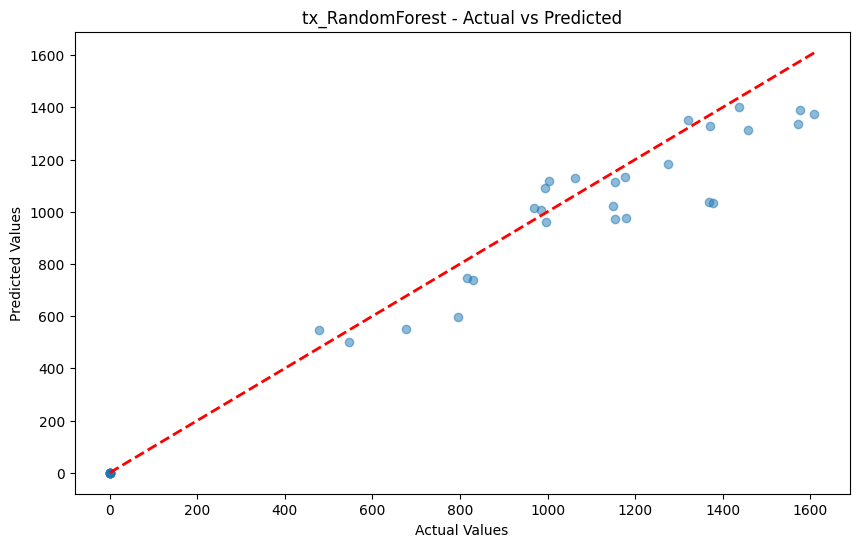


Evaluating tx_XGBoost...
MSE: 17416.8465
RMSE: 131.9729
MAE: 96.0896
R2 Score: 0.9428


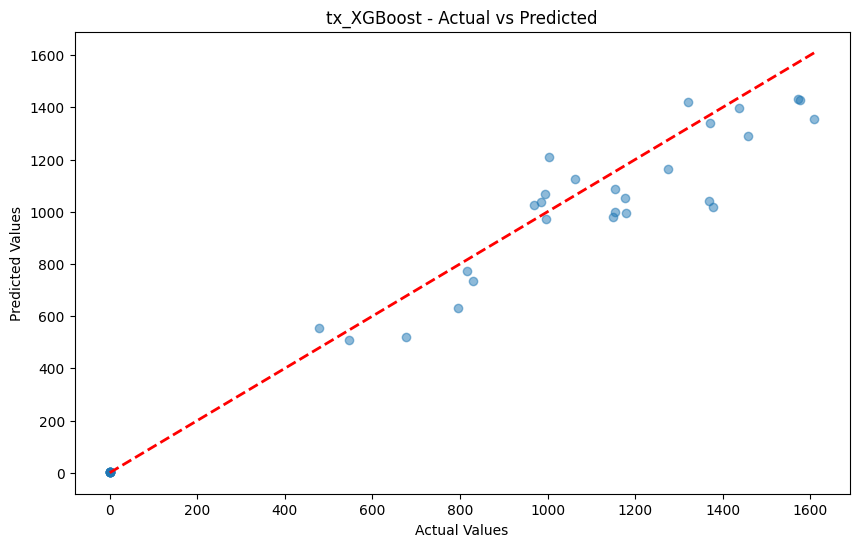


Evaluating tx_LightGBM...
MSE: 18348.8970
RMSE: 135.4581
MAE: 95.1164
R2 Score: 0.9397


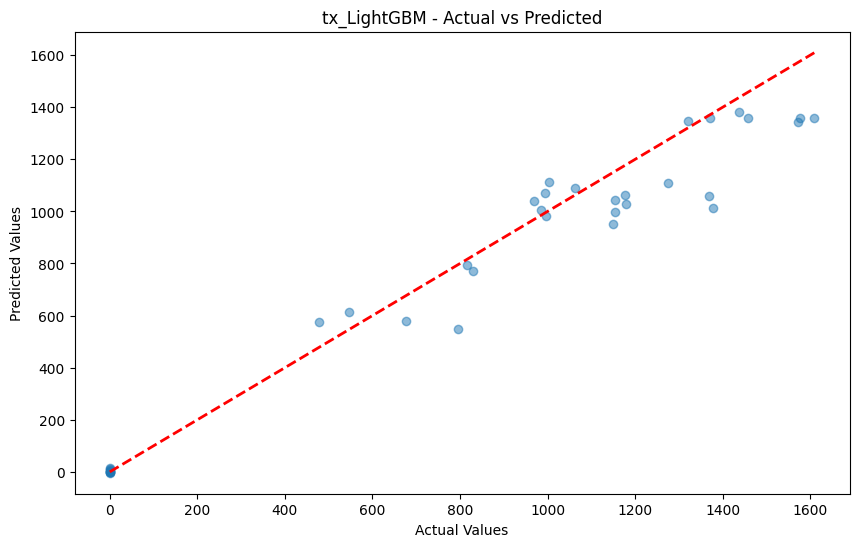


Evaluating rx_RandomForest...
MSE: 475039.1830
RMSE: 689.2309
MAE: 375.9290
R2 Score: 0.9502


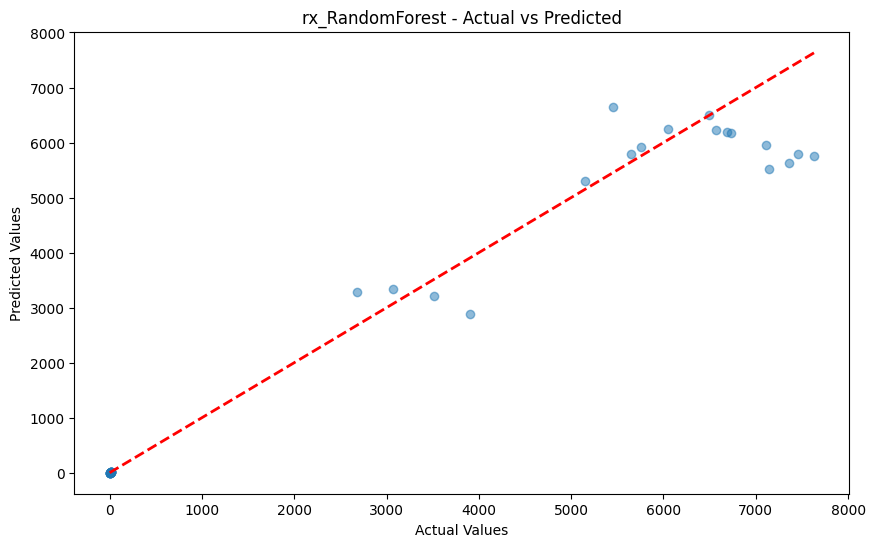


Evaluating rx_XGBoost...
MSE: 668568.9950
RMSE: 817.6607
MAE: 466.3090
R2 Score: 0.9299


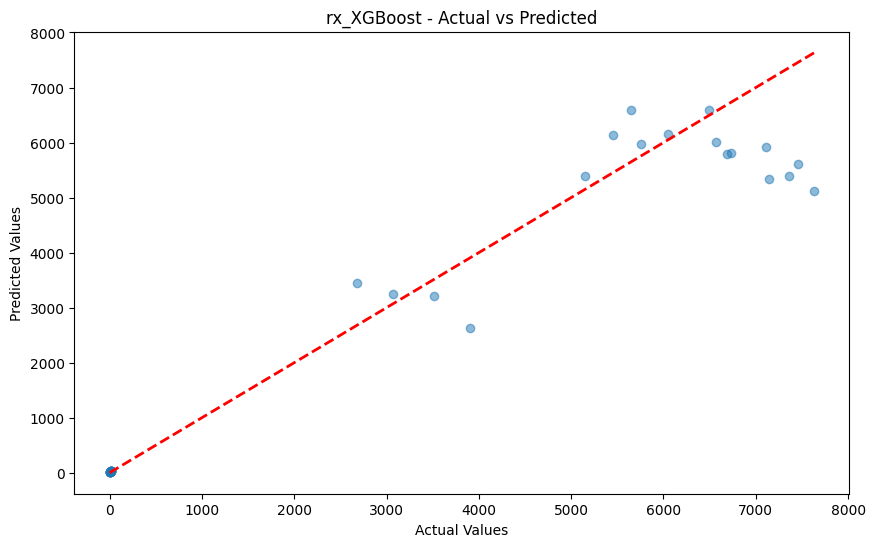


Evaluating rx_LightGBM...
MSE: 470632.4499
RMSE: 686.0266
MAE: 398.4300
R2 Score: 0.9507


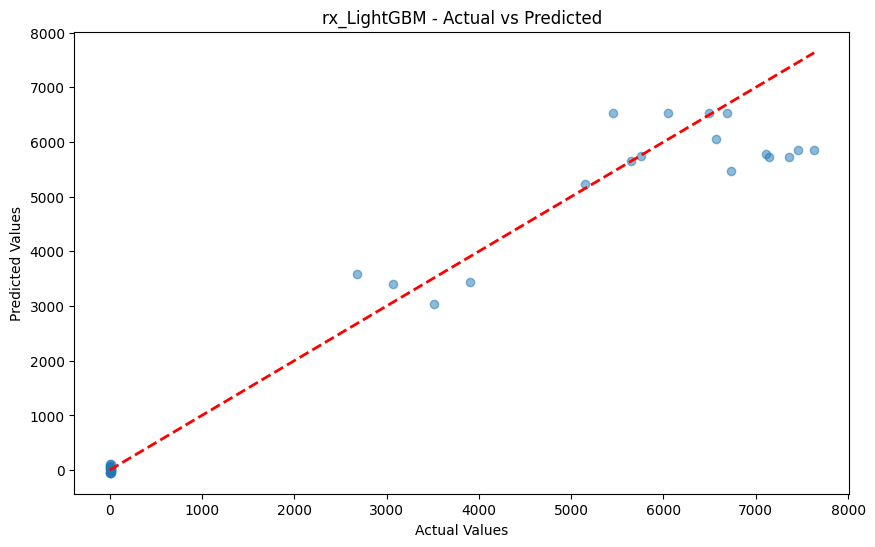


Best performing model: rx_LightGBM


In [7]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {
            'tx': None,
            'rx': None
        }
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()
        self.interface_capacity = {
            '10ge0/0': 10000,
            'ge2/0': 10000,
            'ge2/1': 10000,
            'mgmt0': 10000
        }

    def load_data(self, file_path):
        """Load data dari file JSON"""
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan")
            return None

    def assess_data(self, df):
        try:
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            return df
        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        try:
            # Hapus duplikasi
            df_cleaned = df.drop_duplicates()

            # Filter interface
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(self.interface_capacity.keys())]

            # Handle outliers dengan IQR
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                    (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]

            return df_cleaned
        except Exception as e:
            print(f"Error in data cleaning: {e}")
            return None

    def feature_engineering(self, df):
        try:
            print("\n=== Feature Engineering ===")

            # Total bandwidth
            print("Menambahkan kolom total_kbps...")
            df['total_kbps'] = df['tx_kbps'] + df['rx_kbps']

            # Usage percentage
            print("Menambahkan kolom usage_percentage...")
            df['usage_percentage'] = df.apply(
                lambda row: (row['total_kbps'] / self.interface_capacity.get(row['interface'], 10000)) * 100,
                axis=1
            )

            # Time since last entry
            print("Menambahkan kolom time_since_last_entry...")
            df['time_since_last_entry'] = df.groupby('interface')['entry_time'].diff().dt.total_seconds().fillna(0)

            # Bandwidth change
            print("Menambahkan kolom bandwidth_change...")
            df['bandwidth_change'] = df.groupby('interface')['total_kbps'].diff().fillna(0)

            # Lag & rolling features: hanya memakai nilai dari periode SEBELUMNYA,
            # sehingga model tidak "melihat" nilai tx/rx yang sedang diprediksi (bebas data leakage)
            print("Menambahkan fitur lag dan rolling (historis)...")
            df = df.sort_values(['interface', 'entry_time'])
            df['interface_encoded'] = self.label_encoder.fit_transform(df['interface'])
            for col in ['tx_kbps', 'rx_kbps']:
                grp = df.groupby('interface')[col]
                df[f'{col}_lag1'] = grp.shift(1)
                df[f'{col}_lag2'] = grp.shift(2)
                df[f'{col}_rolling3'] = grp.transform(lambda s: s.shift(1).rolling(3).mean())
            df = df.sort_values(['entry_time', 'interface'])

            print("\nFeature Engineering selesai.")
            print("Kolom yang tersedia:", df.columns.tolist())
            return df

        except Exception as e:
            print(f"Error dalam feature engineering: {e}")
            return None

    def split_data(self, df):
        """Memisahkan data menjadi training dan testing sets"""
        try:
            print("\n=== Splitting Data ===")

            # Catatan: total_kbps, usage_percentage, dan bandwidth_change dihitung dari tx/rx
            # pada waktu yang sama, jadi TIDAK dipakai sebagai fitur (menghindari data leakage)
            features = ['day_of_week', 'is_weekend', 'interface_encoded',
                        'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3',
                        'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']
            target = ['tx_kbps', 'rx_kbps']

            # Validasi kolom
            missing_features = [col for col in features if col not in df.columns]
            missing_target = [col for col in target if col not in df.columns]
            if missing_features or missing_target:
                print(f"Kolom yang tidak ditemukan: {missing_features + missing_target}")
                print("Kolom yang tersedia:", df.columns.tolist())
                raise ValueError("Beberapa kolom yang diperlukan tidak ditemukan")

            # Baris awal tiap interface belum punya histori (lag kosong) -> dibuang
            df_model = df.dropna(subset=features)
            X = df_model[features]
            y = df_model[target]

            # Split kronologis: 80% periode awal untuk training, 20% periode akhir untuk testing
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, shuffle=False
            )

            print(f"Training set shape: {X_train.shape}")
            print(f"Testing set shape: {X_test.shape}")

            self.datasets['X_train'] = X_train
            self.datasets['X_test'] = X_test
            self.datasets['y_train'] = y_train
            self.datasets['y_test'] = y_test

            return X_train, X_test, y_train, y_test

        except Exception as e:
            print(f"Error dalam splitting data: {e}")
            return None, None, None, None

    def train_models(self, X_train, y_train):
        """Melatih berbagai model machine learning"""
        try:
            print("\n=== Training Models ===")

            models = {
                'tx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'tx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'tx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'rx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
            }

            trained_models = {}

            # Training TX models
            print("\nTraining models untuk TX Bandwidth...")
            for name in ['tx_RandomForest', 'tx_XGBoost', 'tx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['tx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            # Training RX models
            print("\nTraining models untuk RX Bandwidth...")
            for name in ['rx_RandomForest', 'rx_XGBoost', 'rx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['rx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            self.models = trained_models
            return trained_models

        except Exception as e:
            print(f"Error dalam training models: {e}")
            return None

    def evaluate_models(self, trained_models, X_test, y_test):
        """Mengevaluasi performa model"""
        try:
            print("\n=== Model Evaluation ===")
            results = {}

            for name, model in trained_models.items():
                print(f"\nEvaluating {name}...")

                y_pred = model.predict(X_test)
                target_col = 'tx_kbps' if 'tx_' in name else 'rx_kbps'

                mse = mean_squared_error(y_test[target_col], y_pred)
                rmse = np.sqrt(mse)
                mae = mean_absolute_error(y_test[target_col], y_pred)
                r2 = r2_score(y_test[target_col], y_pred)

                results[name] = {
                    'MSE': mse,
                    'RMSE': rmse,
                    'MAE': mae,
                    'R2': r2
                }

                print(f"MSE: {mse:.4f}")
                print(f"RMSE: {rmse:.4f}")
                print(f"MAE: {mae:.4f}")
                print(f"R2 Score: {r2:.4f}")

                plt.figure(figsize=(10, 6))
                plt.scatter(y_test[target_col], y_pred, alpha=0.5)
                plt.plot([y_test[target_col].min(), y_test[target_col].max()],
                        [y_test[target_col].min(), y_test[target_col].max()],
                        'r--', lw=2)
                plt.title(f'{name} - Actual vs Predicted')
                plt.xlabel('Actual Values')
                plt.ylabel('Predicted Values')
                plt.show()

            self.accuracy_metrics = results
            return results

        except Exception as e:
            print(f"Error dalam evaluasi model: {e}")
            return None

def main():
    # Inisialisasi analyzer
    analyzer = BandwidthAnalyzer()

    # Load dan proses data
    file_path = '../data/sample_hub_data.json'
    df_loaded = analyzer.load_data(file_path)

    if df_loaded is not None:
        # Process data
        df_assessed = analyzer.assess_data(df_loaded)
        if df_assessed is not None:
            df_cleaned = analyzer.clean_data(df_assessed)
            if df_cleaned is not None:
                # Feature engineering
                df_featured = analyzer.feature_engineering(df_cleaned)
                if df_featured is not None:
                    # Split data
                    X_train, X_test, y_train, y_test = analyzer.split_data(df_featured)
                    if X_train is not None:
                        # Train models
                        trained_models = analyzer.train_models(X_train, y_train)
                        if trained_models is not None:
                            # Evaluate models
                            results = analyzer.evaluate_models(trained_models, X_test, y_test)
                            if results is not None:
                                # Save best model
                                best_model = max(results.items(), key=lambda x: x[1]['R2'])[0]
                                print(f"\nBest performing model: {best_model}")
                                joblib.dump(trained_models[best_model], f"{best_model}.pkl")
                            else:
                                print("Model evaluation failed.")
                        else:
                            print("Model training failed.")
                    else:
                        print("Data splitting failed.")
                else:
                    print("Feature engineering failed.")
            else:
                print("Data cleaning failed.")
        else:
            print("Data assessment failed.")
    else:
        print("Data loading failed.")

if __name__ == "__main__":
    main()

## Accuracy Test

Data berhasil dimuat: 240 baris
Data assessment selesai
Data cleaning selesai

=== Feature Engineering ===
Menambahkan kolom total_kbps...
Menambahkan kolom usage_percentage...
Menambahkan kolom time_since_last_entry...
Menambahkan kolom bandwidth_change...


Menambahkan fitur lag dan rolling (historis)...

Feature Engineering selesai.
Kolom yang tersedia: ['entry_time', 'count', 'interface', 'tx_kbps', 'rx_kbps', 'hour', 'day_of_week', 'is_weekend', 'month', 'total_kbps', 'usage_percentage', 'time_since_last_entry', 'bandwidth_change', 'interface_encoded', 'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3', 'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']

=== Splitting Data ===
Training set shape: (144, 9)
Testing set shape: (36, 9)

=== Training Models ===

Training models untuk TX Bandwidth...

Training tx_RandomForest...



Training tx_XGBoost...

Training tx_LightGBM...

Training models untuk RX Bandwidth...

Training rx_RandomForest...

Training rx_XGBoost...

Training rx_LightGBM...

=== Comprehensive Model Evaluation ===

Evaluating TX Bandwidth Models:

Evaluating tx_RandomForest...



Detailed Results for tx_RandomForest:

Regression Metrics:
  Training R2: 0.9785
  Testing R2: 0.9246
  Training RMSE: 71.7115
  Testing RMSE: 151.5332
  Training MAE: 37.7026
  Testing MAE: 104.6249
  Training Relative Accuracy: 96.37%
  Testing Relative Accuracy: 91.16%

Cross-Validation Results:
  Mean CV Score: 0.9399 (+/- 0.0265)

Imbalanced Data Metrics:
  Precision: 0.9286
  Recall: 0.7222
  F1-Score: 0.8125

Model Status: Good Fit


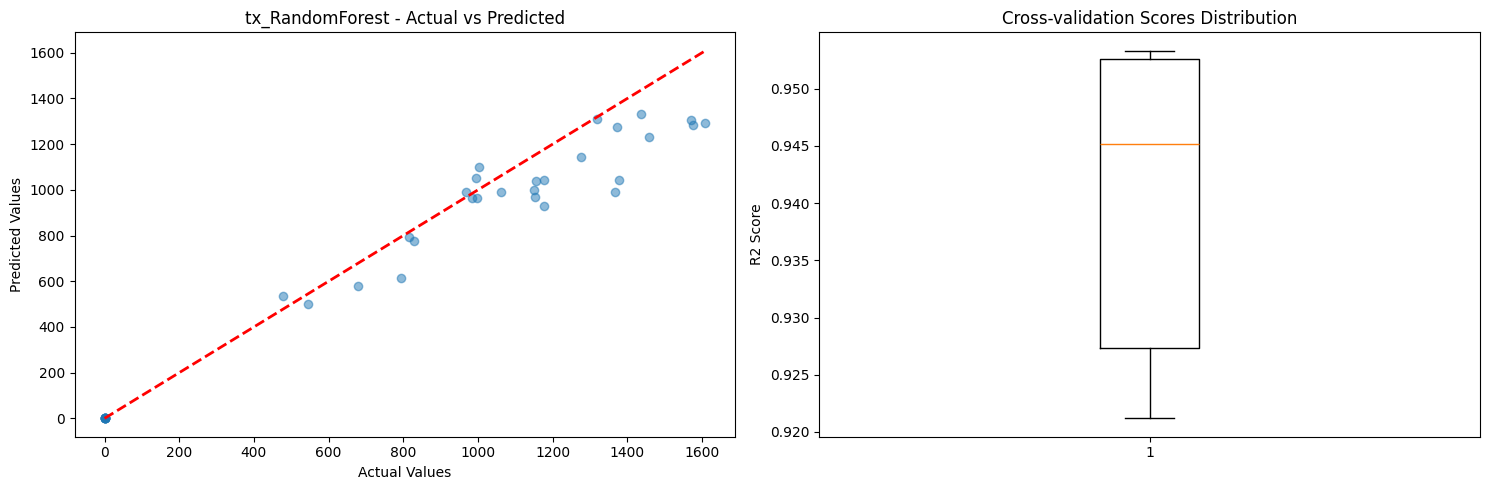


Evaluating tx_XGBoost...



Detailed Results for tx_XGBoost:

Regression Metrics:
  Training R2: 0.9840
  Testing R2: 0.9195
  Training RMSE: 61.9185
  Testing RMSE: 156.5169
  Training MAE: 25.3512
  Testing MAE: 112.9323
  Training Relative Accuracy: -111634263.96%
  Testing Relative Accuracy: -111634271.27%

Cross-Validation Results:
  Mean CV Score: 0.9330 (+/- 0.0252)

Imbalanced Data Metrics:
  Precision: 0.8333
  Recall: 0.8333
  F1-Score: 0.8333

Model Status: Good Fit


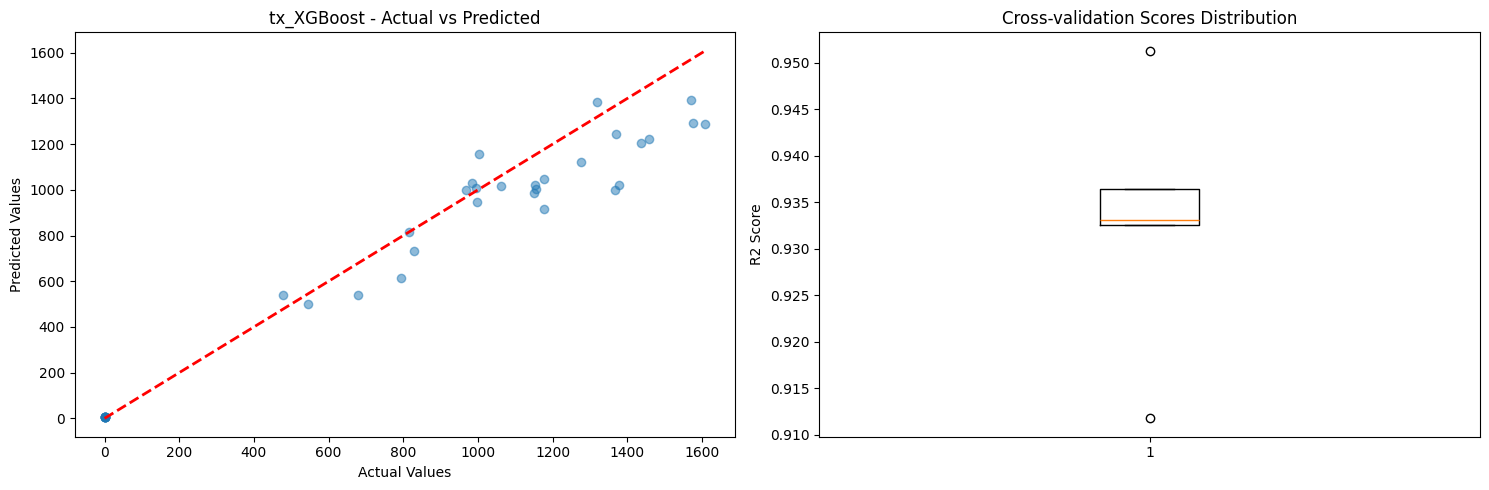


Evaluating tx_LightGBM...



Detailed Results for tx_LightGBM:

Regression Metrics:
  Training R2: 0.9588
  Testing R2: 0.9137
  Training RMSE: 99.2850
  Testing RMSE: 162.1195
  Training MAE: 65.1203
  Testing MAE: 115.4721
  Training Relative Accuracy: -164818599.57%
  Testing Relative Accuracy: -176162400.01%

Cross-Validation Results:
  Mean CV Score: 0.6409 (+/- 0.7085)

Imbalanced Data Metrics:
  Precision: 0.8571
  Recall: 0.6667
  F1-Score: 0.7500

Model Status: Good Fit


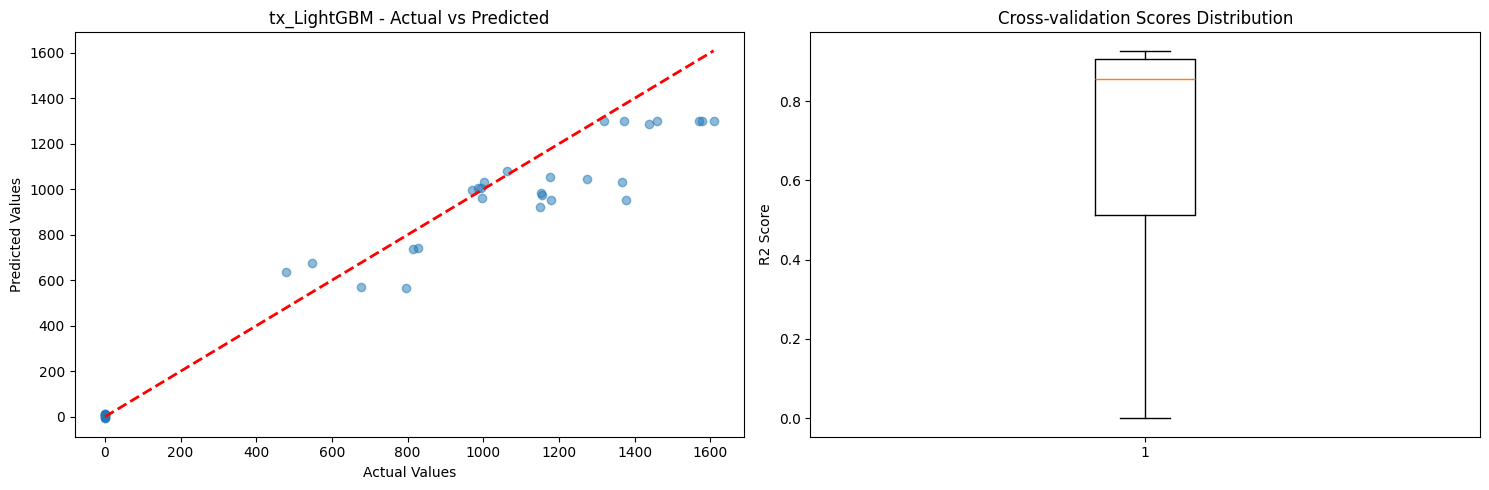


Evaluating RX Bandwidth Models:

Evaluating rx_RandomForest...



Detailed Results for rx_RandomForest:

Regression Metrics:
  Training R2: 0.9871
  Testing R2: 0.9437
  Training RMSE: 310.6365
  Testing RMSE: 732.7216
  Training MAE: 163.4369
  Testing MAE: 418.8629
  Training Relative Accuracy: 96.65%
  Testing Relative Accuracy: 92.89%

Cross-Validation Results:
  Mean CV Score: 0.9388 (+/- 0.0683)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


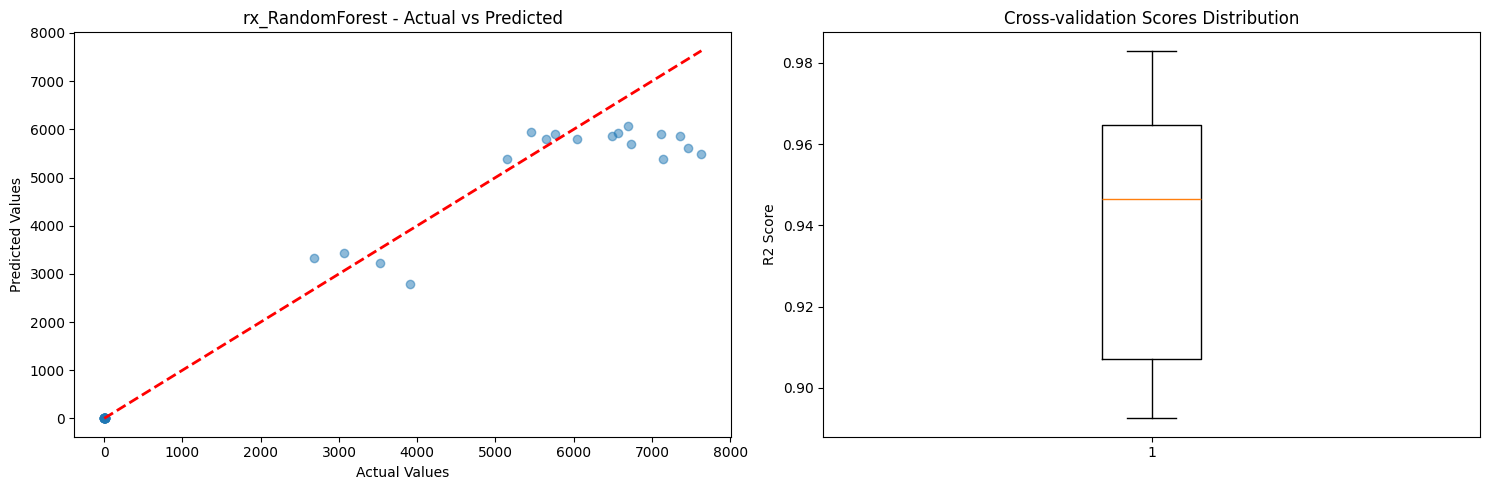


Evaluating rx_XGBoost...



Detailed Results for rx_XGBoost:

Regression Metrics:
  Training R2: 0.9907
  Testing R2: 0.9379
  Training RMSE: 263.7145
  Testing RMSE: 770.0005
  Training MAE: 96.8401
  Testing MAE: 440.9590
  Training Relative Accuracy: -340.43%
  Testing Relative Accuracy: -345.81%

Cross-Validation Results:
  Mean CV Score: 0.9255 (+/- 0.0755)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


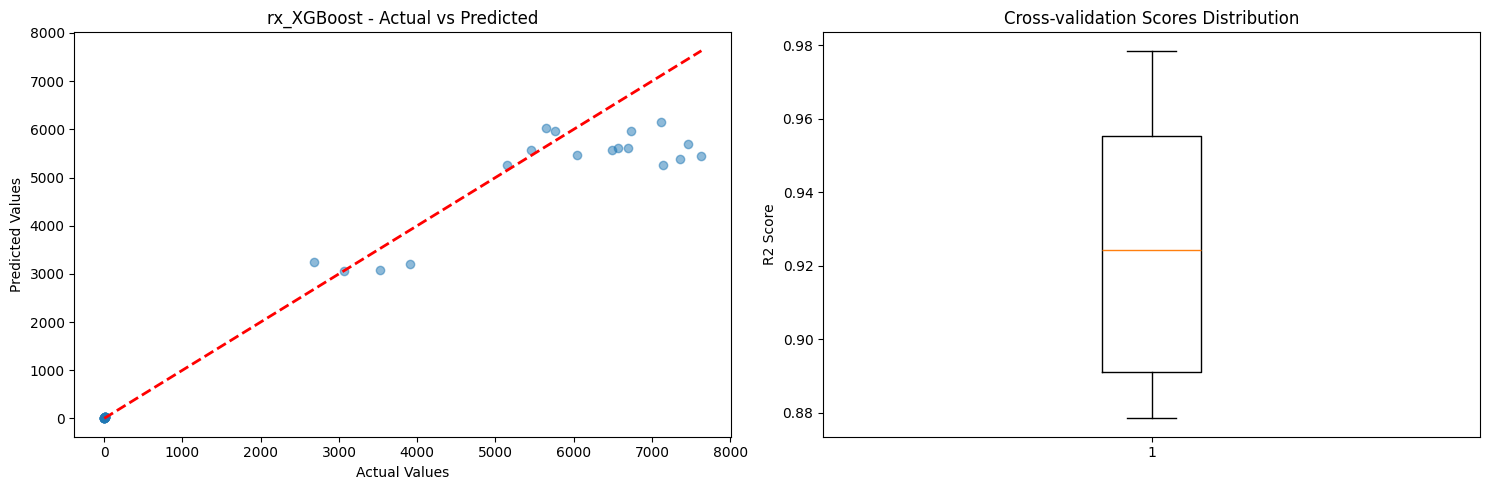


Evaluating rx_LightGBM...



Detailed Results for rx_LightGBM:

Regression Metrics:
  Training R2: 0.9617
  Testing R2: 0.9403
  Training RMSE: 534.9559
  Testing RMSE: 754.6219
  Training MAE: 327.9449
  Testing MAE: 471.3962
  Training Relative Accuracy: -2492.53%
  Testing Relative Accuracy: -2229.96%

Cross-Validation Results:
  Mean CV Score: 0.7268 (+/- 0.7350)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


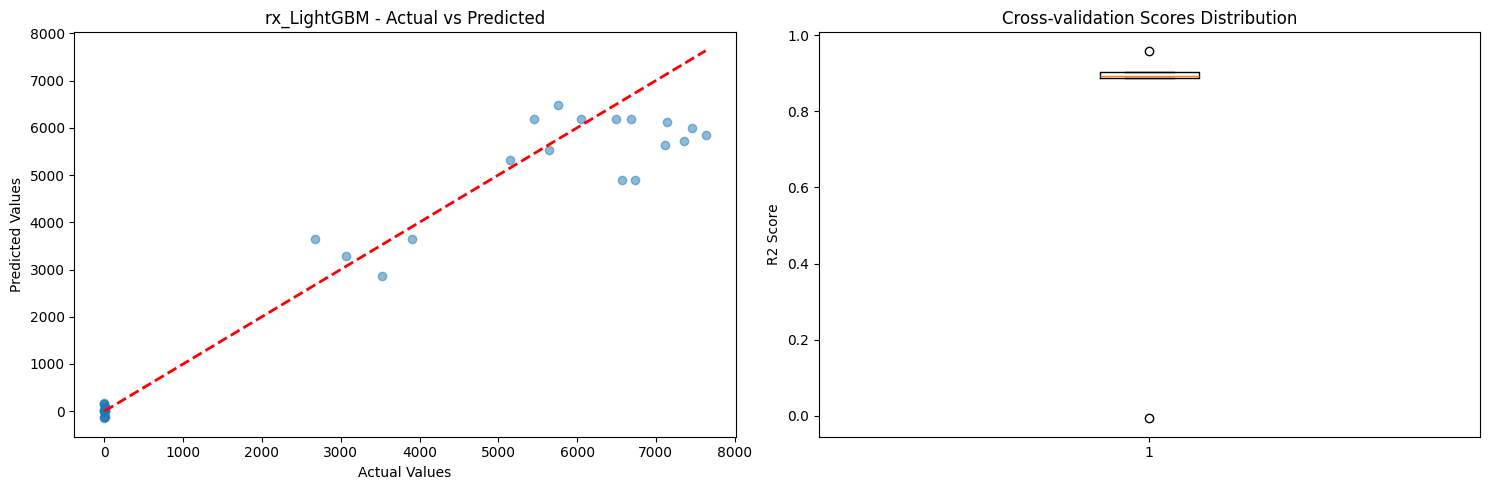


=== COMPREHENSIVE MODEL EVALUATION SUMMARY ===

TX Bandwidth Models:

tx_RandomForest:
  Test R2: 0.9246
  Test RMSE: 151.5332
  CV Score: 0.9399
  Status: Good Fit

tx_XGBoost:
  Test R2: 0.9195
  Test RMSE: 156.5169
  CV Score: 0.9330
  Status: Good Fit

tx_LightGBM:
  Test R2: 0.9137
  Test RMSE: 162.1195
  CV Score: 0.6409
  Status: Good Fit

Best tx model: tx_RandomForest (R2=0.9246)

RX Bandwidth Models:

rx_RandomForest:
  Test R2: 0.9437
  Test RMSE: 732.7216
  CV Score: 0.9388
  Status: Good Fit

rx_XGBoost:
  Test R2: 0.9379
  Test RMSE: 770.0005
  CV Score: 0.9255
  Status: Good Fit

rx_LightGBM:
  Test R2: 0.9403
  Test RMSE: 754.6219
  CV Score: 0.7268
  Status: Good Fit

Best rx model: rx_RandomForest (R2=0.9437)


In [8]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {}
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()
        self.interface_capacity = {
            '10ge0/0': 10000,
            'ge2/0': 10000,
            'ge2/1': 10000,
            'mgmt0': 10000
        }

    def load_data(self, file_path):
        """Load data dari file JSON"""
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                print(f"Data berhasil dimuat: {len(df)} baris")
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan")
            return None

    def assess_data(self, df):
        """Melakukan penilaian awal pada data"""
        try:
            # Konversi entry_time ke datetime
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Menambahkan fitur temporal
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            print("Data assessment selesai")
            return df
        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        """Membersihkan data"""
        try:
            # Hapus duplikasi
            df_cleaned = df.drop_duplicates()

            # Filter interface
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(self.interface_capacity.keys())]

            # Handle outliers dengan IQR
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                    (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]

            print("Data cleaning selesai")
            return df_cleaned
        except Exception as e:
            print(f"Error in data cleaning: {e}")
            return None

    def feature_engineering(self, df):
        """Melakukan feature engineering pada dataset"""
        try:
            print("\n=== Feature Engineering ===")

            # Total bandwidth
            print("Menambahkan kolom total_kbps...")
            df['total_kbps'] = df['tx_kbps'] + df['rx_kbps']

            # Usage percentage
            print("Menambahkan kolom usage_percentage...")
            df['usage_percentage'] = df.apply(
                lambda row: (row['total_kbps'] / self.interface_capacity.get(row['interface'], 10000)) * 100,
                axis=1
            )

            # Time since last entry
            print("Menambahkan kolom time_since_last_entry...")
            df['time_since_last_entry'] = df.groupby('interface')['entry_time'].diff().dt.total_seconds().fillna(0)

            # Bandwidth change
            print("Menambahkan kolom bandwidth_change...")
            df['bandwidth_change'] = df.groupby('interface')['total_kbps'].diff().fillna(0)

            # Lag & rolling features: hanya memakai nilai dari periode SEBELUMNYA,
            # sehingga model tidak "melihat" nilai tx/rx yang sedang diprediksi (bebas data leakage)
            print("Menambahkan fitur lag dan rolling (historis)...")
            df = df.sort_values(['interface', 'entry_time'])
            df['interface_encoded'] = self.label_encoder.fit_transform(df['interface'])
            for col in ['tx_kbps', 'rx_kbps']:
                grp = df.groupby('interface')[col]
                df[f'{col}_lag1'] = grp.shift(1)
                df[f'{col}_lag2'] = grp.shift(2)
                df[f'{col}_rolling3'] = grp.transform(lambda s: s.shift(1).rolling(3).mean())
            df = df.sort_values(['entry_time', 'interface'])

            print("\nFeature Engineering selesai.")
            print("Kolom yang tersedia:", df.columns.tolist())
            return df

        except Exception as e:
            print(f"Error dalam feature engineering: {e}")
            return None

    def split_data(self, df):
        """Memisahkan data menjadi training dan testing sets"""
        try:
            print("\n=== Splitting Data ===")

            # Catatan: total_kbps, usage_percentage, dan bandwidth_change dihitung dari tx/rx
            # pada waktu yang sama, jadi TIDAK dipakai sebagai fitur (menghindari data leakage)
            features = ['day_of_week', 'is_weekend', 'interface_encoded',
                        'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3',
                        'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']
            target = ['tx_kbps', 'rx_kbps']

            # Validasi kolom
            missing_features = [col for col in features if col not in df.columns]
            missing_target = [col for col in target if col not in df.columns]
            if missing_features or missing_target:
                print(f"Kolom yang tidak ditemukan: {missing_features + missing_target}")
                print("Kolom yang tersedia:", df.columns.tolist())
                raise ValueError("Beberapa kolom yang diperlukan tidak ditemukan")

            # Baris awal tiap interface belum punya histori (lag kosong) -> dibuang
            df_model = df.dropna(subset=features)
            X = df_model[features]
            y = df_model[target]

            # Split kronologis: 80% periode awal untuk training, 20% periode akhir untuk testing
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, shuffle=False
            )

            print(f"Training set shape: {X_train.shape}")
            print(f"Testing set shape: {X_test.shape}")

            self.datasets['X_train'] = X_train
            self.datasets['X_test'] = X_test
            self.datasets['y_train'] = y_train
            self.datasets['y_test'] = y_test

            return X_train, X_test, y_train, y_test

        except Exception as e:
            print(f"Error dalam splitting data: {e}")
            return None, None, None, None

    def train_models(self, X_train, y_train):
        """Melatih berbagai model machine learning"""
        try:
            print("\n=== Training Models ===")

            models = {
                'tx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'tx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'tx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'rx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
            }

            trained_models = {}

            # Training TX models
            print("\nTraining models untuk TX Bandwidth...")
            for name in ['tx_RandomForest', 'tx_XGBoost', 'tx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['tx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            # Training RX models
            print("\nTraining models untuk RX Bandwidth...")
            for name in ['rx_RandomForest', 'rx_XGBoost', 'rx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['rx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            self.models = trained_models
            return trained_models

        except Exception as e:
            print(f"Error dalam training models: {e}")
            return None

    def evaluate_model_performance(self, trained_models, X_train, X_test, y_train, y_test):
        """Mengevaluasi performa model secara komprehensif dengan cross-validation"""
        try:
            print("\n=== Comprehensive Model Evaluation ===")
            performance_results = {}

            # Inisialisasi K-Fold
            kf = TimeSeriesSplit(n_splits=5)  # CV kronologis untuk data time series

            # Evaluasi untuk model TX dan RX
            for bandwidth_type in ['tx', 'rx']:
                print(f"\nEvaluating {bandwidth_type.upper()} Bandwidth Models:")

                model_metrics = {}
                target_col = f'{bandwidth_type}_kbps'

                for model_name in [f'{bandwidth_type}_RandomForest', f'{bandwidth_type}_XGBoost', f'{bandwidth_type}_LightGBM']:
                    print(f"\nEvaluating {model_name}...")
                    model = trained_models[model_name]

                    # Cross-validation scores
                    cv_scores = []
                    for train_idx, val_idx in kf.split(X_train):
                        # Split data
                        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
                        y_train_cv, y_val_cv = y_train[target_col].iloc[train_idx], y_train[target_col].iloc[val_idx]

                        # Train and predict
                        model.fit(X_train_cv, y_train_cv)
                        y_pred_cv = model.predict(X_val_cv)

                        # Calculate score
                        score = r2_score(y_val_cv, y_pred_cv)
                        cv_scores.append(score)

                    # Training metrics
                    train_pred = model.predict(X_train)
                    train_r2 = r2_score(y_train[target_col], train_pred)
                    train_rmse = np.sqrt(mean_squared_error(y_train[target_col], train_pred))
                    train_mae = mean_absolute_error(y_train[target_col], train_pred)
                    train_relative_accuracy = (1 - np.abs(train_pred - y_train[target_col]) / (np.abs(y_train[target_col]) + 1e-6)).mean() * 100

                    # Testing metrics
                    test_pred = model.predict(X_test)
                    test_r2 = r2_score(y_test[target_col], test_pred)
                    test_rmse = np.sqrt(mean_squared_error(y_test[target_col], test_pred))
                    test_mae = mean_absolute_error(y_test[target_col], test_pred)
                    test_relative_accuracy = (1 - np.abs(test_pred - y_test[target_col]) / (np.abs(y_test[target_col]) + 1e-6)).mean() * 100

                    # Calculate additional metrics for imbalanced data
                    threshold = np.median(y_test[target_col])
                    y_test_binary = (y_test[target_col] > threshold).astype(int)
                    y_pred_binary = (test_pred > threshold).astype(int)

                    precision = precision_score(y_test_binary, y_pred_binary)
                    recall = recall_score(y_test_binary, y_pred_binary)
                    f1 = f1_score(y_test_binary, y_pred_binary)

                    metrics = {
                        'train_r2': train_r2,
                        'test_r2': test_r2,
                        'train_rmse': train_rmse,
                        'test_rmse': test_rmse,
                        'train_mae': train_mae,
                        'test_mae': test_mae,
                        'train_relative_accuracy': train_relative_accuracy,
                        'test_relative_accuracy': test_relative_accuracy,
                        'cv_scores_mean': np.mean(cv_scores),
                        'cv_scores_std': np.std(cv_scores),
                        'precision': precision,
                        'recall': recall,
                        'f1_score': f1
                    }

                    # Model status evaluation
                    if (train_r2 - test_r2) > 0.1:
                        metrics['warning'] = 'Possible Overfitting'
                    elif (train_r2 < 0.5) and (test_r2 < 0.5):
                        metrics['warning'] = 'Possible Underfitting'
                    else:
                        metrics['warning'] = 'Good Fit'

                    model_metrics[model_name] = metrics

                    # Print comprehensive results
                    print(f"\nDetailed Results for {model_name}:")
                    print("\nRegression Metrics:")
                    print(f"  Training R2: {train_r2:.4f}")
                    print(f"  Testing R2: {test_r2:.4f}")
                    print(f"  Training RMSE: {train_rmse:.4f}")
                    print(f"  Testing RMSE: {test_rmse:.4f}")
                    print(f"  Training MAE: {train_mae:.4f}")
                    print(f"  Testing MAE: {test_mae:.4f}")
                    print(f"  Training Relative Accuracy: {train_relative_accuracy:.2f}%")
                    print(f"  Testing Relative Accuracy: {test_relative_accuracy:.2f}%")

                    print("\nCross-Validation Results:")
                    print(f"  Mean CV Score: {metrics['cv_scores_mean']:.4f} (+/- {metrics['cv_scores_std']*2:.4f})")

                    print("\nImbalanced Data Metrics:")
                    print(f"  Precision: {metrics['precision']:.4f}")
                    print(f"  Recall: {metrics['recall']:.4f}")
                    print(f"  F1-Score: {metrics['f1_score']:.4f}")

                    print(f"\nModel Status: {metrics['warning']}")

                    # Visualization
                    plt.figure(figsize=(15, 5))
                    plt.subplot(1, 2, 1)
                    plt.scatter(y_test[target_col], test_pred, alpha=0.5)
                    plt.plot([y_test[target_col].min(), y_test[target_col].max()],
                            [y_test[target_col].min(), y_test[target_col].max()],
                            'r--', lw=2)
                    plt.title(f'{model_name} - Actual vs Predicted')
                    plt.xlabel('Actual Values')
                    plt.ylabel('Predicted Values')

                    plt.subplot(1, 2, 2)
                    plt.boxplot(cv_scores)
                    plt.title('Cross-validation Scores Distribution')
                    plt.ylabel('R2 Score')

                    plt.tight_layout()
                    plt.show()

                performance_results[bandwidth_type] = model_metrics

            self.performance_results = performance_results
            return performance_results

        except Exception as e:
            print(f"Error dalam evaluasi model komprehensif: {e}")
            return None

def main():
    # Inisialisasi analyzer
    analyzer = BandwidthAnalyzer()

    # Load dan proses data
    file_path = '../data/sample_hub_data.json'
    df_loaded = analyzer.load_data(file_path)

    if df_loaded is not None:
        # Process data
        df_assessed = analyzer.assess_data(df_loaded)
        if df_assessed is not None:
            df_cleaned = analyzer.clean_data(df_assessed)
            if df_cleaned is not None:
                # Feature engineering
                df_featured = analyzer.feature_engineering(df_cleaned)
                if df_featured is not None:
                    # Split data
                    X_train, X_test, y_train, y_test = analyzer.split_data(df_featured)
                    if X_train is not None:
                        # Train models
                        trained_models = analyzer.train_models(X_train, y_train)
                        if trained_models is not None:
                            # Evaluasi komprehensif
                            performance_results = analyzer.evaluate_model_performance(
                                trained_models, X_train, X_test, y_train, y_test
                            )

                            if performance_results is not None:
                                # Ringkasan evaluasi
                                print("\n=== COMPREHENSIVE MODEL EVALUATION SUMMARY ===")
                                for bandwidth_type in ['tx', 'rx']:
                                    best_model = None
                                    best_score = -float('inf')

                                    print(f"\n{bandwidth_type.upper()} Bandwidth Models:")
                                    for model_name, metrics in performance_results[bandwidth_type].items():
                                        print(f"\n{model_name}:")
                                        print(f"  Test R2: {metrics['test_r2']:.4f}")
                                        print(f"  Test RMSE: {metrics['test_rmse']:.4f}")
                                        print(f"  CV Score: {metrics['cv_scores_mean']:.4f}")
                                        print(f"  Status: {metrics['warning']}")

                                        # Find best model
                                        if metrics['test_r2'] > best_score:
                                            best_score = metrics['test_r2']
                                            best_model = model_name

                                    # Save best model
                                    print(f"\nBest {bandwidth_type} model: {best_model} (R2={best_score:.4f})")
                                    joblib.dump(trained_models[best_model], f"best_{bandwidth_type}_model.pkl")
                            else:
                                print("Evaluasi model gagal.")
                        else:
                            print("Training model gagal.")
                    else:
                        print("Split data gagal.")
                else:
                    print("Feature engineering gagal.")
            else:
                print("Cleaning data gagal.")
        else:
            print("Assessment data gagal.")
    else:
        print("Loading data gagal.")

if __name__ == "__main__":
    main()

## Feature Importance

Data berhasil dimuat: 240 baris
Data assessment selesai
Data cleaning selesai

=== Feature Engineering ===
Menambahkan kolom total_kbps...
Menambahkan kolom usage_percentage...
Menambahkan kolom time_since_last_entry...
Menambahkan kolom bandwidth_change...
Menambahkan fitur lag dan rolling (historis)...

Feature Engineering selesai.
Kolom yang tersedia: ['entry_time', 'count', 'interface', 'tx_kbps', 'rx_kbps', 'hour', 'day_of_week', 'is_weekend', 'month', 'total_kbps', 'usage_percentage', 'time_since_last_entry', 'bandwidth_change', 'interface_encoded', 'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3', 'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']

=== Splitting Data ===
Training set shape: (144, 9)
Testing set shape: (36, 9)

=== Training Models ===

Training models untuk TX Bandwidth...

Training tx_RandomForest...

Training tx_XGBoost...

Training tx_LightGBM...

Training models untuk RX Bandwidth...

Training rx_RandomForest...



Training rx_XGBoost...

Training rx_LightGBM...

=== Feature Importance Analysis ===

Feature Importance untuk TX Bandwidth:


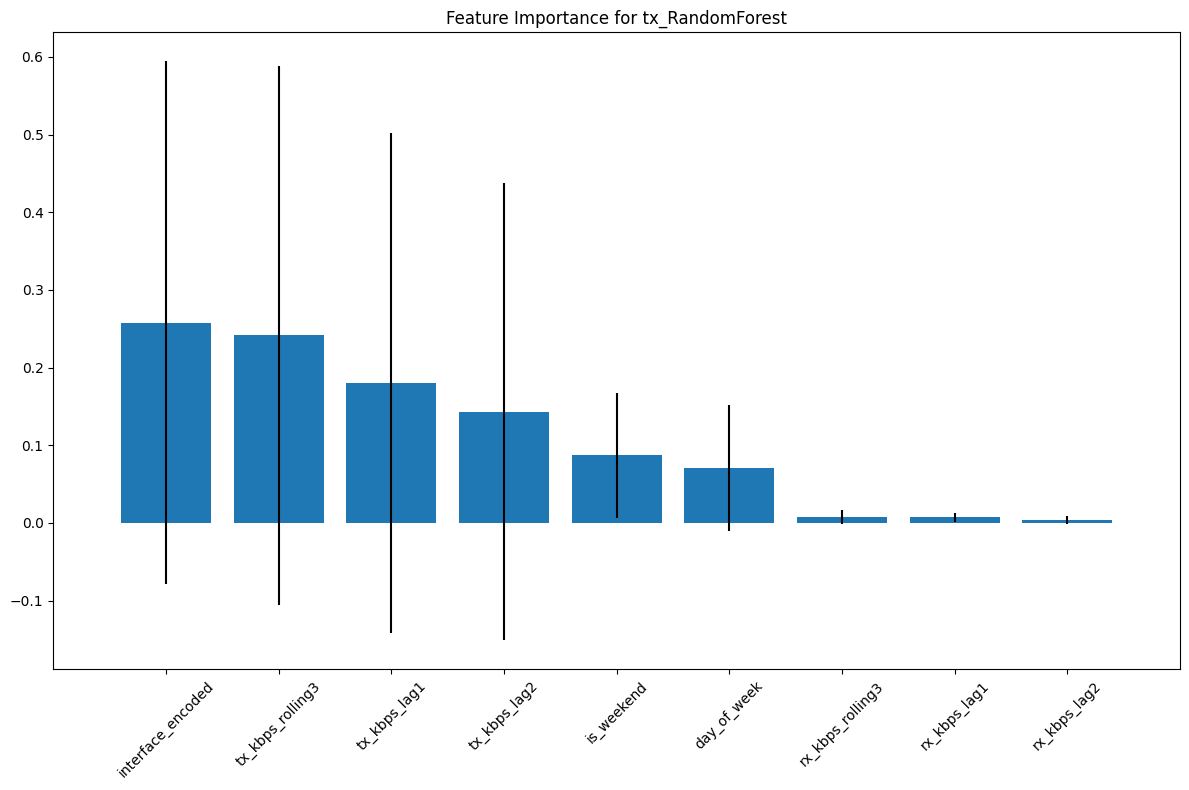


Feature Importance Ranking:
1. interface_encoded: 0.2579
2. tx_kbps_rolling3: 0.2416
3. tx_kbps_lag1: 0.1800
4. tx_kbps_lag2: 0.1433
5. is_weekend: 0.0873
6. day_of_week: 0.0709
7. rx_kbps_rolling3: 0.0074
8. rx_kbps_lag1: 0.0073
9. rx_kbps_lag2: 0.0043

Feature Importance untuk RX Bandwidth:


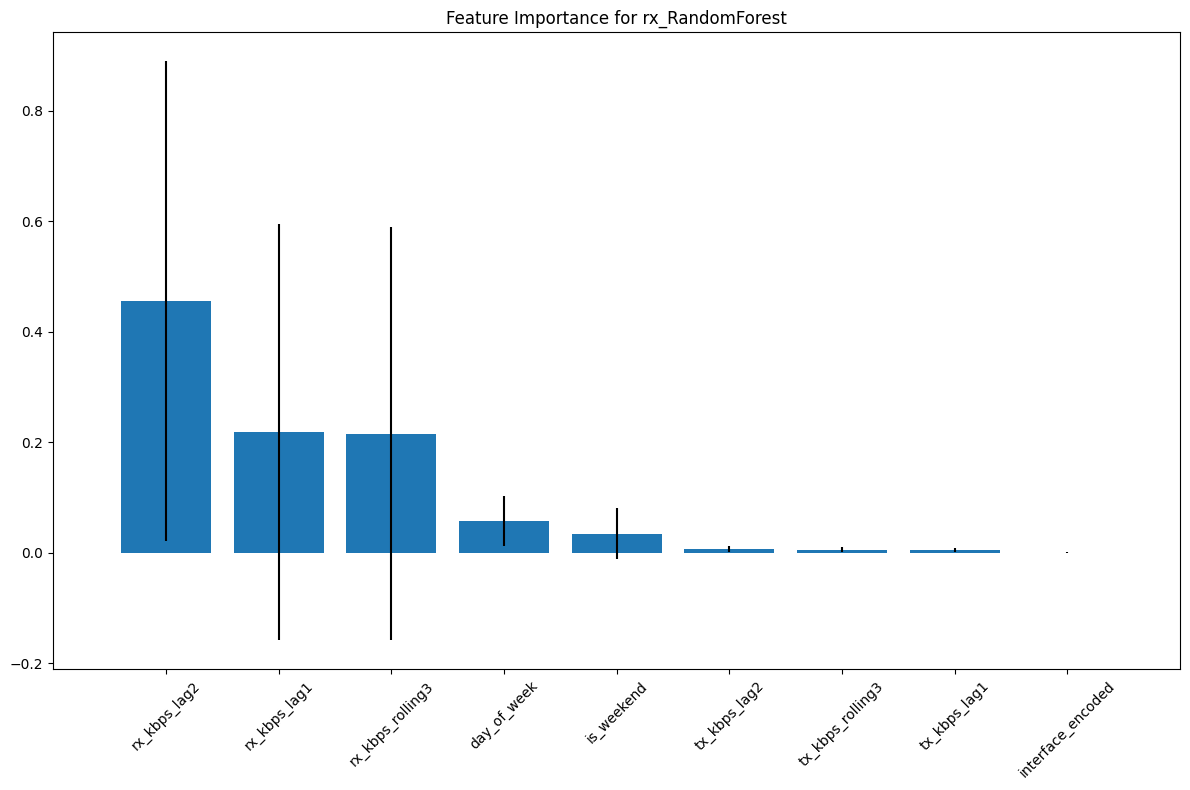


Feature Importance Ranking:
1. rx_kbps_lag2: 0.4555
2. rx_kbps_lag1: 0.2189
3. rx_kbps_rolling3: 0.2154
4. day_of_week: 0.0575
5. is_weekend: 0.0349
6. tx_kbps_lag2: 0.0073
7. tx_kbps_rolling3: 0.0054
8. tx_kbps_lag1: 0.0047
9. interface_encoded: 0.0004


<Figure size 1200x800 with 0 Axes>

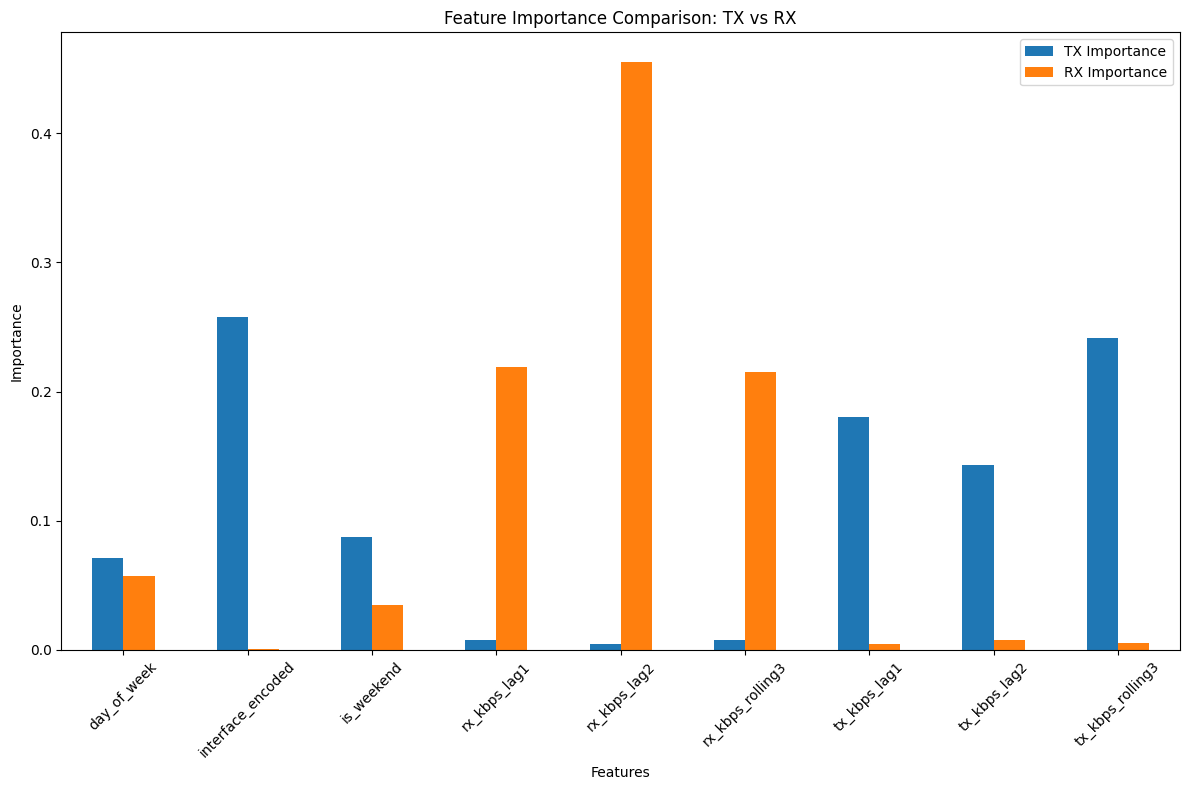


Feature Importance Comparison (TX vs RX):


,TX Importance,RX Importance
Feature,,
interface_encoded,0.257914,0.000361
tx_kbps_rolling3,0.241602,0.005411
tx_kbps_lag1,0.180017,0.004685
tx_kbps_lag2,0.143273,0.007339
is_weekend,0.087255,0.034865
day_of_week,0.070943,0.057468
rx_kbps_rolling3,0.007409,0.215412
rx_kbps_lag1,0.007316,0.218930
rx_kbps_lag2,0.004273,0.455530



=== Comprehensive Model Evaluation ===

Evaluating TX Bandwidth Models:

Evaluating tx_RandomForest...



Detailed Results for tx_RandomForest:

Regression Metrics:
  Training R2: 0.9785
  Testing R2: 0.9246
  Training RMSE: 71.7115
  Testing RMSE: 151.5332
  Training MAE: 37.7026
  Testing MAE: 104.6249
  Training Relative Accuracy: 96.37%
  Testing Relative Accuracy: 91.16%

Cross-Validation Results:
  Mean CV Score: 0.9399 (+/- 0.0265)

Imbalanced Data Metrics:
  Precision: 0.9286
  Recall: 0.7222
  F1-Score: 0.8125

Model Status: Good Fit


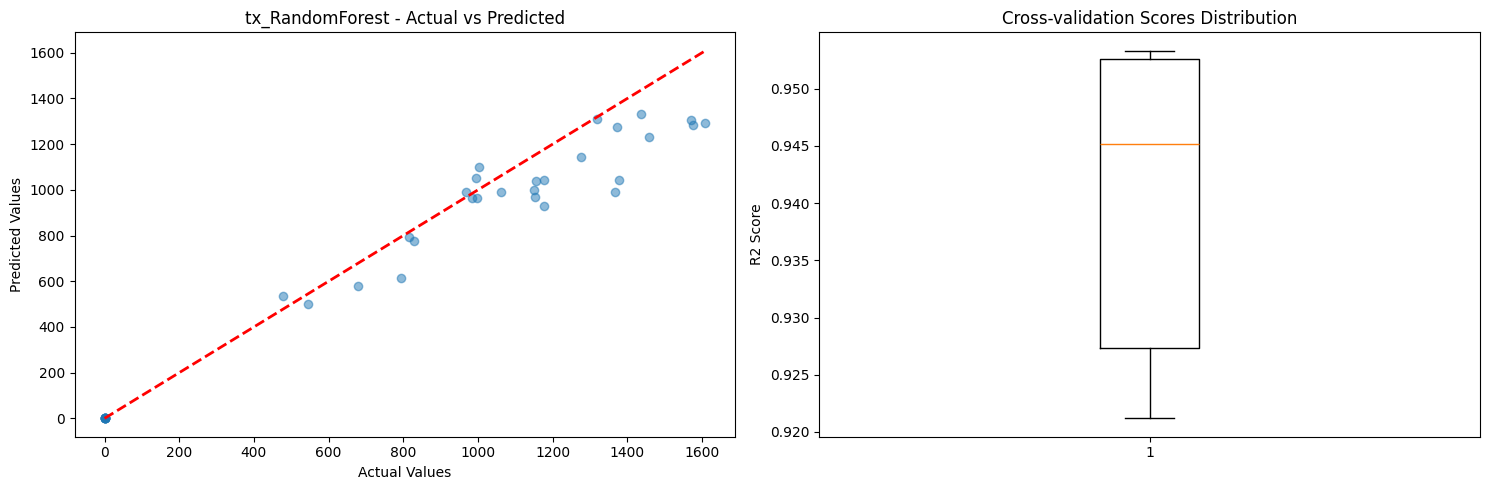


Evaluating tx_XGBoost...



Detailed Results for tx_XGBoost:

Regression Metrics:
  Training R2: 0.9840
  Testing R2: 0.9195
  Training RMSE: 61.9185
  Testing RMSE: 156.5169
  Training MAE: 25.3512
  Testing MAE: 112.9323
  Training Relative Accuracy: -111634263.96%
  Testing Relative Accuracy: -111634271.27%

Cross-Validation Results:
  Mean CV Score: 0.9330 (+/- 0.0252)

Imbalanced Data Metrics:
  Precision: 0.8333
  Recall: 0.8333
  F1-Score: 0.8333

Model Status: Good Fit


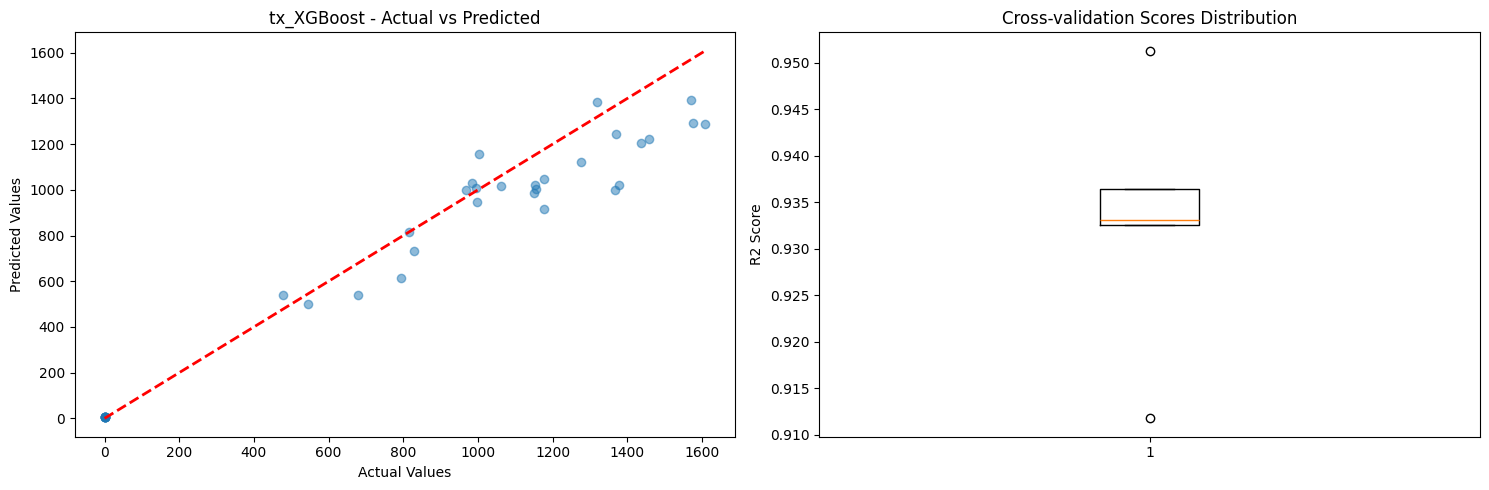


Evaluating tx_LightGBM...

Detailed Results for tx_LightGBM:

Regression Metrics:
  Training R2: 0.9588
  Testing R2: 0.9137
  Training RMSE: 99.2850
  Testing RMSE: 162.1195
  Training MAE: 65.1203
  Testing MAE: 115.4721
  Training Relative Accuracy: -164818599.57%
  Testing Relative Accuracy: -176162400.01%

Cross-Validation Results:
  Mean CV Score: 0.6409 (+/- 0.7085)

Imbalanced Data Metrics:
  Precision: 0.8571
  Recall: 0.6667
  F1-Score: 0.7500

Model Status: Good Fit


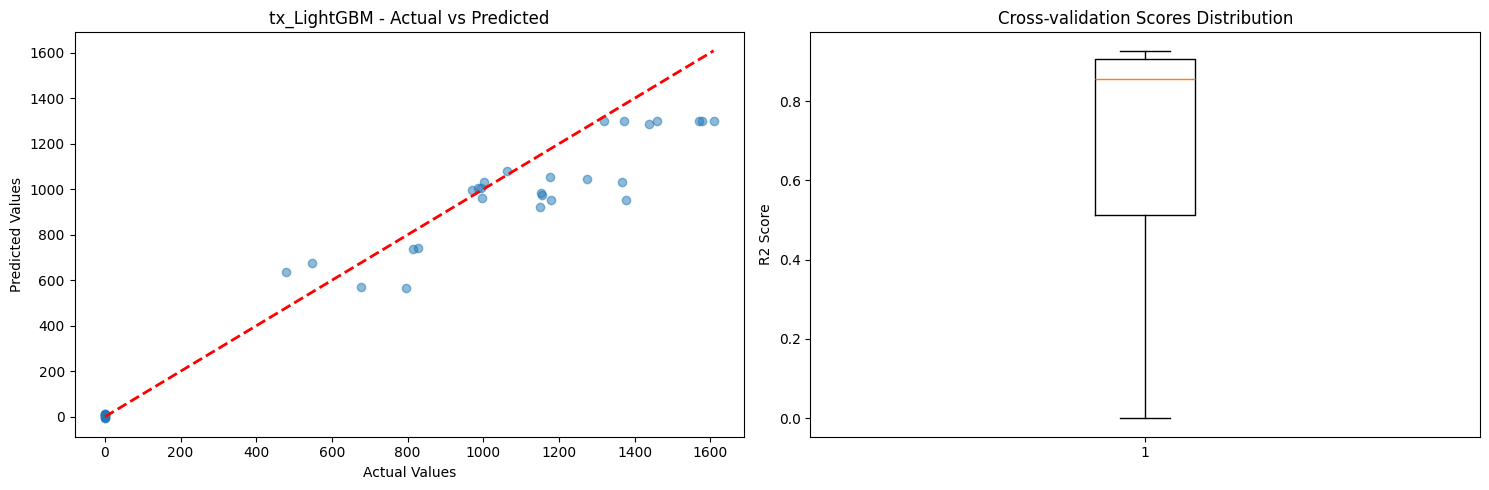


Evaluating RX Bandwidth Models:

Evaluating rx_RandomForest...



Detailed Results for rx_RandomForest:

Regression Metrics:
  Training R2: 0.9871
  Testing R2: 0.9437
  Training RMSE: 310.6365
  Testing RMSE: 732.7216
  Training MAE: 163.4369
  Testing MAE: 418.8629
  Training Relative Accuracy: 96.65%
  Testing Relative Accuracy: 92.89%

Cross-Validation Results:
  Mean CV Score: 0.9388 (+/- 0.0683)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


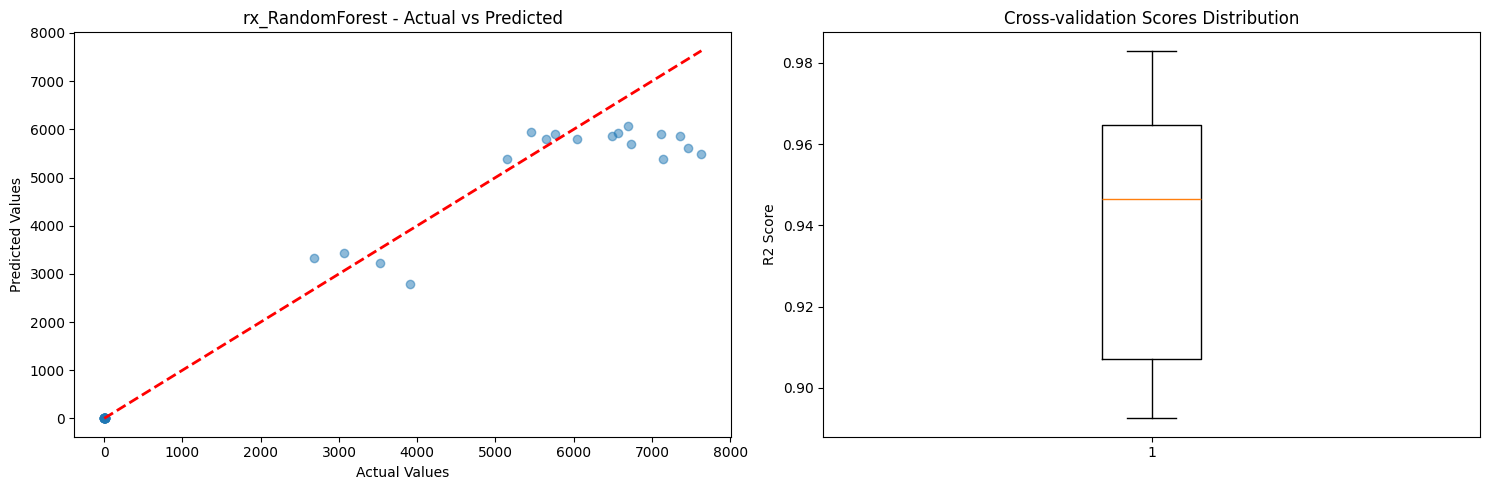


Evaluating rx_XGBoost...



Detailed Results for rx_XGBoost:

Regression Metrics:
  Training R2: 0.9907
  Testing R2: 0.9379
  Training RMSE: 263.7145
  Testing RMSE: 770.0005
  Training MAE: 96.8401
  Testing MAE: 440.9590
  Training Relative Accuracy: -340.43%
  Testing Relative Accuracy: -345.81%

Cross-Validation Results:
  Mean CV Score: 0.9255 (+/- 0.0755)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


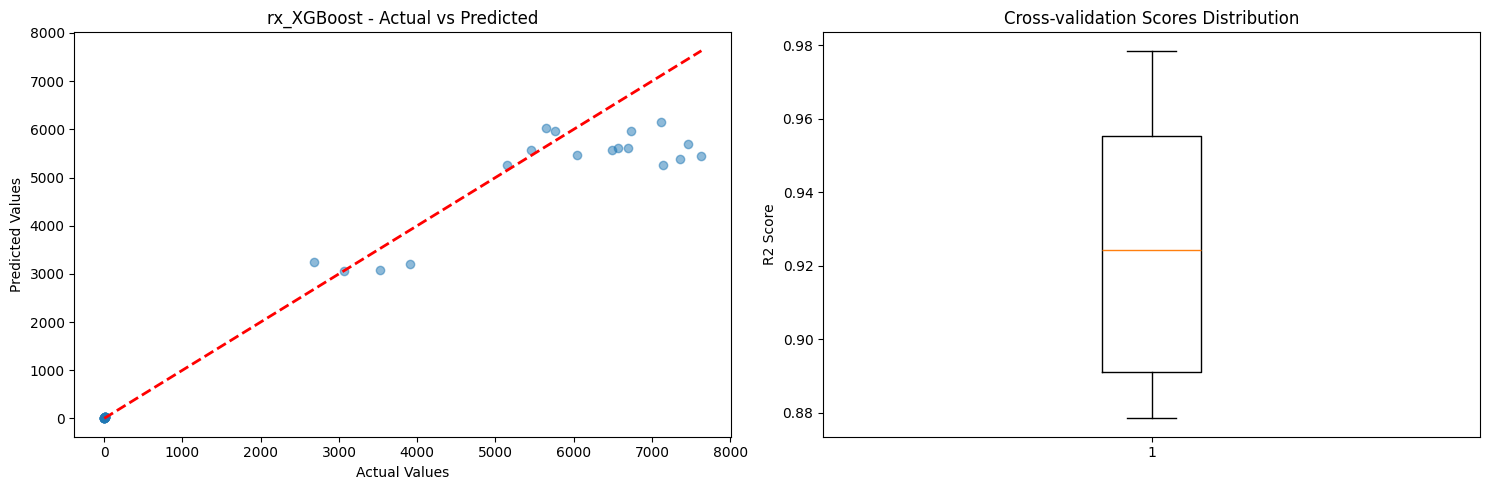


Evaluating rx_LightGBM...



Detailed Results for rx_LightGBM:

Regression Metrics:
  Training R2: 0.9617
  Testing R2: 0.9403
  Training RMSE: 534.9559
  Testing RMSE: 754.6219
  Training MAE: 327.9449
  Testing MAE: 471.3962
  Training Relative Accuracy: -2492.53%
  Testing Relative Accuracy: -2229.96%

Cross-Validation Results:
  Mean CV Score: 0.7268 (+/- 0.7350)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


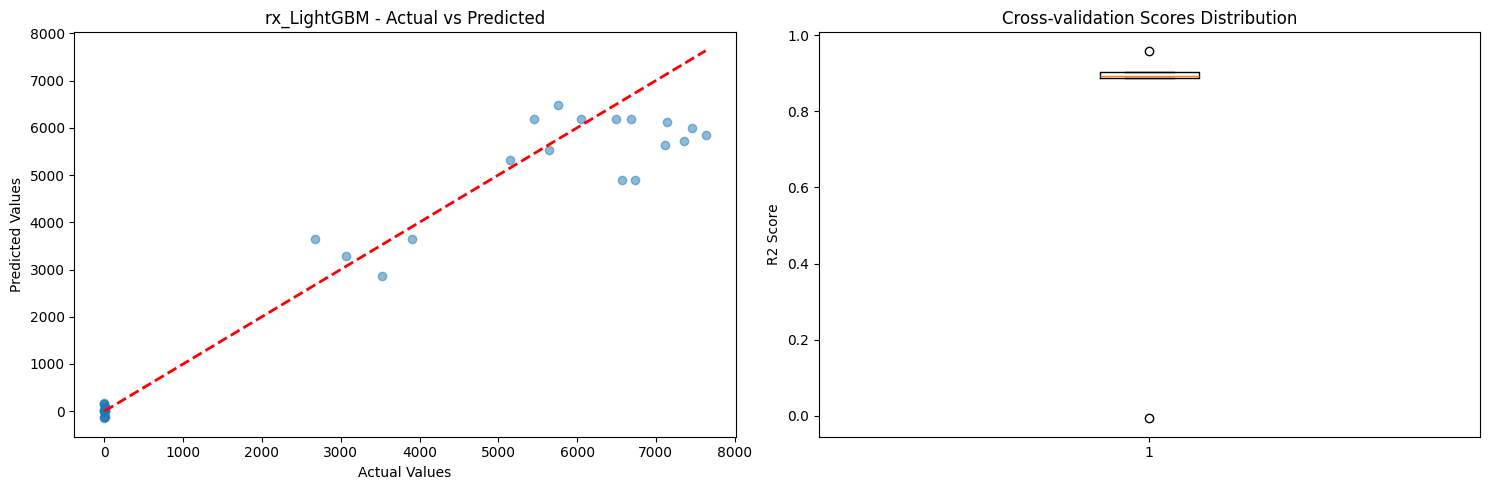


=== COMPREHENSIVE MODEL EVALUATION SUMMARY ===

TX Bandwidth Models:

tx_RandomForest:
  Test R2: 0.9246
  Test RMSE: 151.5332
  CV Score: 0.9399
  Status: Good Fit

tx_XGBoost:
  Test R2: 0.9195
  Test RMSE: 156.5169
  CV Score: 0.9330
  Status: Good Fit

tx_LightGBM:
  Test R2: 0.9137
  Test RMSE: 162.1195
  CV Score: 0.6409
  Status: Good Fit

Best tx model: tx_RandomForest (R2=0.9246)

RX Bandwidth Models:

rx_RandomForest:
  Test R2: 0.9437
  Test RMSE: 732.7216
  CV Score: 0.9388
  Status: Good Fit

rx_XGBoost:
  Test R2: 0.9379
  Test RMSE: 770.0005
  CV Score: 0.9255
  Status: Good Fit

rx_LightGBM:
  Test R2: 0.9403
  Test RMSE: 754.6219
  CV Score: 0.7268
  Status: Good Fit

Best rx model: rx_RandomForest (R2=0.9437)


In [9]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {}
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()
        self.interface_capacity = {
            '10ge0/0': 10000,
            'ge2/0': 10000,
            'ge2/1': 10000,
            'mgmt0': 10000
        }

    def load_data(self, file_path):
        """Load data dari file JSON"""
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                print(f"Data berhasil dimuat: {len(df)} baris")
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan")
            return None

    def assess_data(self, df):
        """Melakukan penilaian awal pada data"""
        try:
            # Konversi entry_time ke datetime
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Menambahkan fitur temporal
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            print("Data assessment selesai")
            return df
        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        """Membersihkan data"""
        try:
            # Hapus duplikasi
            df_cleaned = df.drop_duplicates()

            # Filter interface
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(self.interface_capacity.keys())]

            # Handle outliers dengan IQR
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                    (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]

            print("Data cleaning selesai")
            return df_cleaned
        except Exception as e:
            print(f"Error in data cleaning: {e}")
            return None

    def feature_engineering(self, df):
        """Melakukan feature engineering pada dataset"""
        try:
            print("\n=== Feature Engineering ===")

            # Total bandwidth
            print("Menambahkan kolom total_kbps...")
            df['total_kbps'] = df['tx_kbps'] + df['rx_kbps']

            # Usage percentage
            print("Menambahkan kolom usage_percentage...")
            df['usage_percentage'] = df.apply(
                lambda row: (row['total_kbps'] / self.interface_capacity.get(row['interface'], 10000)) * 100,
                axis=1
            )

            # Time since last entry
            print("Menambahkan kolom time_since_last_entry...")
            df['time_since_last_entry'] = df.groupby('interface')['entry_time'].diff().dt.total_seconds().fillna(0)

            # Bandwidth change
            print("Menambahkan kolom bandwidth_change...")
            df['bandwidth_change'] = df.groupby('interface')['total_kbps'].diff().fillna(0)

            # Lag & rolling features: hanya memakai nilai dari periode SEBELUMNYA,
            # sehingga model tidak "melihat" nilai tx/rx yang sedang diprediksi (bebas data leakage)
            print("Menambahkan fitur lag dan rolling (historis)...")
            df = df.sort_values(['interface', 'entry_time'])
            df['interface_encoded'] = self.label_encoder.fit_transform(df['interface'])
            for col in ['tx_kbps', 'rx_kbps']:
                grp = df.groupby('interface')[col]
                df[f'{col}_lag1'] = grp.shift(1)
                df[f'{col}_lag2'] = grp.shift(2)
                df[f'{col}_rolling3'] = grp.transform(lambda s: s.shift(1).rolling(3).mean())
            df = df.sort_values(['entry_time', 'interface'])

            print("\nFeature Engineering selesai.")
            print("Kolom yang tersedia:", df.columns.tolist())
            return df

        except Exception as e:
            print(f"Error dalam feature engineering: {e}")
            return None

    def split_data(self, df):
        """Memisahkan data menjadi training dan testing sets"""
        try:
            print("\n=== Splitting Data ===")

            # Catatan: total_kbps, usage_percentage, dan bandwidth_change dihitung dari tx/rx
            # pada waktu yang sama, jadi TIDAK dipakai sebagai fitur (menghindari data leakage)
            features = ['day_of_week', 'is_weekend', 'interface_encoded',
                        'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3',
                        'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']
            target = ['tx_kbps', 'rx_kbps']

            # Validasi kolom
            missing_features = [col for col in features if col not in df.columns]
            missing_target = [col for col in target if col not in df.columns]
            if missing_features or missing_target:
                print(f"Kolom yang tidak ditemukan: {missing_features + missing_target}")
                print("Kolom yang tersedia:", df.columns.tolist())
                raise ValueError("Beberapa kolom yang diperlukan tidak ditemukan")

            # Baris awal tiap interface belum punya histori (lag kosong) -> dibuang
            df_model = df.dropna(subset=features)
            X = df_model[features]
            y = df_model[target]

            # Split kronologis: 80% periode awal untuk training, 20% periode akhir untuk testing
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, shuffle=False
            )

            print(f"Training set shape: {X_train.shape}")
            print(f"Testing set shape: {X_test.shape}")

            self.datasets['X_train'] = X_train
            self.datasets['X_test'] = X_test
            self.datasets['y_train'] = y_train
            self.datasets['y_test'] = y_test

            return X_train, X_test, y_train, y_test

        except Exception as e:
            print(f"Error dalam splitting data: {e}")
            return None, None, None, None

    def train_models(self, X_train, y_train):
        """Melatih berbagai model machine learning"""
        try:
            print("\n=== Training Models ===")

            models = {
                'tx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'tx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'tx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'rx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
            }

            trained_models = {}

            # Training TX models
            print("\nTraining models untuk TX Bandwidth...")
            for name in ['tx_RandomForest', 'tx_XGBoost', 'tx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['tx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            # Training RX models
            print("\nTraining models untuk RX Bandwidth...")
            for name in ['rx_RandomForest', 'rx_XGBoost', 'rx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['rx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            self.models = trained_models
            return trained_models

        except Exception as e:
            print(f"Error dalam training models: {e}")
            return None

    def analyze_feature_importance(self, trained_models=None, X=None):
        """Menganalisis dan memvisualisasikan feature importance dari model"""
        try:
            print("\n=== Feature Importance Analysis ===")

            if trained_models is None and hasattr(self, 'models'):
                trained_models = self.models

            if X is None and 'X_train' in self.datasets:
                X = self.datasets['X_train']

            if trained_models is None or X is None:
                raise ValueError("Model atau data fitur tidak tersedia")

            feature_names = X.columns
            importance_results = {}

            # Analisis untuk model TX dan RX
            for bandwidth_type in ['tx', 'rx']:
                print(f"\nFeature Importance untuk {bandwidth_type.upper()} Bandwidth:")

                # Preferensi model: RandomForest > XGBoost > LightGBM
                preferred_models = [
                    f"{bandwidth_type}_RandomForest",
                    f"{bandwidth_type}_XGBoost",
                    f"{bandwidth_type}_LightGBM"
                ]

                model_name = None
                for name in preferred_models:
                    if name in trained_models:
                        model_name = name
                        break

                if model_name is None:
                    print(f"Tidak ada model yang tersedia untuk {bandwidth_type}")
                    continue

                model = trained_models[model_name]

                # Ekstrak feature importance
                if model_name.endswith('RandomForest'):
                    importances = model.feature_importances_
                    std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
                    indices = np.argsort(importances)[::-1]

                    # Plot feature importance
                    plt.figure(figsize=(12, 8))
                    plt.title(f'Feature Importance for {model_name}')
                    plt.bar(range(X.shape[1]), importances[indices], yerr=std[indices], align='center')
                    plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
                    plt.xlim([-1, X.shape[1]])
                    plt.tight_layout()
                    plt.show()

                    # Menampilkan feature importance dalam bentuk tabel
                    importance_df = pd.DataFrame({
                        'Feature': feature_names,
                        'Importance': importances
                    }).sort_values(by='Importance', ascending=False)

                    print("\nFeature Importance Ranking:")
                    for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
                        print(f"{i+1}. {feature}: {importance:.4f}")

                    importance_results[bandwidth_type] = importance_df

                elif model_name.endswith('XGBoost') or model_name.endswith('LightGBM'):
                    if hasattr(model, 'feature_importances_'):
                        importances = model.feature_importances_
                        indices = np.argsort(importances)[::-1]

                        # Plot feature importance
                        plt.figure(figsize=(12, 8))
                        plt.title(f'Feature Importance for {model_name}')
                        plt.bar(range(X.shape[1]), importances[indices], align='center')
                        plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
                        plt.xlim([-1, X.shape[1]])
                        plt.tight_layout()
                        plt.show()

                        # Menampilkan feature importance dalam bentuk tabel
                        importance_df = pd.DataFrame({
                            'Feature': feature_names,
                            'Importance': importances
                        }).sort_values(by='Importance', ascending=False)

                        print("\nFeature Importance Ranking:")
                        for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
                            print(f"{i+1}. {feature}: {importance:.4f}")

                        importance_results[bandwidth_type] = importance_df
                    else:
                        print(f"Model {model_name} tidak memiliki atribut feature_importances_")
                else:
                    print(f"Model {model_name} tidak mendukung feature importance")

            # Perbandingan feature importance antar model TX dan RX
            if len(importance_results) == 2:
                tx_importance = importance_results['tx'].set_index('Feature')
                rx_importance = importance_results['rx'].set_index('Feature')

                # Gabungkan importance TX dan RX
                combined_importance = pd.DataFrame({
                    'TX Importance': tx_importance['Importance'],
                    'RX Importance': rx_importance['Importance']
                })

                # Plot perbandingan
                plt.figure(figsize=(12, 8))
                combined_importance.plot(kind='bar', figsize=(12, 8))
                plt.title('Feature Importance Comparison: TX vs RX')
                plt.xlabel('Features')
                plt.ylabel('Importance')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.legend()
                plt.show()

                print("\nFeature Importance Comparison (TX vs RX):")
                display(combined_importance.sort_values(by='TX Importance', ascending=False))

            self.importance_results = importance_results
            return importance_results

        except Exception as e:
            print(f"Error dalam analisis feature importance: {e}")
            return None

    def evaluate_model_performance(self, trained_models, X_train, X_test, y_train, y_test):
        """Mengevaluasi performa model secara komprehensif dengan cross-validation"""
        try:
            print("\n=== Comprehensive Model Evaluation ===")
            performance_results = {}

            # Inisialisasi K-Fold
            kf = TimeSeriesSplit(n_splits=5)  # CV kronologis untuk data time series

            # Evaluasi untuk model TX dan RX
            for bandwidth_type in ['tx', 'rx']:
                print(f"\nEvaluating {bandwidth_type.upper()} Bandwidth Models:")

                model_metrics = {}
                target_col = f'{bandwidth_type}_kbps'

                for model_name in [f'{bandwidth_type}_RandomForest', f'{bandwidth_type}_XGBoost', f'{bandwidth_type}_LightGBM']:
                    print(f"\nEvaluating {model_name}...")
                    model = trained_models[model_name]

                    # Cross-validation scores
                    cv_scores = []
                    for train_idx, val_idx in kf.split(X_train):
                        # Split data
                        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
                        y_train_cv, y_val_cv = y_train[target_col].iloc[train_idx], y_train[target_col].iloc[val_idx]

                        # Train and predict
                        model.fit(X_train_cv, y_train_cv)
                        y_pred_cv = model.predict(X_val_cv)

                        # Calculate score
                        score = r2_score(y_val_cv, y_pred_cv)
                        cv_scores.append(score)

                    # Training metrics
                    train_pred = model.predict(X_train)
                    train_r2 = r2_score(y_train[target_col], train_pred)
                    train_rmse = np.sqrt(mean_squared_error(y_train[target_col], train_pred))
                    train_mae = mean_absolute_error(y_train[target_col], train_pred)
                    train_relative_accuracy = (1 - np.abs(train_pred - y_train[target_col]) / (np.abs(y_train[target_col]) + 1e-6)).mean() * 100

                    # Testing metrics
                    test_pred = model.predict(X_test)
                    test_r2 = r2_score(y_test[target_col], test_pred)
                    test_rmse = np.sqrt(mean_squared_error(y_test[target_col], test_pred))
                    test_mae = mean_absolute_error(y_test[target_col], test_pred)
                    test_relative_accuracy = (1 - np.abs(test_pred - y_test[target_col]) / (np.abs(y_test[target_col]) + 1e-6)).mean() * 100

                    # Calculate additional metrics for imbalanced data
                    threshold = np.median(y_test[target_col])
                    y_test_binary = (y_test[target_col] > threshold).astype(int)
                    y_pred_binary = (test_pred > threshold).astype(int)

                    precision = precision_score(y_test_binary, y_pred_binary)
                    recall = recall_score(y_test_binary, y_pred_binary)
                    f1 = f1_score(y_test_binary, y_pred_binary)

                    metrics = {
                        'train_r2': train_r2,
                        'test_r2': test_r2,
                        'train_rmse': train_rmse,
                        'test_rmse': test_rmse,
                        'train_mae': train_mae,
                        'test_mae': test_mae,
                        'train_relative_accuracy': train_relative_accuracy,
                        'test_relative_accuracy': test_relative_accuracy,
                        'cv_scores_mean': np.mean(cv_scores),
                        'cv_scores_std': np.std(cv_scores),
                        'precision': precision,
                        'recall': recall,
                        'f1_score': f1
                    }

                    # Model status evaluation
                    if (train_r2 - test_r2) > 0.1:
                        metrics['warning'] = 'Possible Overfitting'
                    elif (train_r2 < 0.5) and (test_r2 < 0.5):
                        metrics['warning'] = 'Possible Underfitting'
                    else:
                        metrics['warning'] = 'Good Fit'

                    model_metrics[model_name] = metrics

                    # Print comprehensive results
                    print(f"\nDetailed Results for {model_name}:")
                    print("\nRegression Metrics:")
                    print(f"  Training R2: {train_r2:.4f}")
                    print(f"  Testing R2: {test_r2:.4f}")
                    print(f"  Training RMSE: {train_rmse:.4f}")
                    print(f"  Testing RMSE: {test_rmse:.4f}")
                    print(f"  Training MAE: {train_mae:.4f}")
                    print(f"  Testing MAE: {test_mae:.4f}")
                    print(f"  Training Relative Accuracy: {train_relative_accuracy:.2f}%")
                    print(f"  Testing Relative Accuracy: {test_relative_accuracy:.2f}%")

                    print("\nCross-Validation Results:")
                    print(f"  Mean CV Score: {metrics['cv_scores_mean']:.4f} (+/- {metrics['cv_scores_std']*2:.4f})")

                    print("\nImbalanced Data Metrics:")
                    print(f"  Precision: {metrics['precision']:.4f}")
                    print(f"  Recall: {metrics['recall']:.4f}")
                    print(f"  F1-Score: {metrics['f1_score']:.4f}")

                    print(f"\nModel Status: {metrics['warning']}")

                    # Visualization
                    plt.figure(figsize=(15, 5))
                    plt.subplot(1, 2, 1)
                    plt.scatter(y_test[target_col], test_pred, alpha=0.5)
                    plt.plot([y_test[target_col].min(), y_test[target_col].max()],
                            [y_test[target_col].min(), y_test[target_col].max()],
                            'r--', lw=2)
                    plt.title(f'{model_name} - Actual vs Predicted')
                    plt.xlabel('Actual Values')
                    plt.ylabel('Predicted Values')

                    plt.subplot(1, 2, 2)
                    plt.boxplot(cv_scores)
                    plt.title('Cross-validation Scores Distribution')
                    plt.ylabel('R2 Score')

                    plt.tight_layout()
                    plt.show()

                performance_results[bandwidth_type] = model_metrics

            self.performance_results = performance_results
            return performance_results

        except Exception as e:
            print(f"Error dalam evaluasi model komprehensif: {e}")
            return None


def main():
    # Inisialisasi analyzer
    analyzer = BandwidthAnalyzer()

    # Load dan proses data
    file_path = '../data/sample_hub_data.json'
    df_loaded = analyzer.load_data(file_path)

    if df_loaded is not None:
        # Process data
        df_assessed = analyzer.assess_data(df_loaded)
        if df_assessed is not None:
            df_cleaned = analyzer.clean_data(df_assessed)
            if df_cleaned is not None:
                # Feature engineering
                df_featured = analyzer.feature_engineering(df_cleaned)
                if df_featured is not None:
                    # Split data
                    X_train, X_test, y_train, y_test = analyzer.split_data(df_featured)
                    if X_train is not None:
                        # Train models
                        trained_models = analyzer.train_models(X_train, y_train)
                        if trained_models is not None:
                            # Analisis feature importance
                            importance_results = analyzer.analyze_feature_importance(
                                trained_models, X_train
                            )

                            # Evaluasi komprehensif
                            performance_results = analyzer.evaluate_model_performance(
                                trained_models, X_train, X_test, y_train, y_test
                            )

                            if performance_results is not None:
                                # Ringkasan evaluasi
                                print("\n=== COMPREHENSIVE MODEL EVALUATION SUMMARY ===")
                                for bandwidth_type in ['tx', 'rx']:
                                    best_model = None
                                    best_score = -float('inf')

                                    print(f"\n{bandwidth_type.upper()} Bandwidth Models:")
                                    for model_name, metrics in performance_results[bandwidth_type].items():
                                        print(f"\n{model_name}:")
                                        print(f"  Test R2: {metrics['test_r2']:.4f}")
                                        print(f"  Test RMSE: {metrics['test_rmse']:.4f}")
                                        print(f"  CV Score: {metrics['cv_scores_mean']:.4f}")
                                        print(f"  Status: {metrics['warning']}")

                                        # Find best model
                                        if metrics['test_r2'] > best_score:
                                            best_score = metrics['test_r2']
                                            best_model = model_name

                                    # Save best model
                                    print(f"\nBest {bandwidth_type} model: {best_model} (R2={best_score:.4f})")
                                    joblib.dump(trained_models[best_model], f"best_{bandwidth_type}_model.pkl")
                            else:
                                print("Evaluasi model gagal.")
                        else:
                            print("Training model gagal.")
                    else:
                        print("Split data gagal.")
                else:
                    print("Feature engineering gagal.")
            else:
                print("Cleaning data gagal.")
        else:
            print("Assessment data gagal.")
    else:
        print("Loading data gagal.")


if __name__ == "__main__":
    main()

## Threshold, Anomaly Detection & Bandwidth Optimization (Full Pipeline)

Data berhasil dimuat: 240 baris
Data assessment selesai
Data cleaning selesai

=== Feature Engineering ===
Menambahkan kolom total_kbps...
Menambahkan kolom usage_percentage...
Menambahkan kolom time_since_last_entry...
Menambahkan kolom bandwidth_change...
Menambahkan fitur lag dan rolling (historis)...

Feature Engineering selesai.
Kolom yang tersedia: ['entry_time', 'count', 'interface', 'tx_kbps', 'rx_kbps', 'hour', 'day_of_week', 'is_weekend', 'month', 'total_kbps', 'usage_percentage', 'time_since_last_entry', 'bandwidth_change', 'interface_encoded', 'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3', 'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']

=== Splitting Data ===
Training set shape: (144, 9)
Testing set shape: (36, 9)

=== Training Models ===

Training models untuk TX Bandwidth...

Training tx_RandomForest...

Training tx_XGBoost...

Training tx_LightGBM...

Training models untuk RX Bandwidth...

Training rx_RandomForest...

Training rx_XGBoost...

Training rx_LightGB

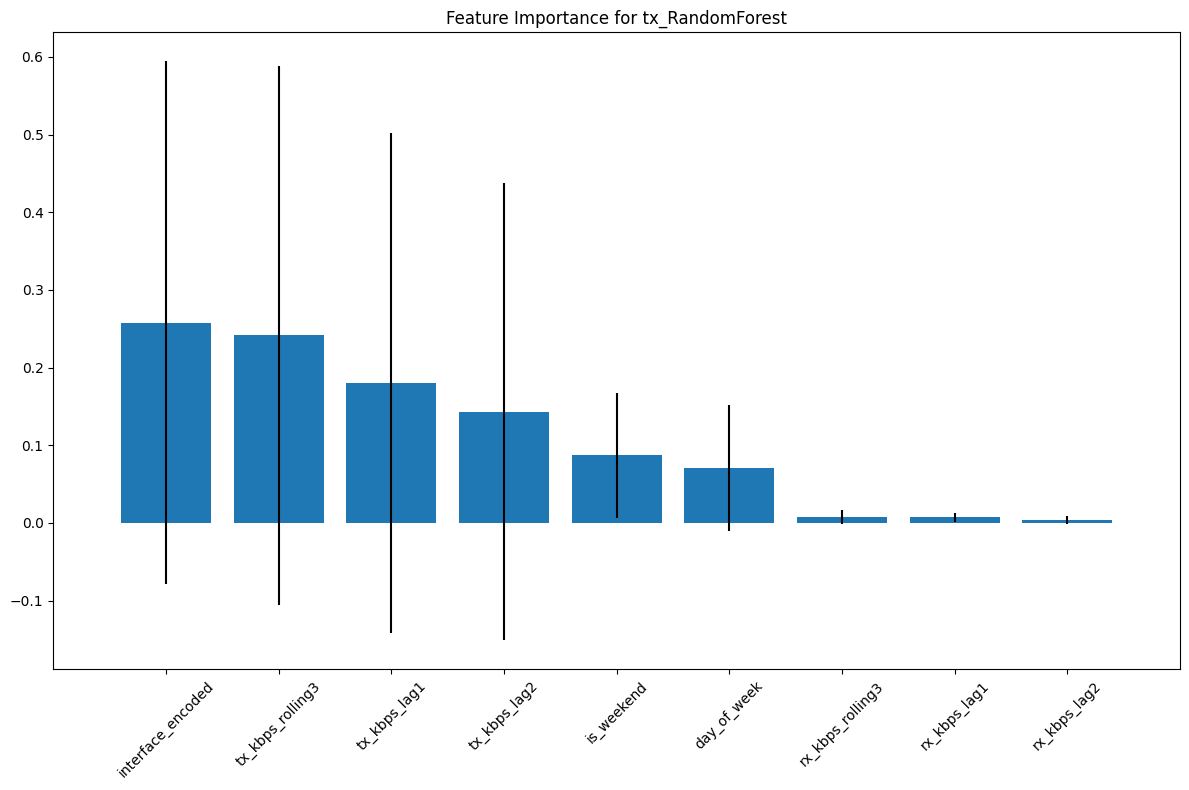


Feature Importance Ranking:
1. interface_encoded: 0.2579
2. tx_kbps_rolling3: 0.2416
3. tx_kbps_lag1: 0.1800
4. tx_kbps_lag2: 0.1433
5. is_weekend: 0.0873
6. day_of_week: 0.0709
7. rx_kbps_rolling3: 0.0074
8. rx_kbps_lag1: 0.0073
9. rx_kbps_lag2: 0.0043

Feature Importance untuk RX Bandwidth:


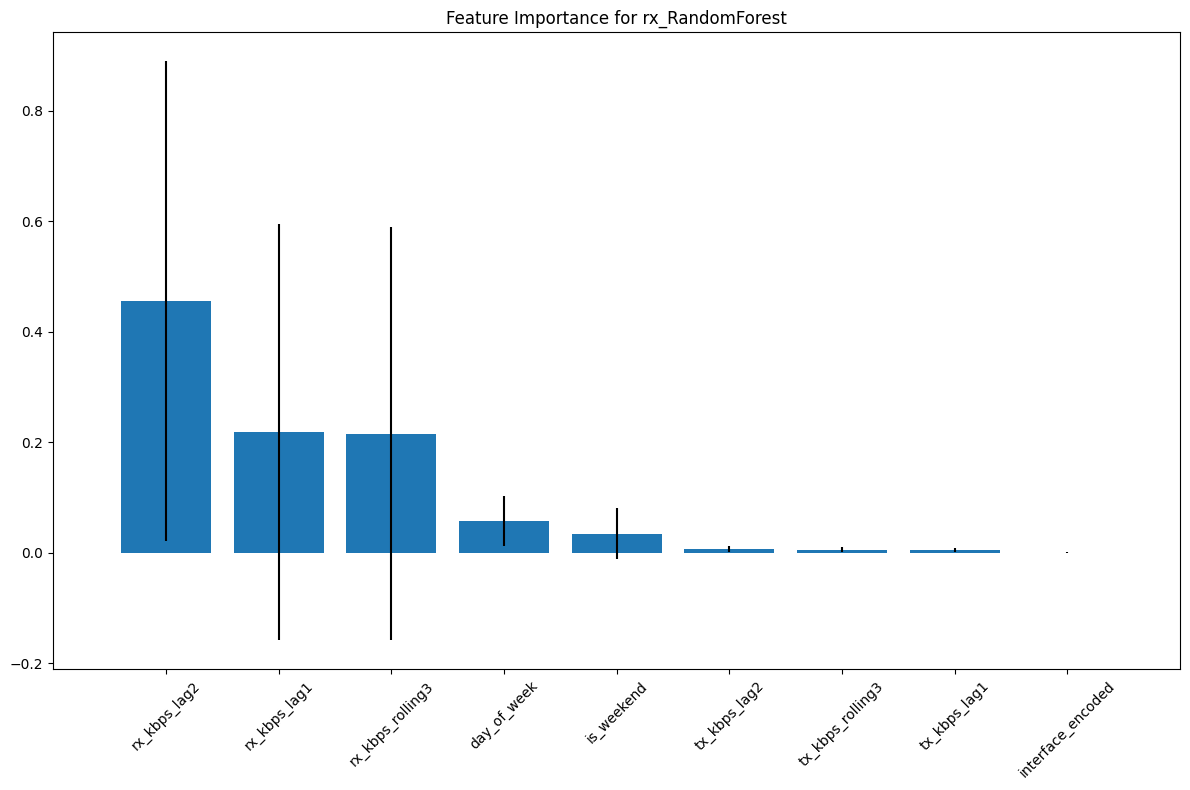


Feature Importance Ranking:
1. rx_kbps_lag2: 0.4555
2. rx_kbps_lag1: 0.2189
3. rx_kbps_rolling3: 0.2154
4. day_of_week: 0.0575
5. is_weekend: 0.0349
6. tx_kbps_lag2: 0.0073
7. tx_kbps_rolling3: 0.0054
8. tx_kbps_lag1: 0.0047
9. interface_encoded: 0.0004


<Figure size 1200x800 with 0 Axes>

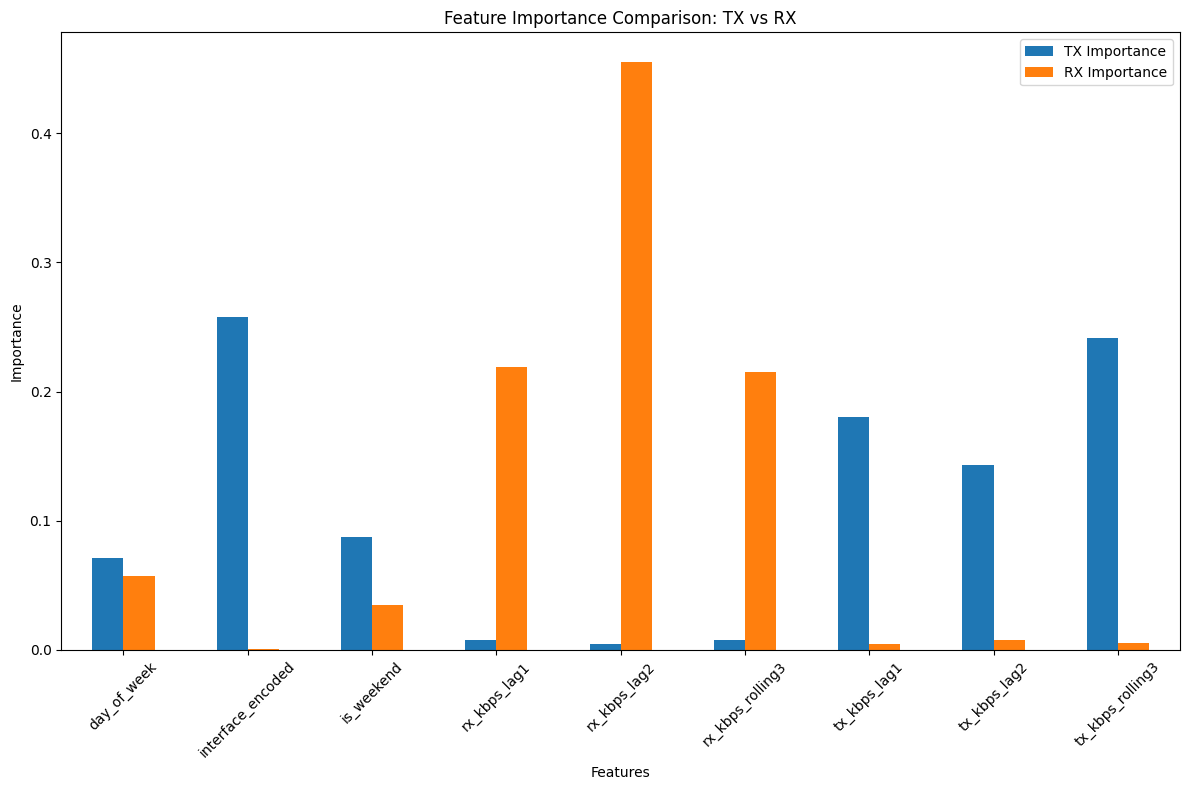


Feature Importance Comparison (TX vs RX):
                   TX Importance  RX Importance
Feature                                        
interface_encoded       0.257914       0.000361
tx_kbps_rolling3        0.241602       0.005411
tx_kbps_lag1            0.180017       0.004685
tx_kbps_lag2            0.143273       0.007339
is_weekend              0.087255       0.034865
day_of_week             0.070943       0.057468
rx_kbps_rolling3        0.007409       0.215412
rx_kbps_lag1            0.007316       0.218930
rx_kbps_lag2            0.004273       0.455530

=== STEP 2: TIME SERIES ANALYSIS ===

=== Time Series Analysis & Forecasting ===
Menyiapkan data time series...

Analisis time series untuk interface: 10ge0/0


<Figure size 1200x600 with 0 Axes>

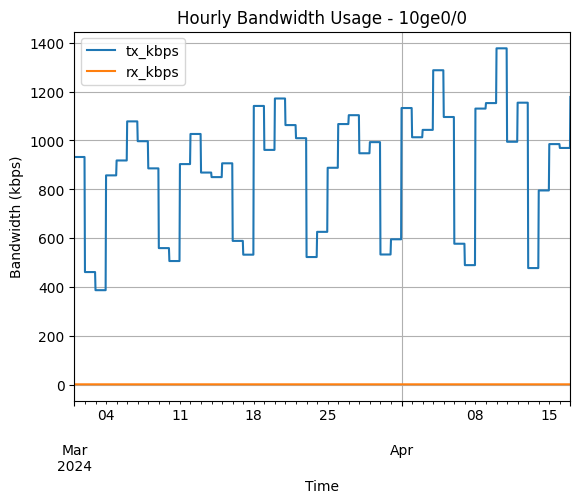


Decomposing time series untuk analisis pola...


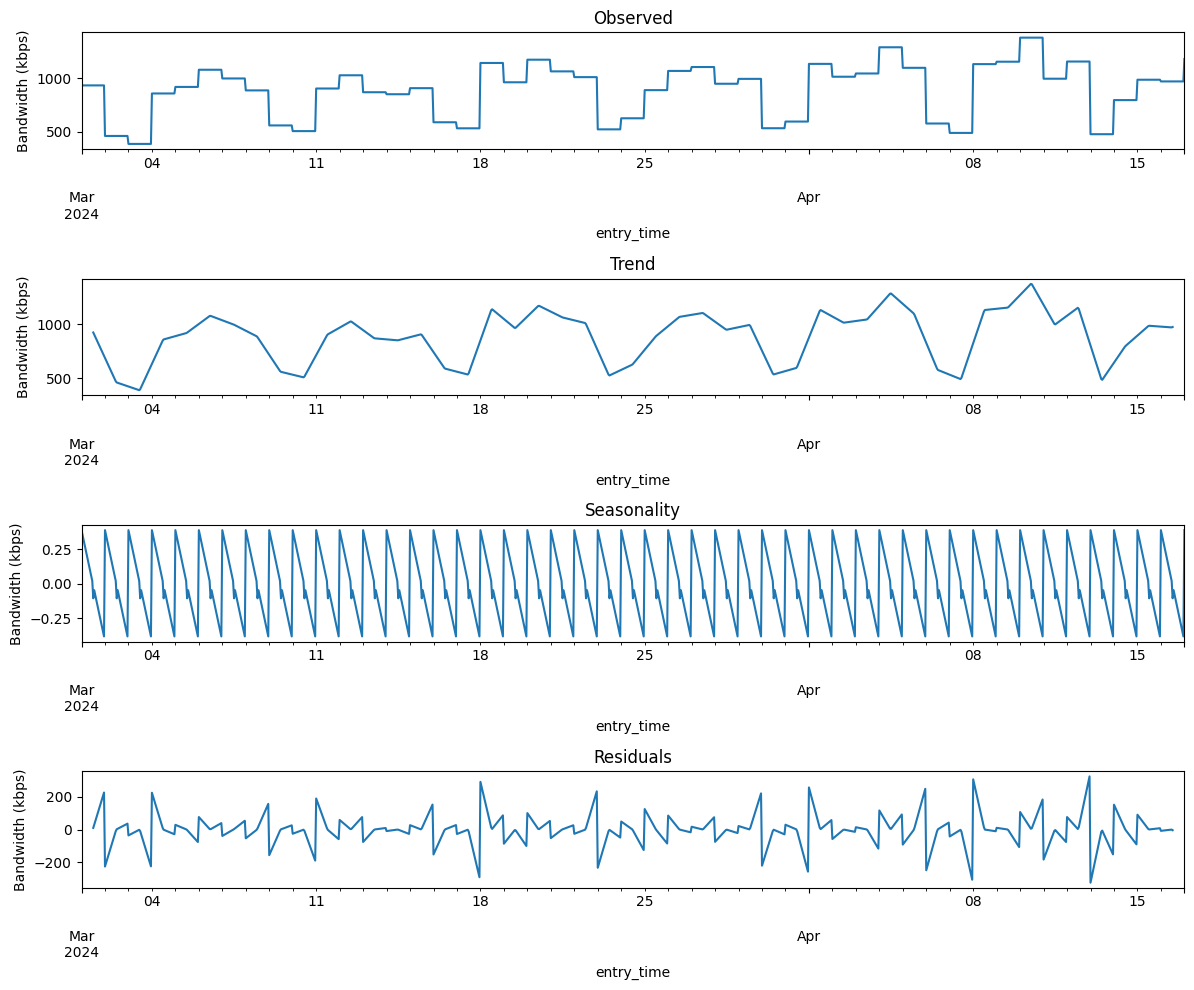


Melatih model SARIMAX untuk prediksi bandwidth...

Melatih model untuk tx_kbps...


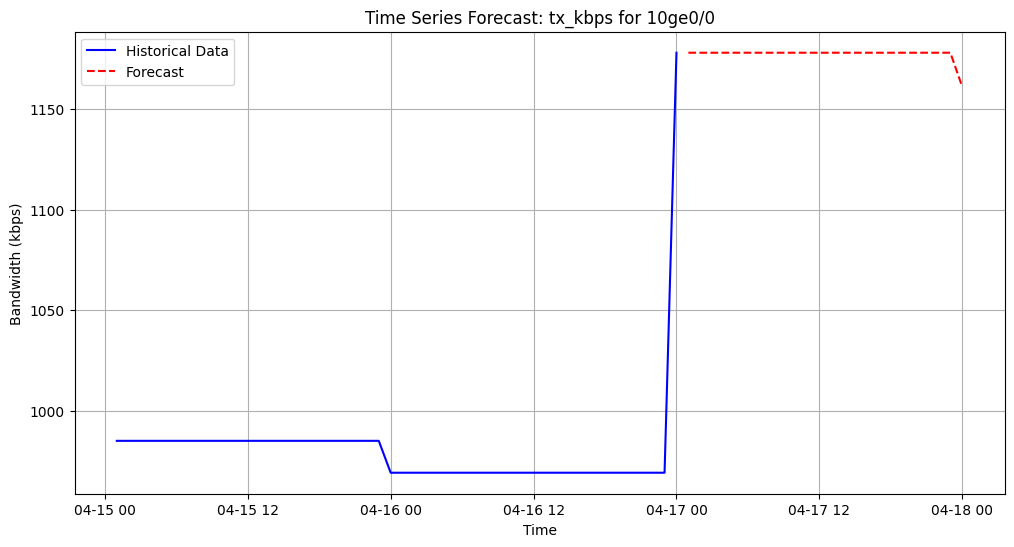

Training RMSE untuk tx_kbps: 67.80 kbps

Melatih model untuk rx_kbps...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


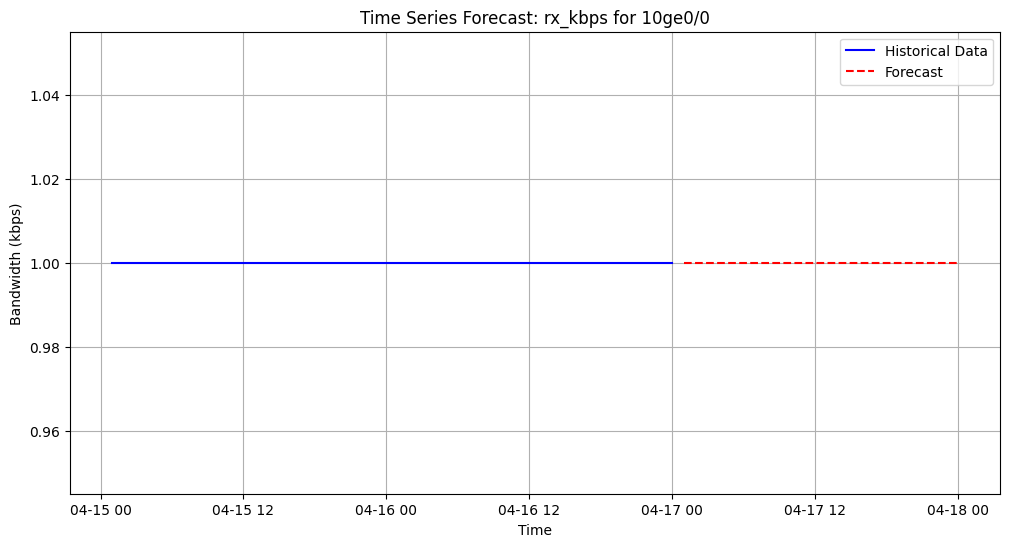

Training RMSE untuk rx_kbps: 0.01 kbps

Analisis time series untuk interface: ge2/0


<Figure size 1200x600 with 0 Axes>

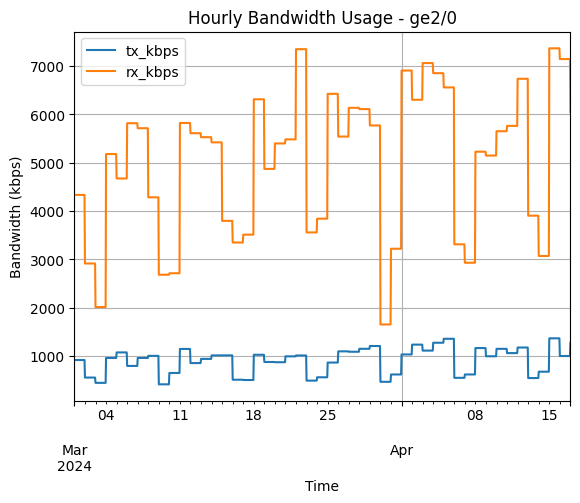


Decomposing time series untuk analisis pola...


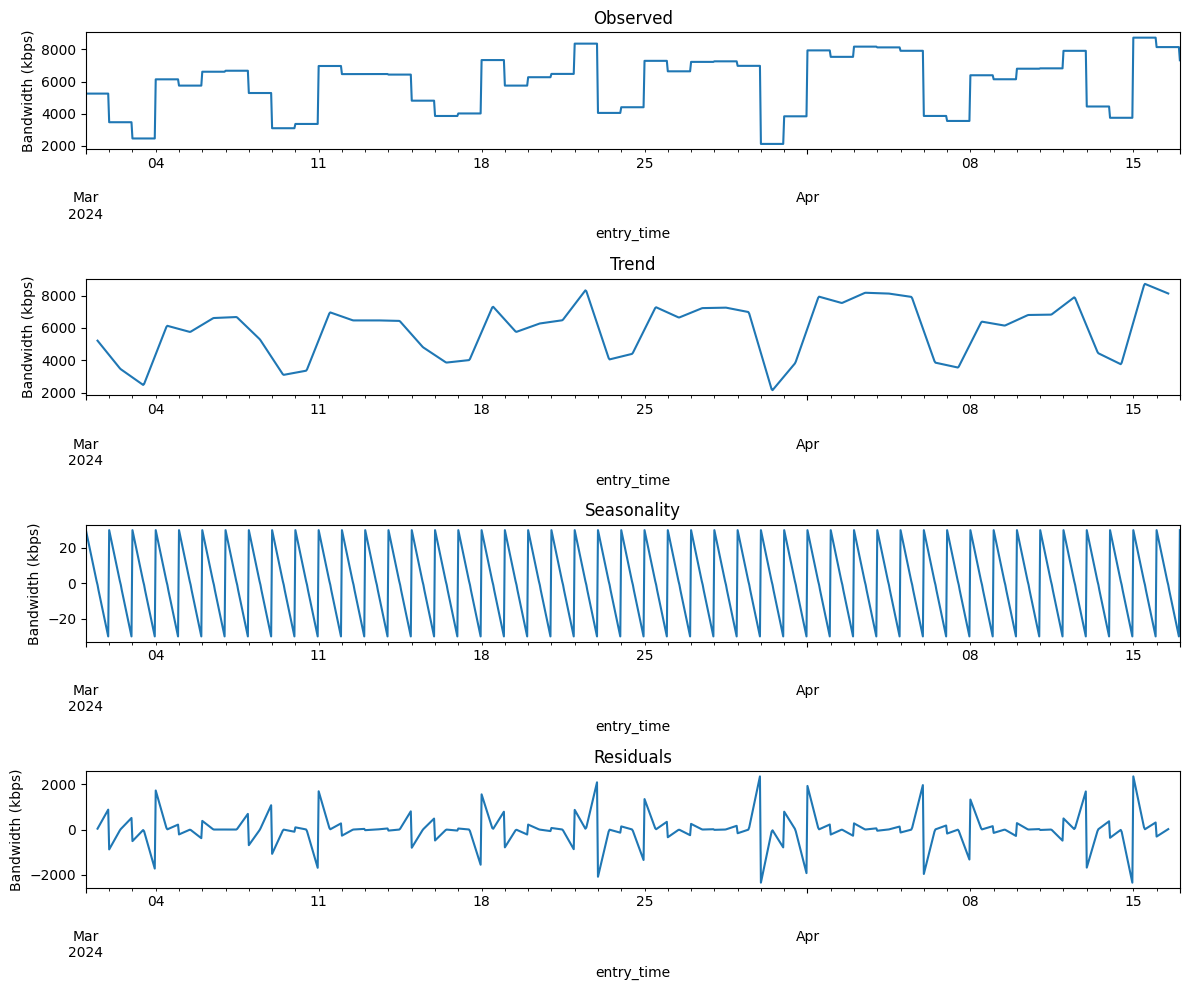


Melatih model SARIMAX untuk prediksi bandwidth...

Melatih model untuk tx_kbps...


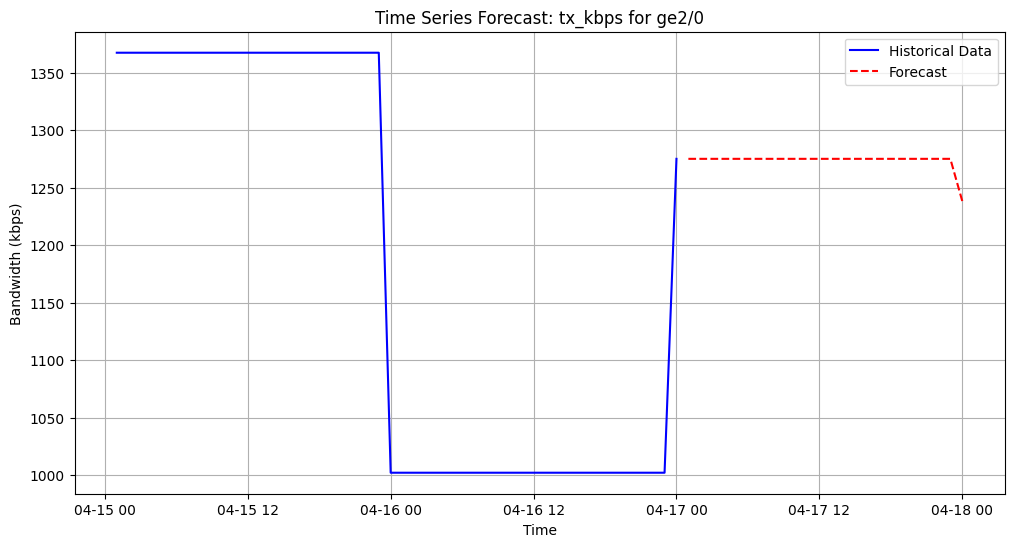

Training RMSE untuk tx_kbps: 74.30 kbps

Melatih model untuk rx_kbps...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


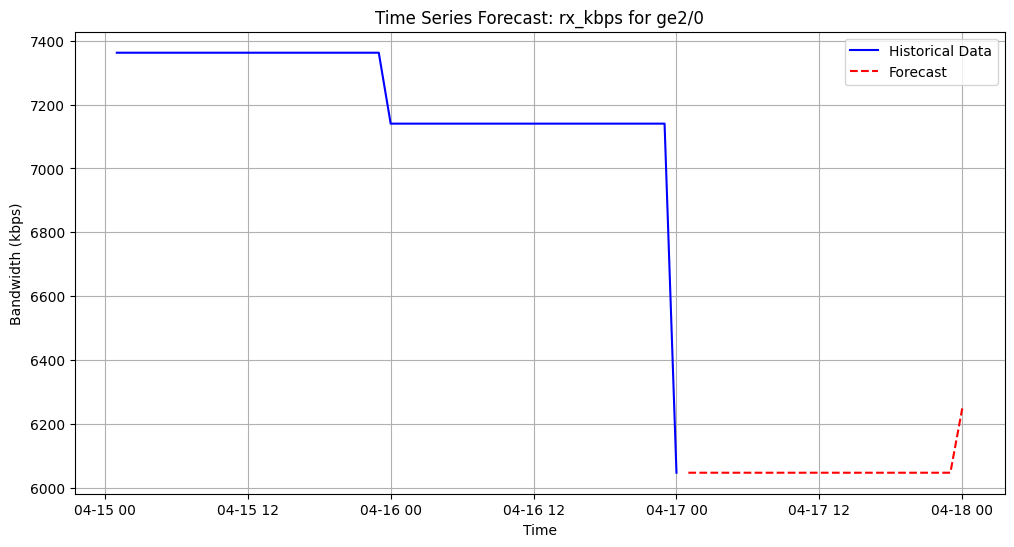

Training RMSE untuk rx_kbps: 384.63 kbps

Analisis time series untuk interface: ge2/1


<Figure size 1200x600 with 0 Axes>

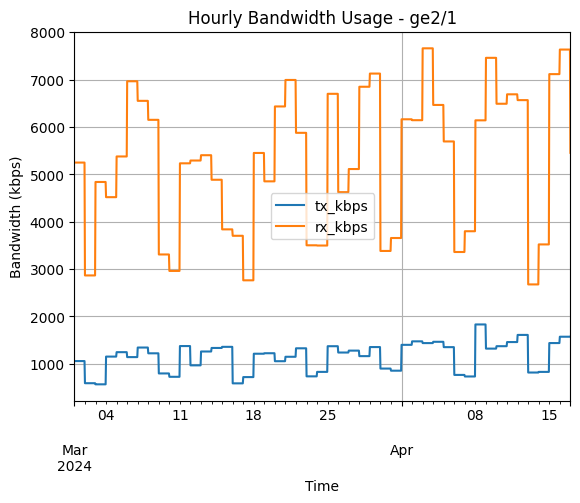


Decomposing time series untuk analisis pola...


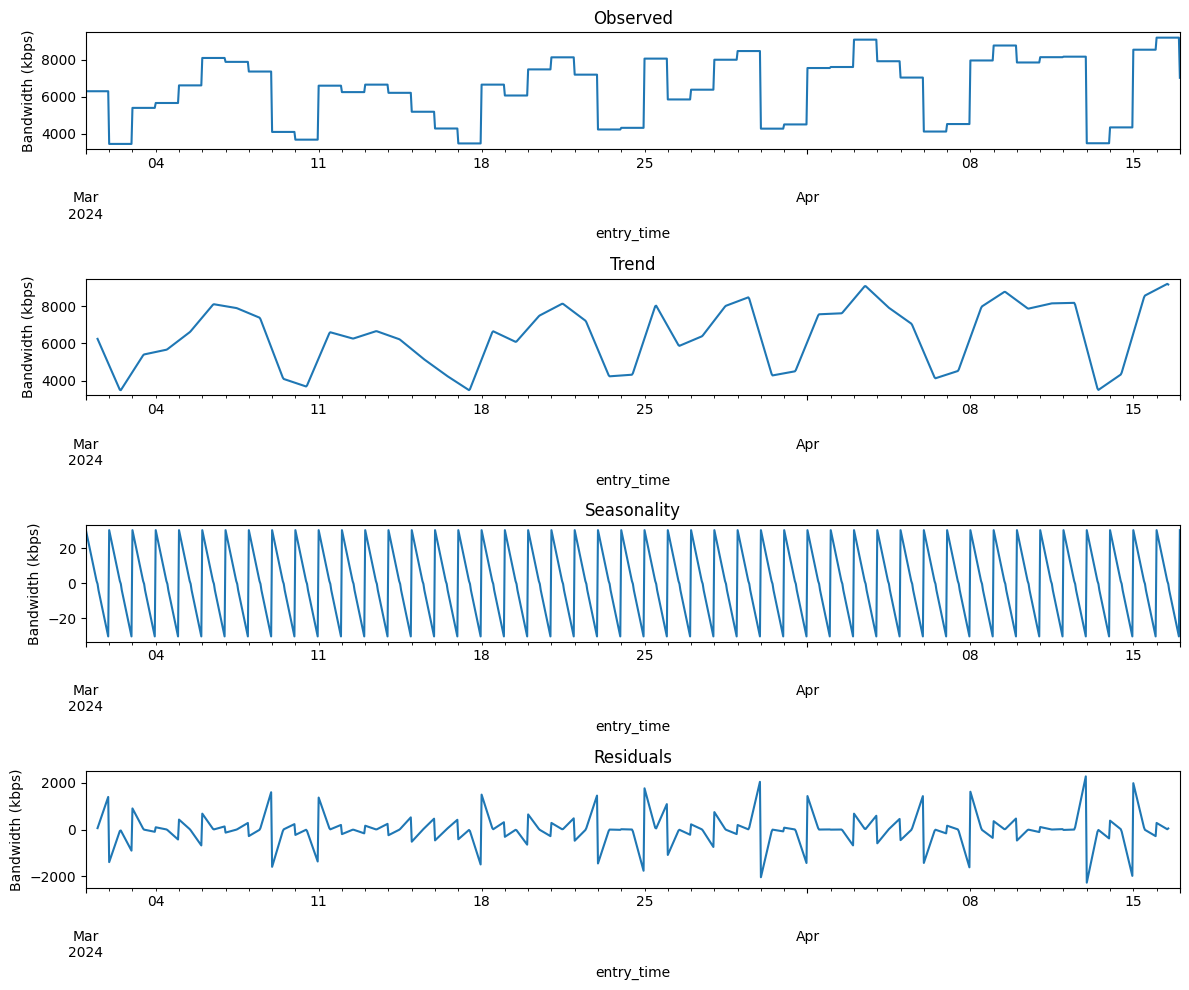


Melatih model SARIMAX untuk prediksi bandwidth...

Melatih model untuk tx_kbps...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  start_params = self.start_params


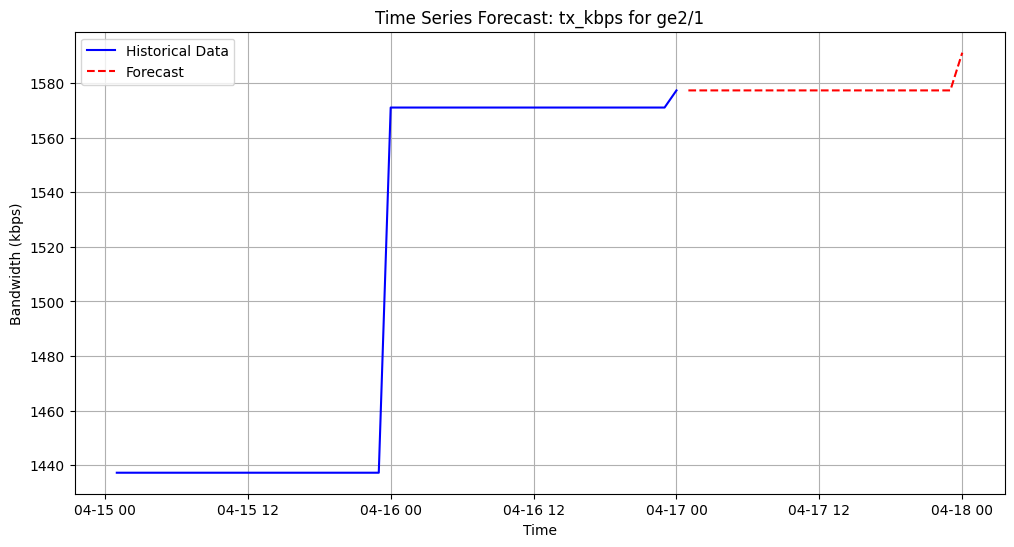

Training RMSE untuk tx_kbps: 84.00 kbps

Melatih model untuk rx_kbps...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  start_params = self.start_params


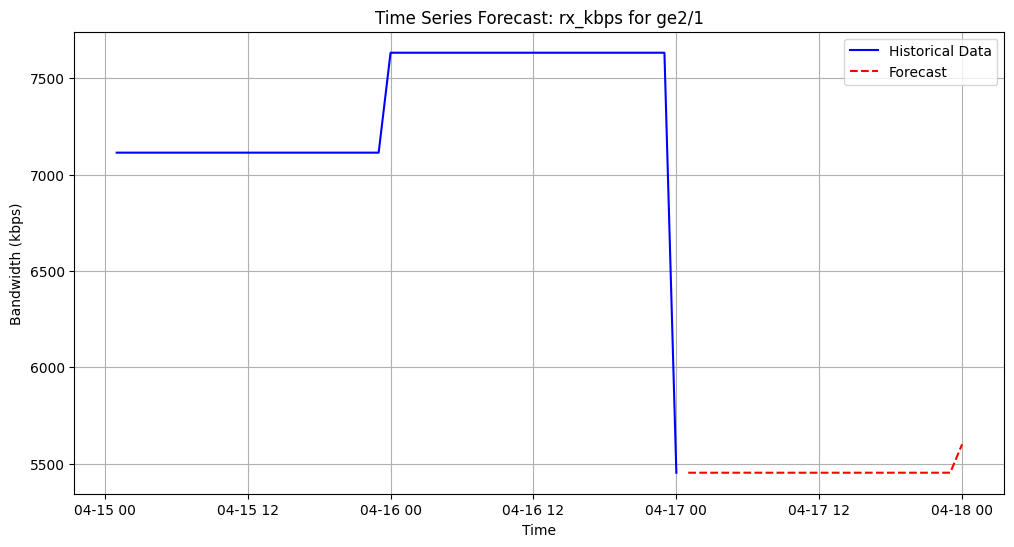

Training RMSE untuk rx_kbps: 387.54 kbps

Analisis time series untuk interface: mgmt0


<Figure size 1200x600 with 0 Axes>

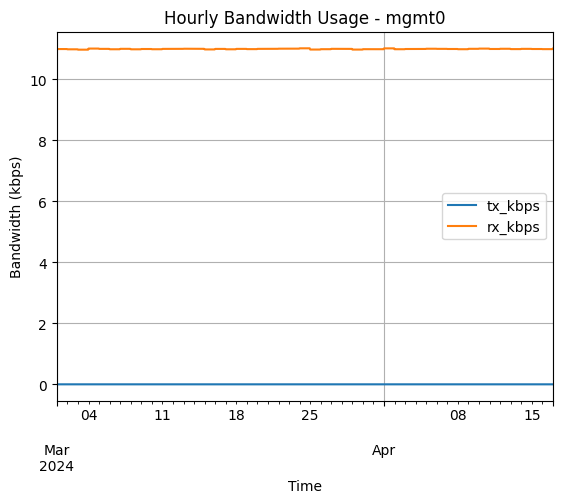


Decomposing time series untuk analisis pola...


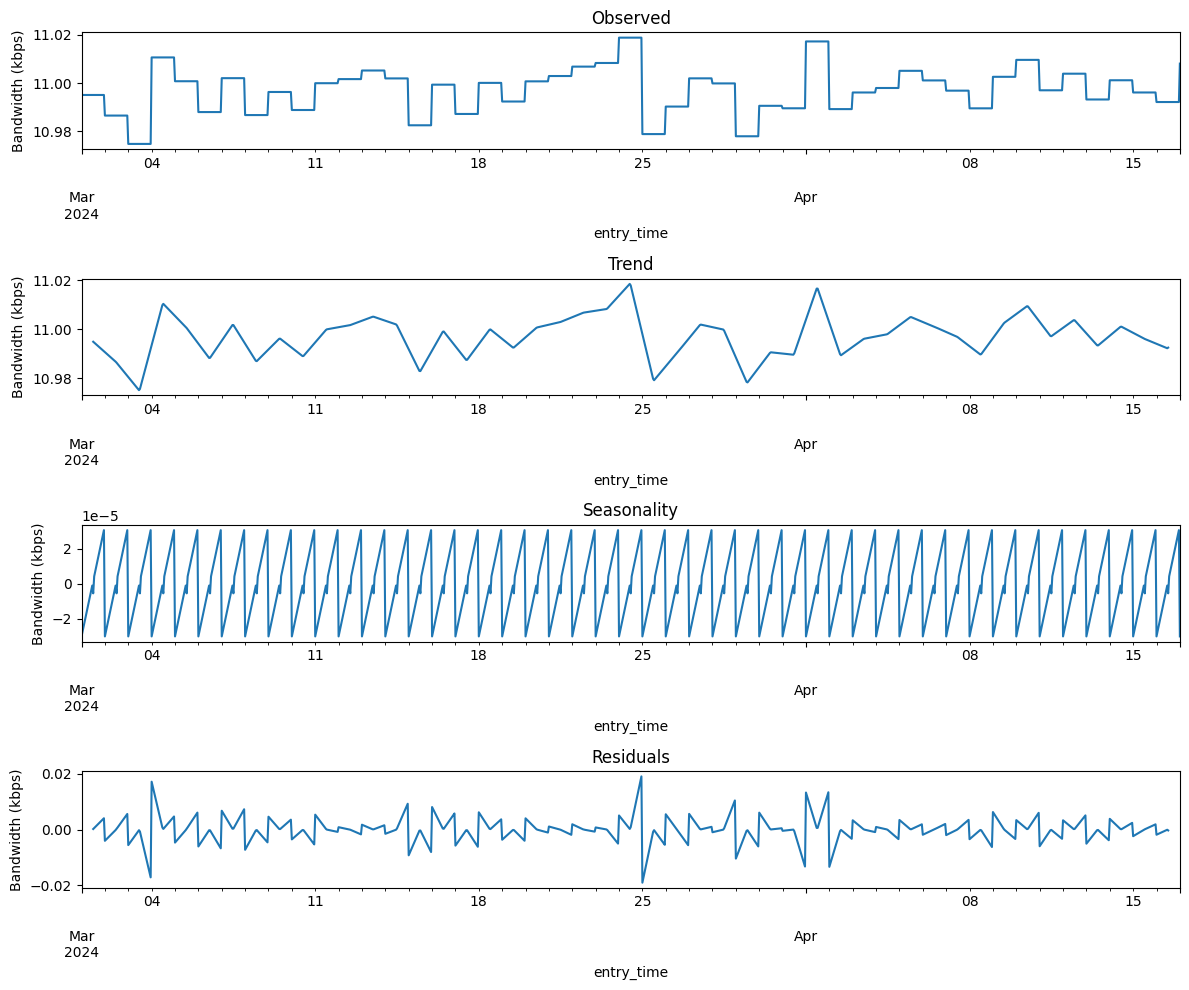


Melatih model SARIMAX untuk prediksi bandwidth...

Melatih model untuk tx_kbps...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


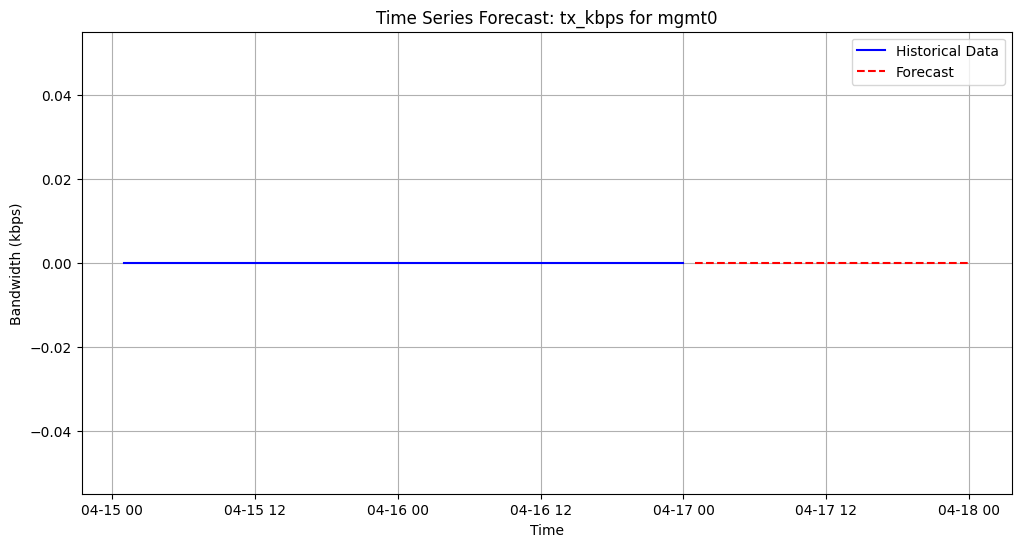

Training RMSE untuk tx_kbps: 0.00 kbps

Melatih model untuk rx_kbps...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


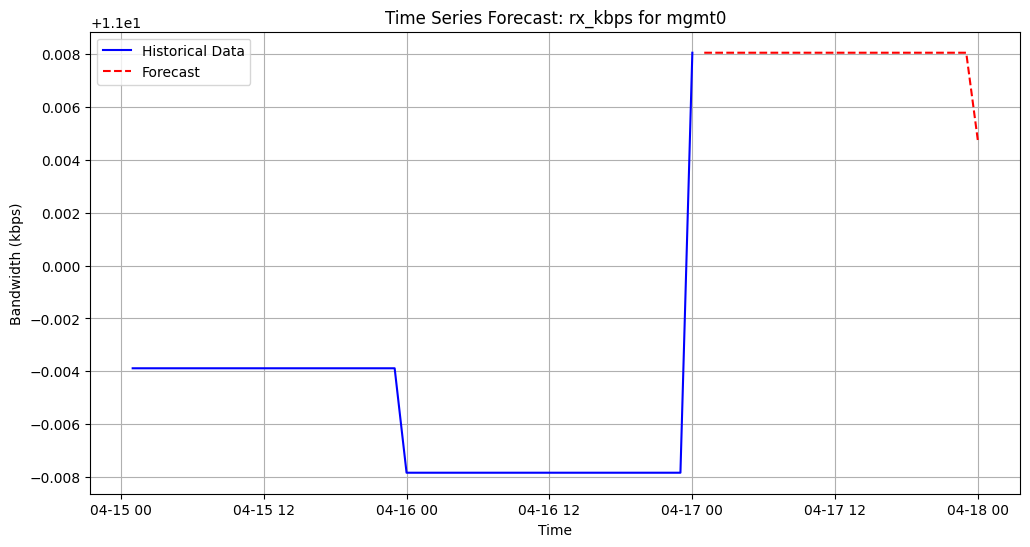

Training RMSE untuk rx_kbps: 0.16 kbps

=== STEP 3: ANOMALY DETECTION ===

=== Threshold-based Anomaly Detection ===
Menghitung threshold untuk deteksi anomali...

Threshold untuk 10ge0/0 - tx_kbps:
  Minor: 1153.61 kbps
  Major: 1175.92 kbps
  Critical: 1335.23 kbps

Threshold untuk 10ge0/0 - rx_kbps:
  Minor: 1.00 kbps
  Major: 1.00 kbps
  Critical: 1.00 kbps

Threshold untuk 10ge0/0 - total_kbps:
  Minor: 1154.61 kbps
  Major: 1176.92 kbps
  Critical: 1336.23 kbps

Threshold untuk ge2/0 - tx_kbps:
  Minor: 1217.17 kbps
  Major: 1275.83 kbps
  Critical: 1363.06 kbps

Threshold untuk ge2/0 - rx_kbps:
  Minor: 6864.43 kbps
  Major: 7111.23 kbps
  Critical: 7353.84 kbps

Threshold untuk ge2/0 - total_kbps:
  Minor: 7993.24 kbps
  Major: 8161.13 kbps
  Critical: 8554.77 kbps

Threshold untuk ge2/1 - tx_kbps:
  Minor: 1466.74 kbps
  Major: 1575.04 kbps
  Critical: 1726.19 kbps

Threshold untuk ge2/1 - rx_kbps:
  Minor: 7027.61 kbps
  Major: 7341.37 kbps
  Critical: 7646.04 kbps

Threshold

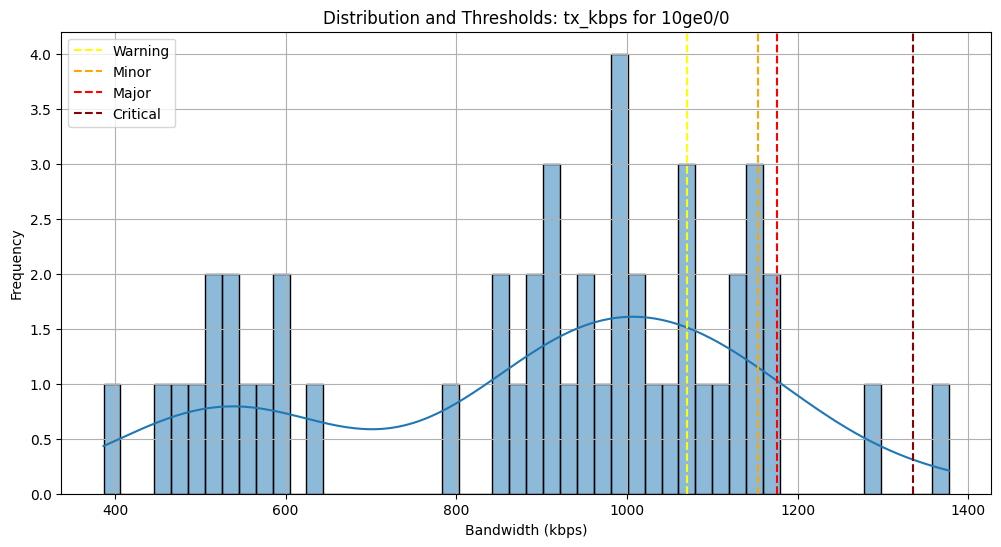

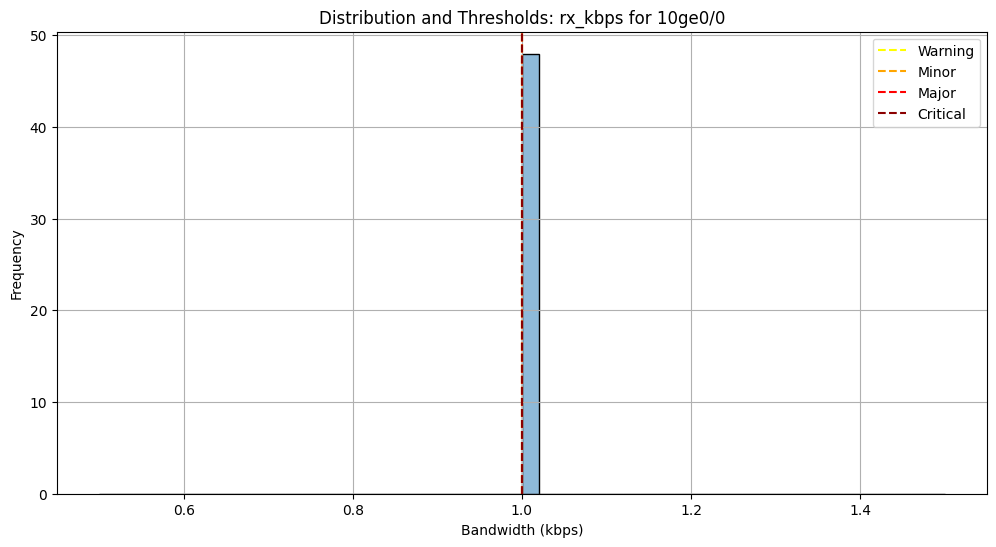

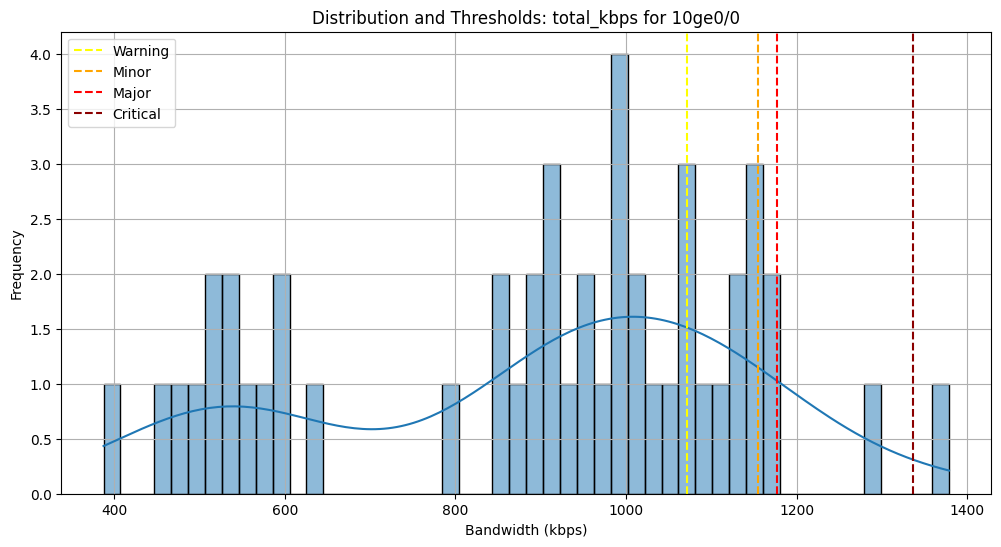

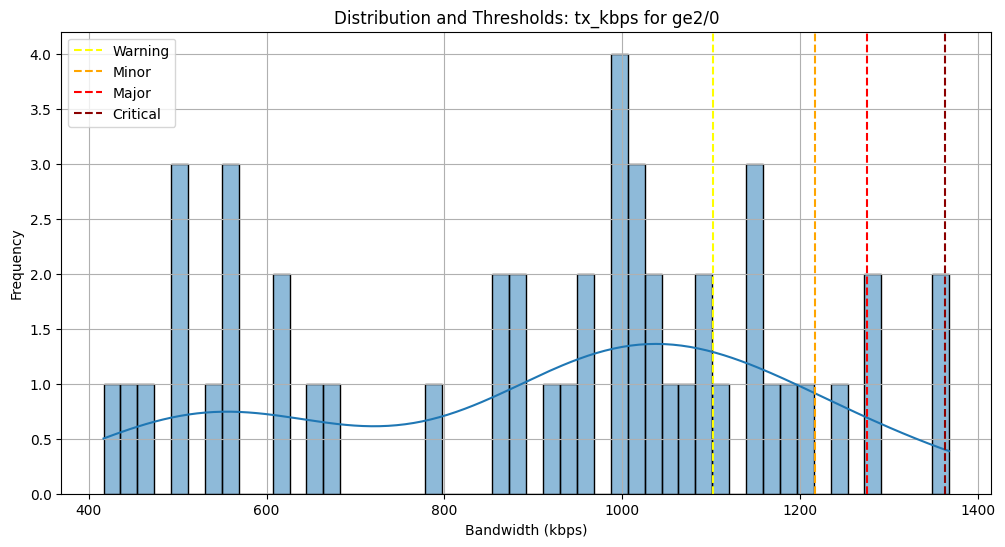

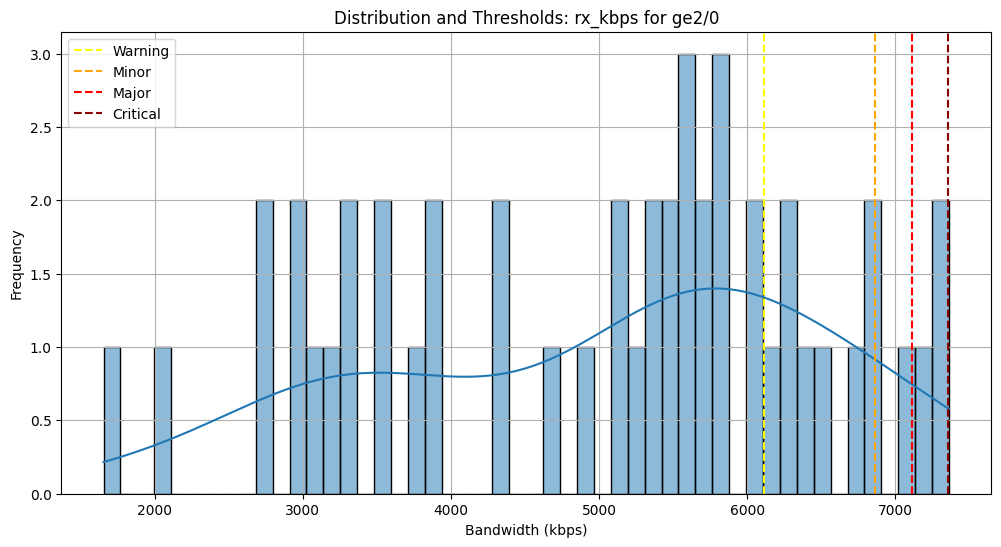

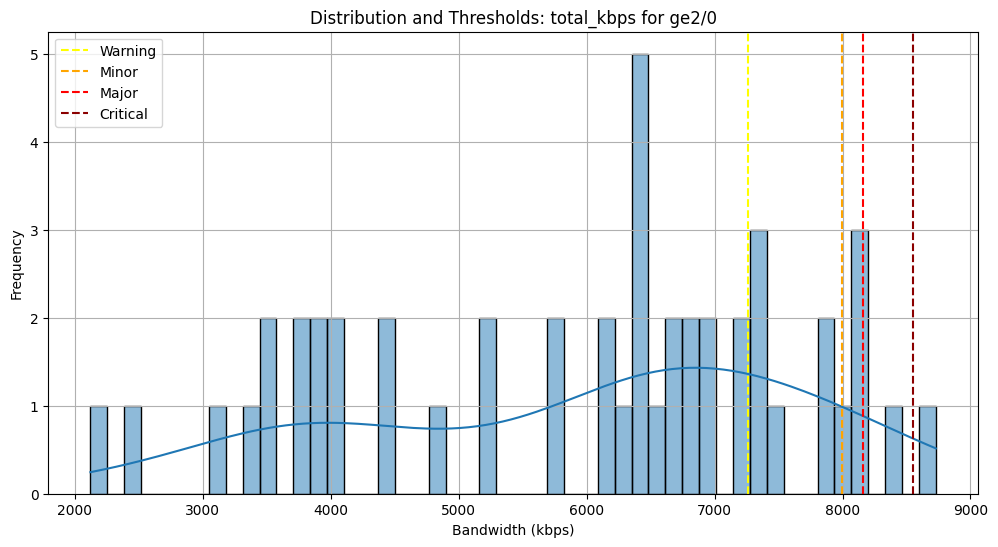

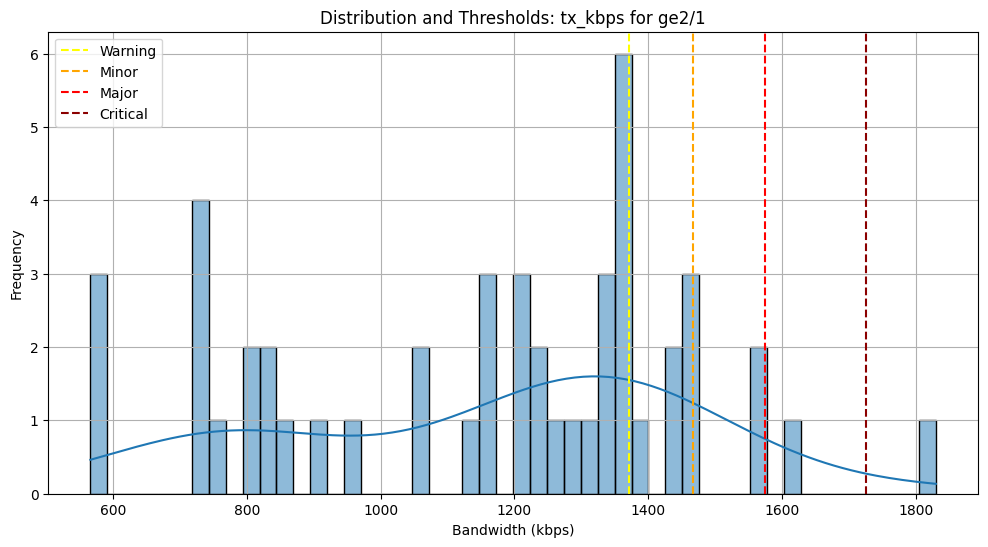

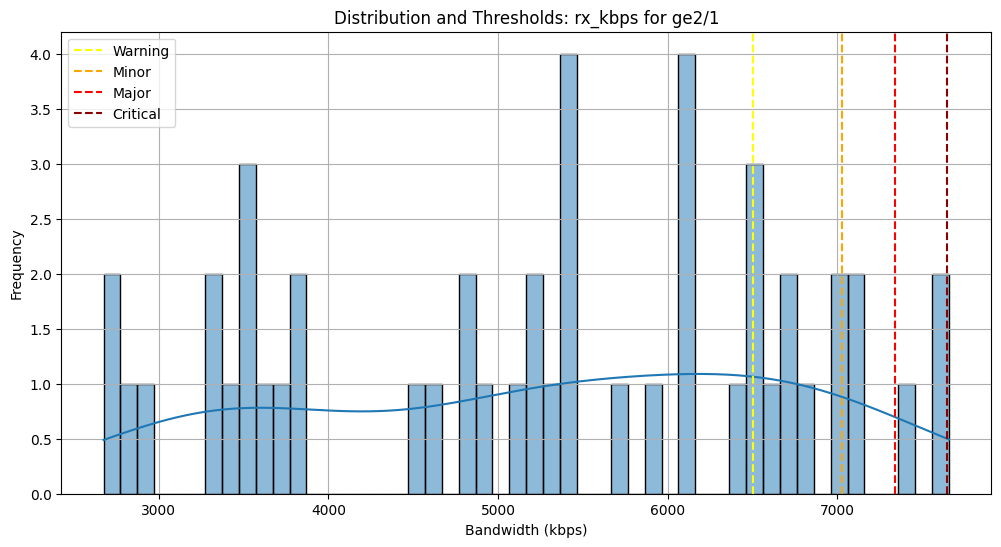

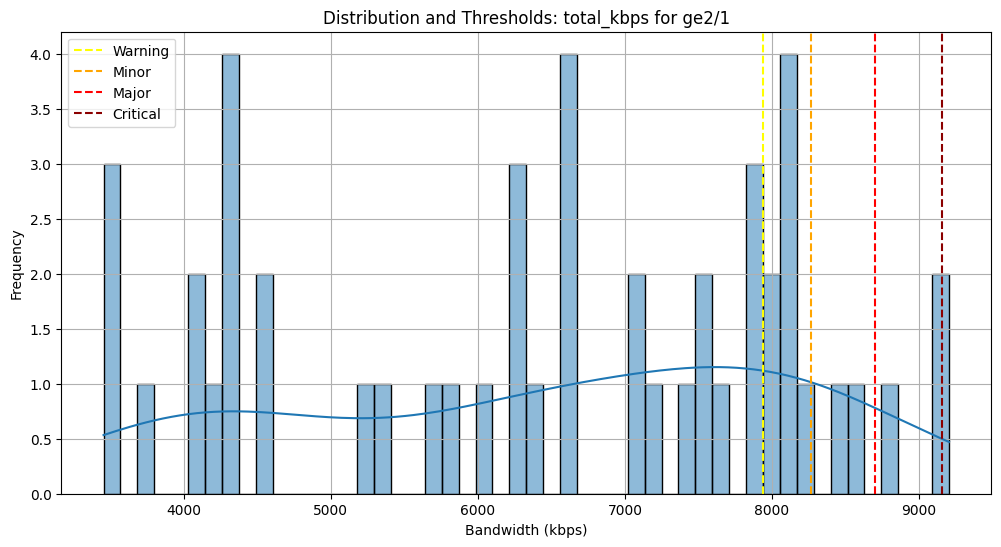

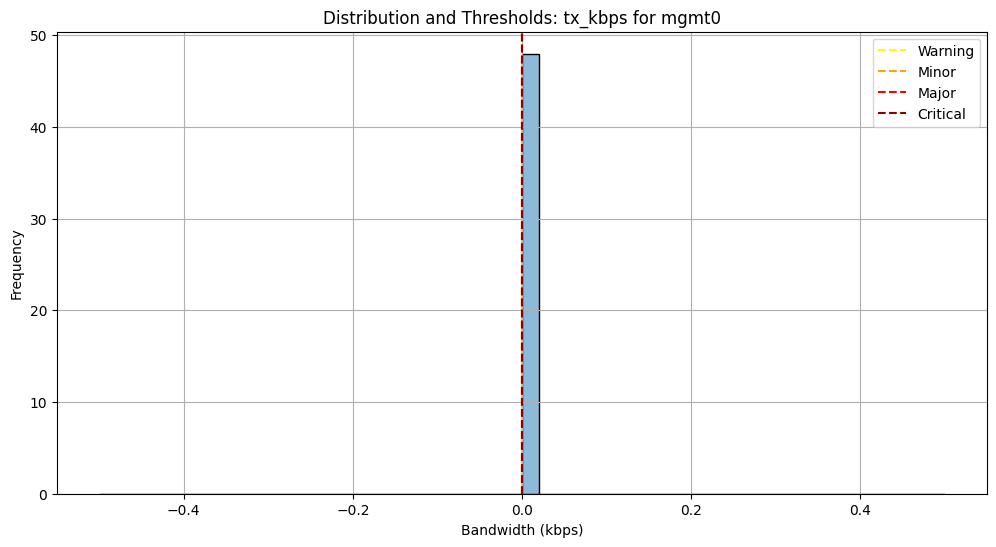

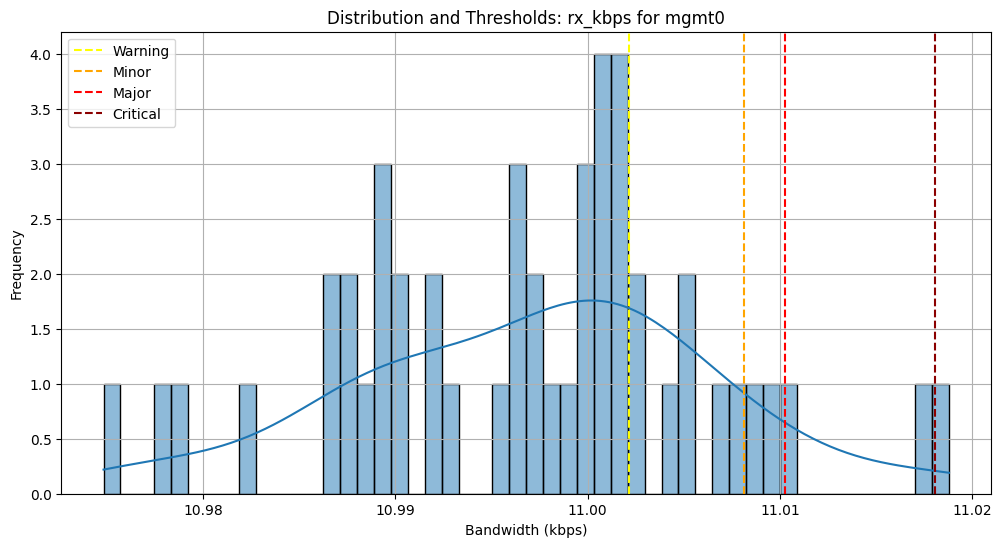

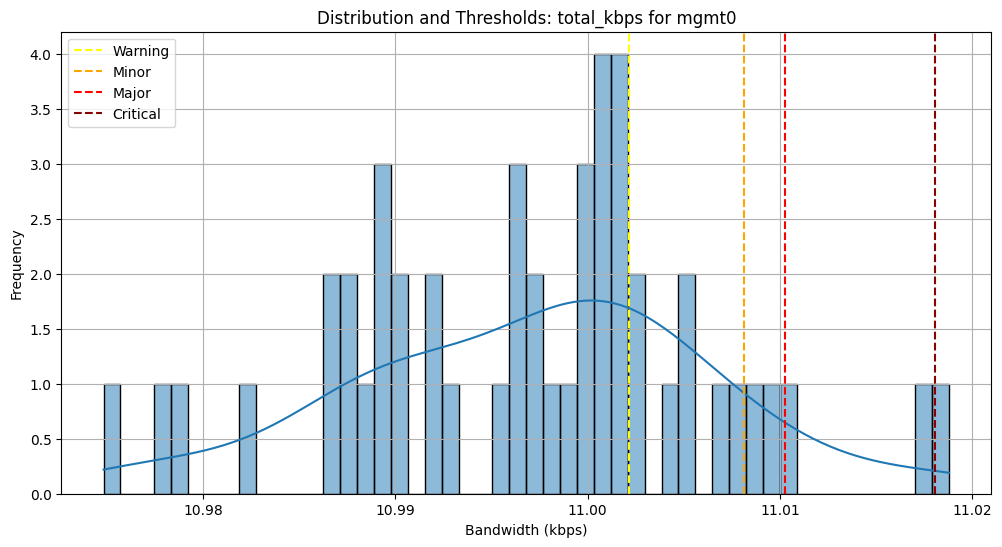


Mendeteksi anomali...

Ringkasan Anomali yang Terdeteksi:
Total anomali: 120
interface  bandwidth_type  anomaly_level
10ge0/0    total_kbps      critical         1
                           major            2
                           minor            2
                           warning          7
           tx_kbps         critical         1
                           major            2
                           minor            2
                           warning          7
ge2/0      rx_kbps         critical         1
                           major            2
                           minor            2
                           warning          7
           total_kbps      critical         1
                           major            2
                           minor            2
                           warning          7
           tx_kbps         critical         1
                           major            2
                           minor            2
       

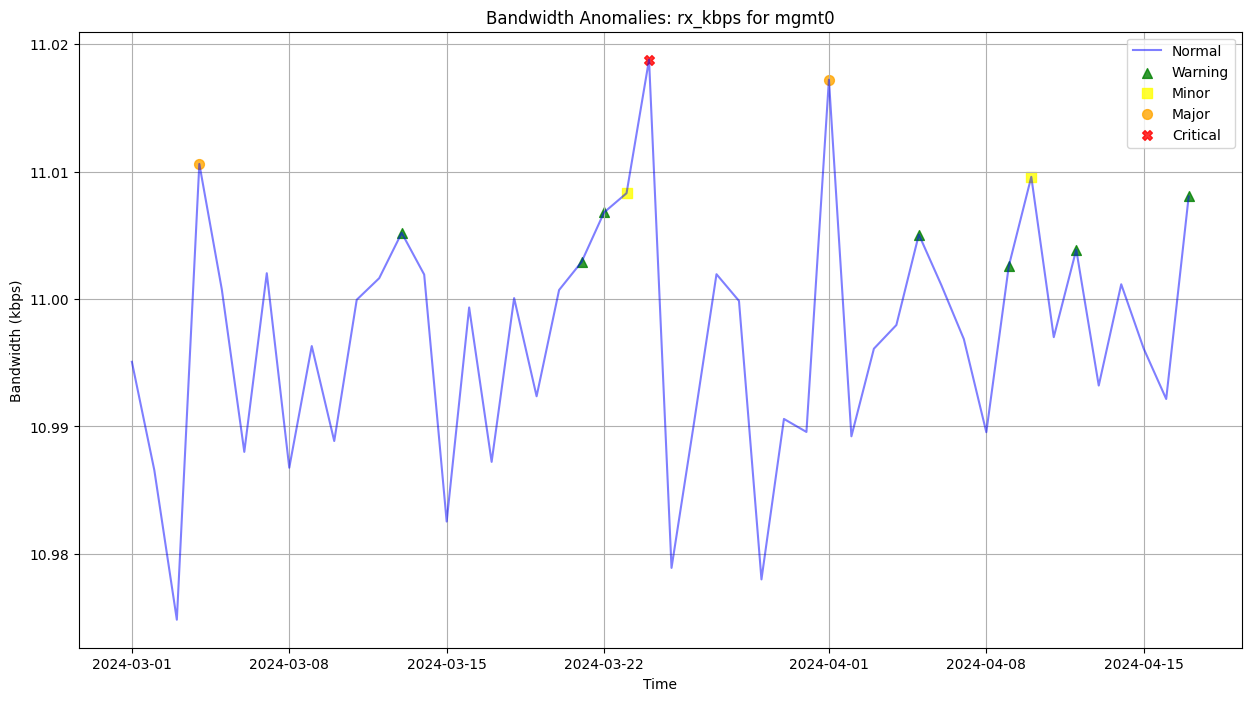

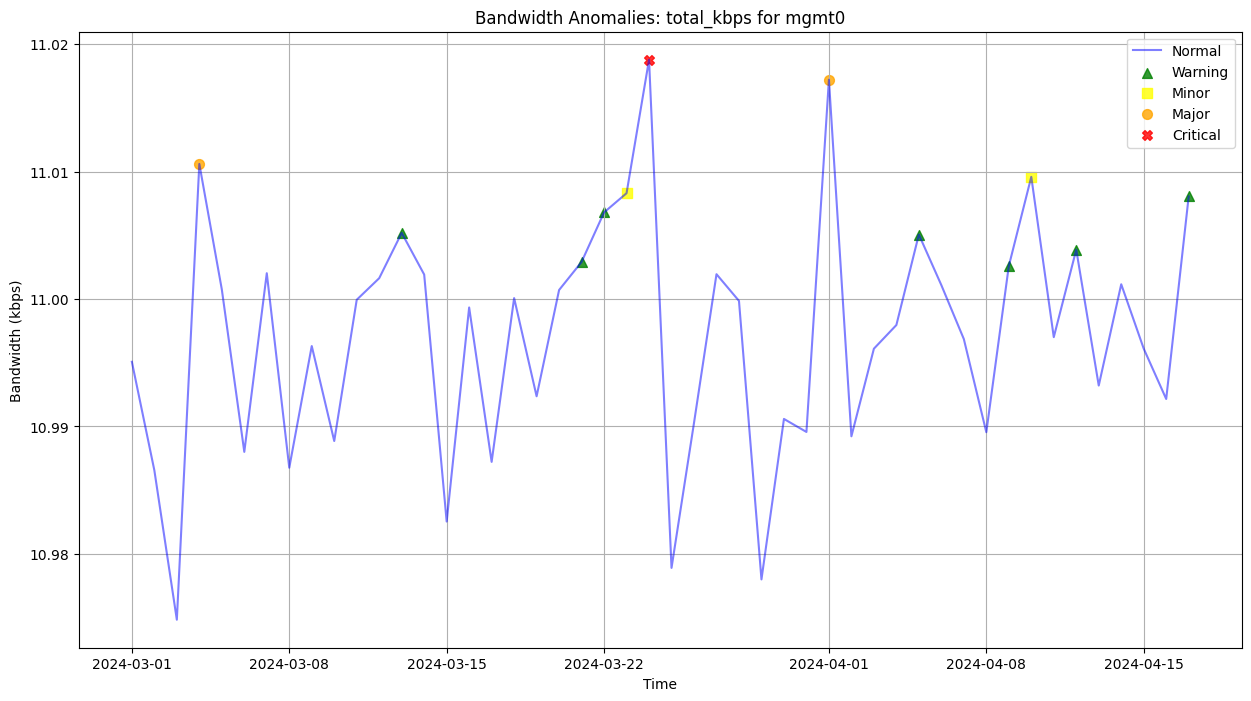

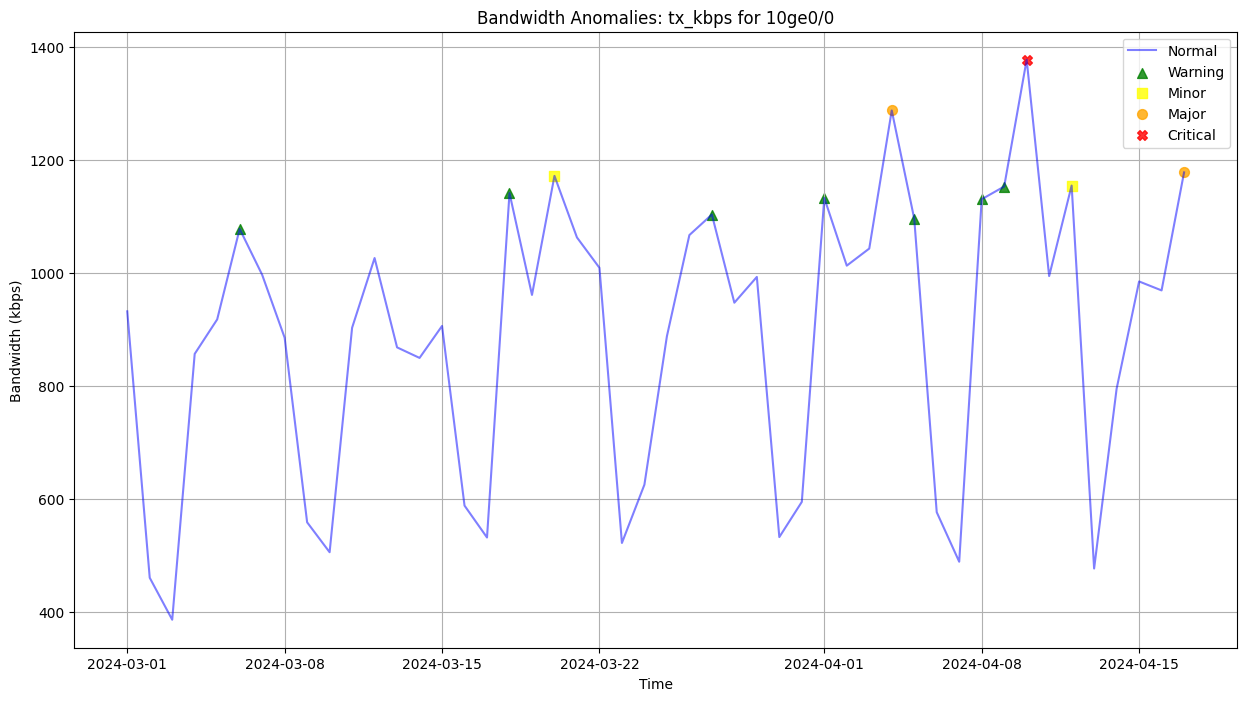

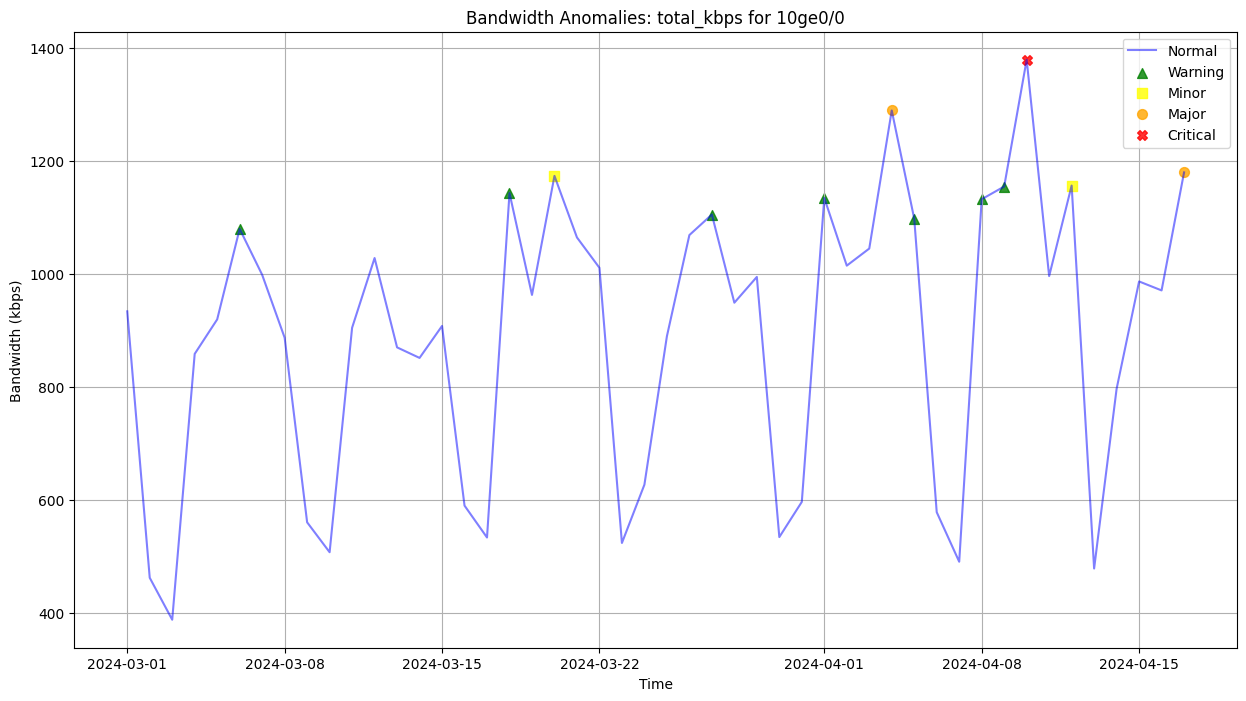

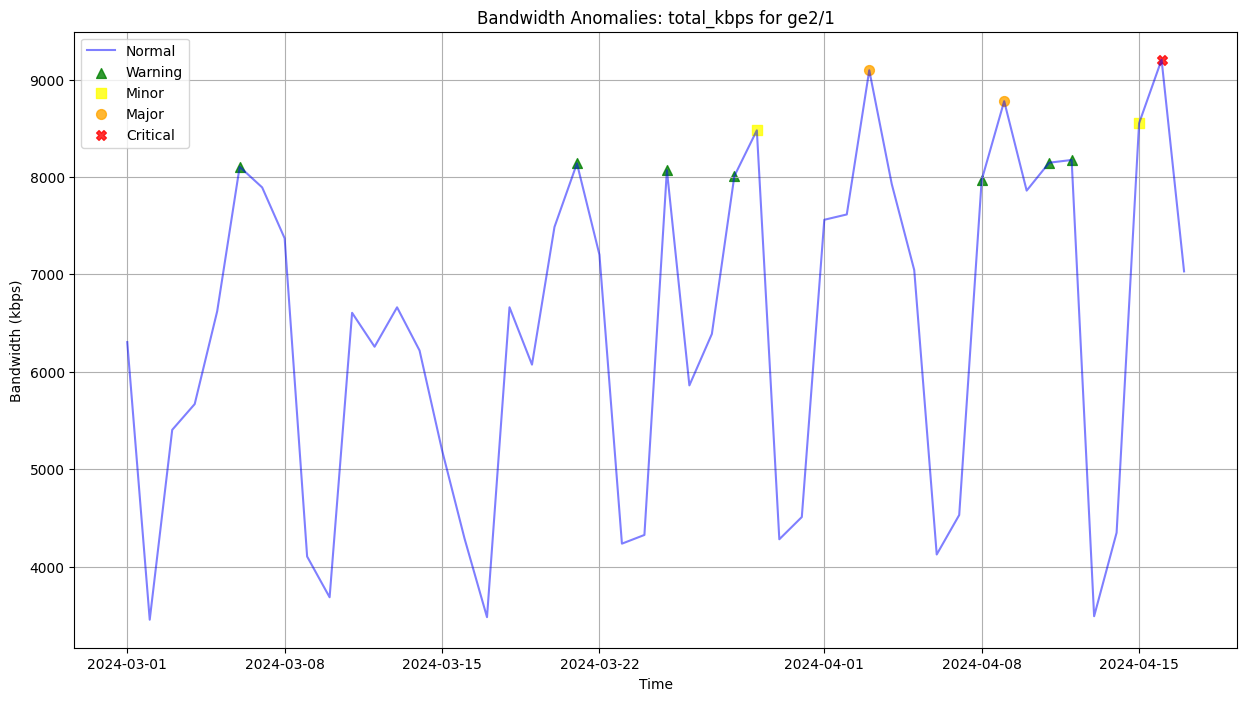

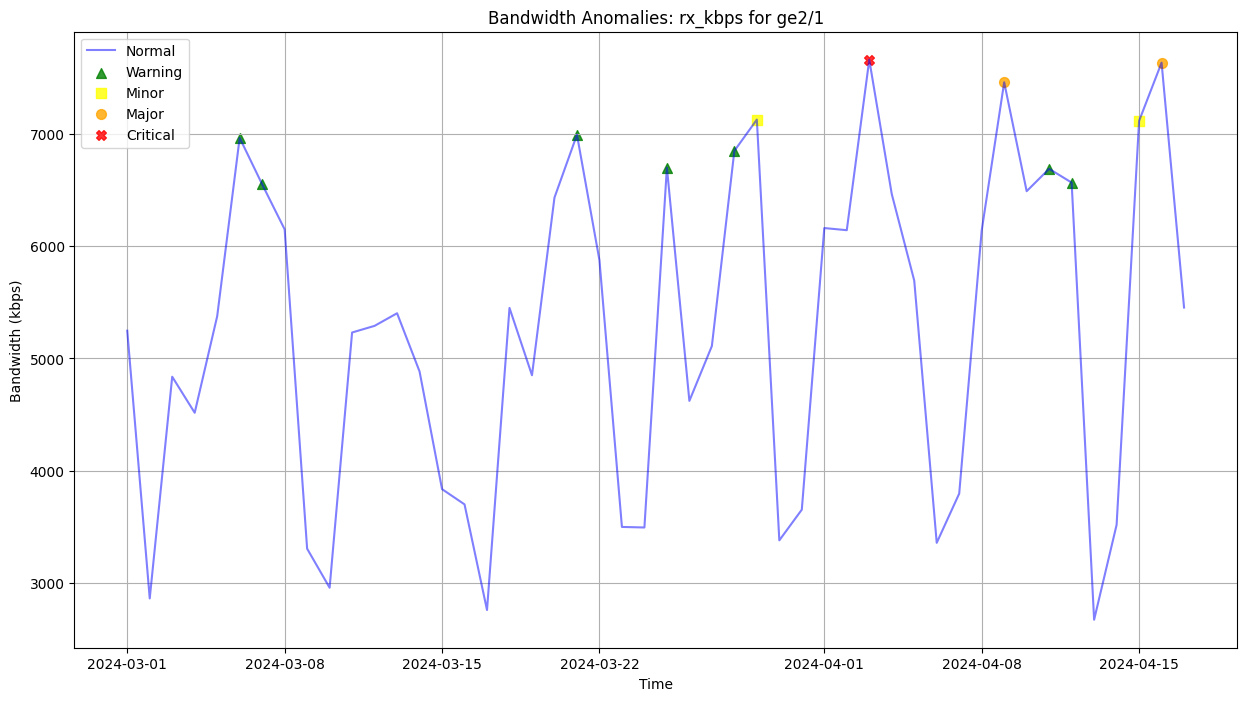

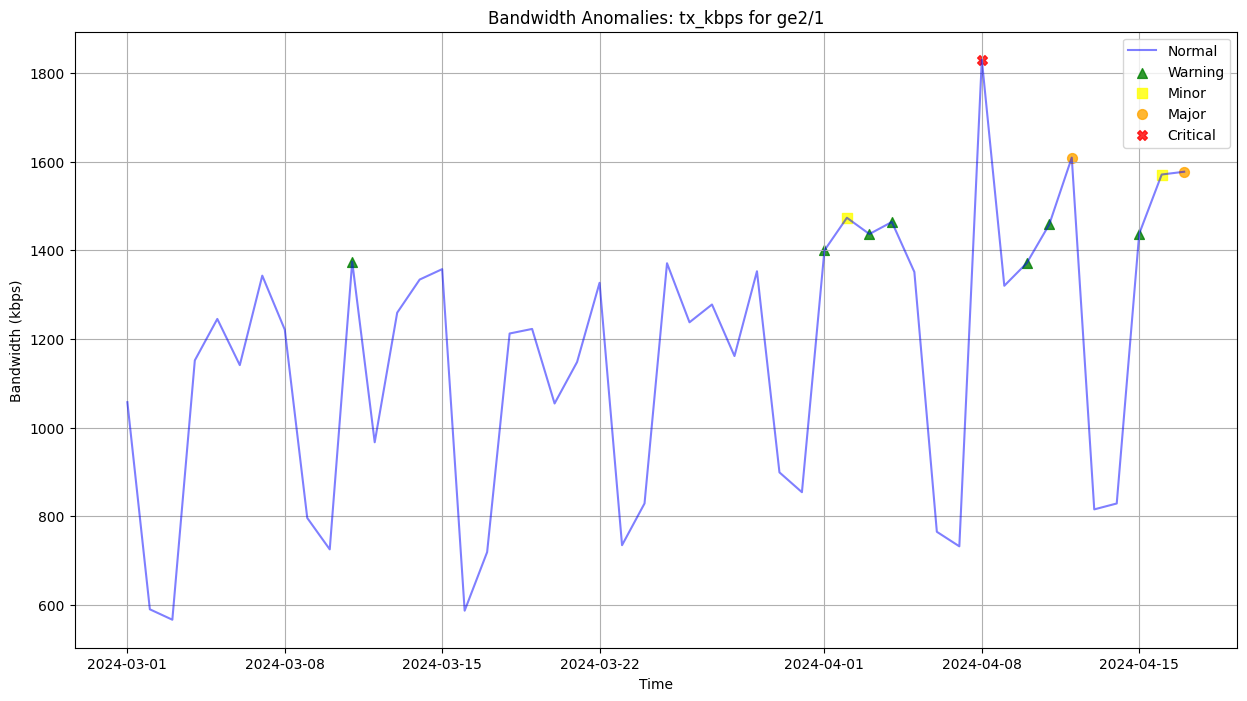

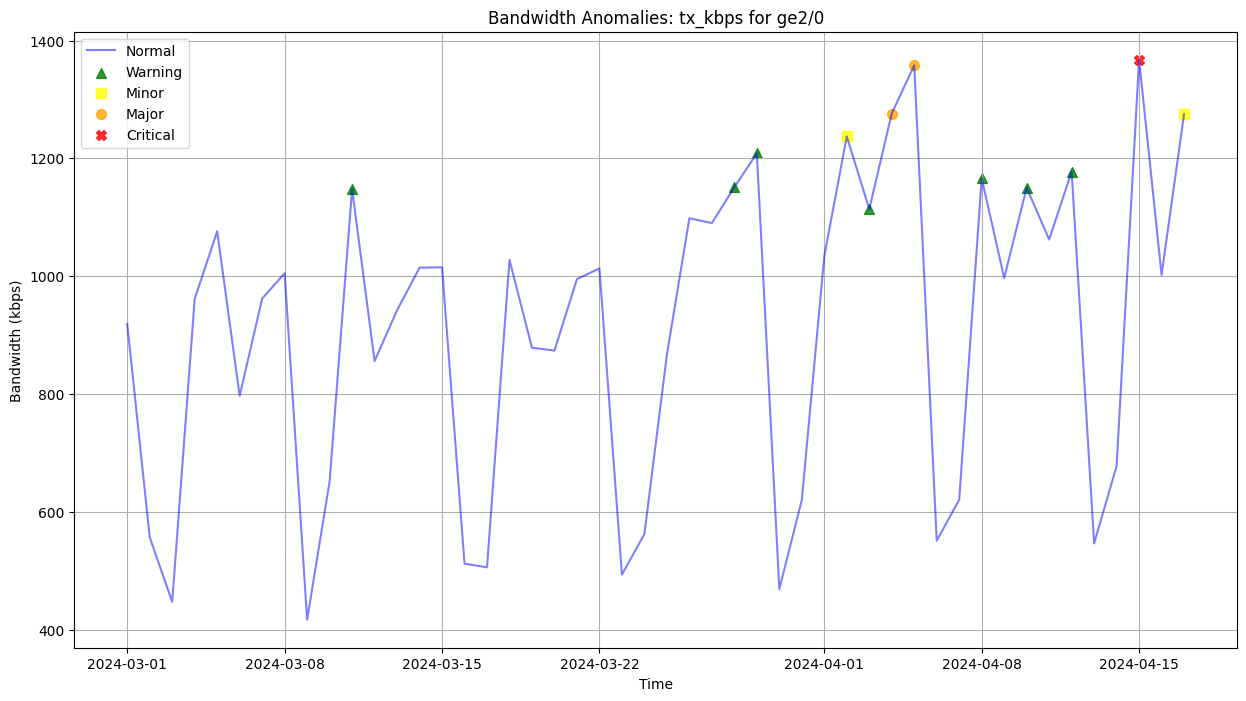

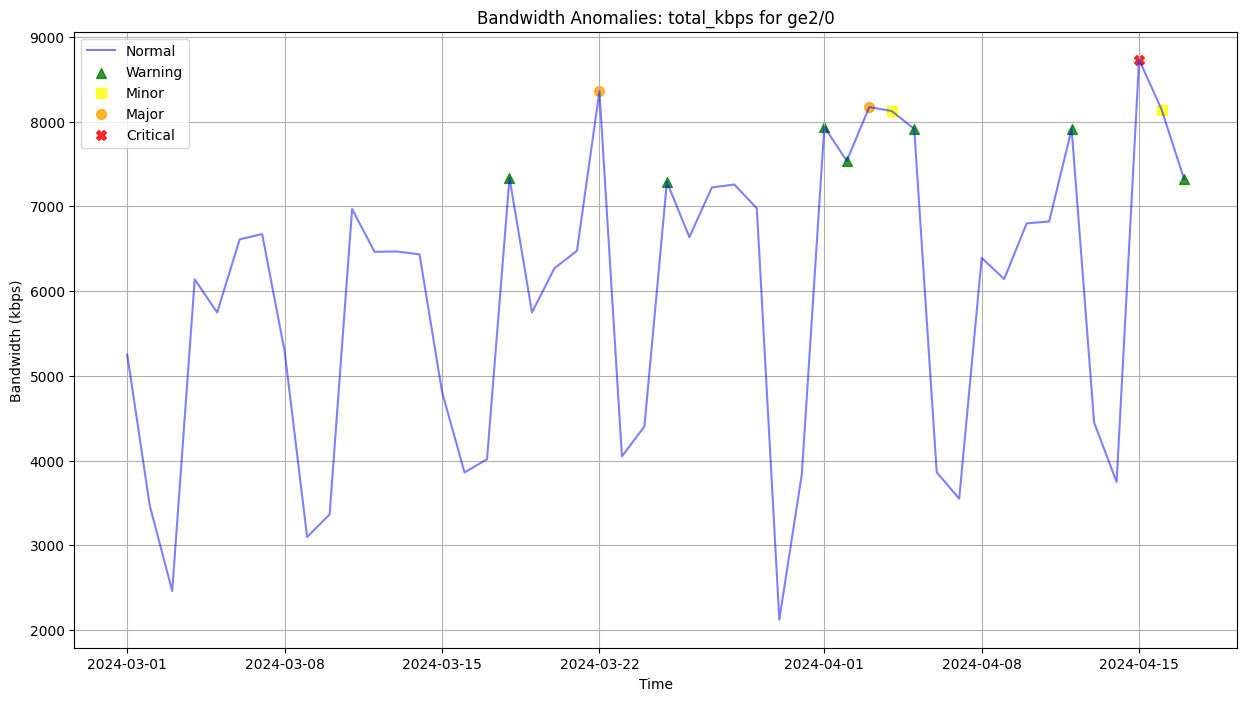

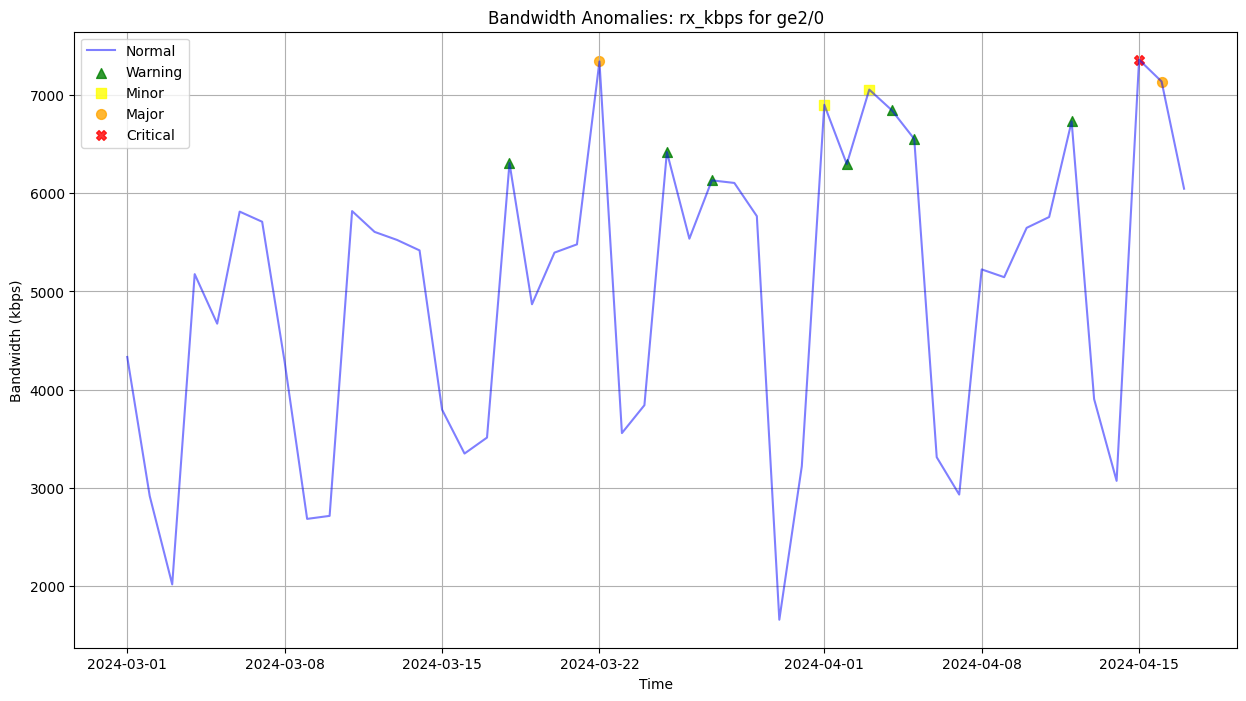


=== STEP 4: BANDWIDTH OPTIMIZATION ===

=== Rule-based Bandwidth Optimization ===


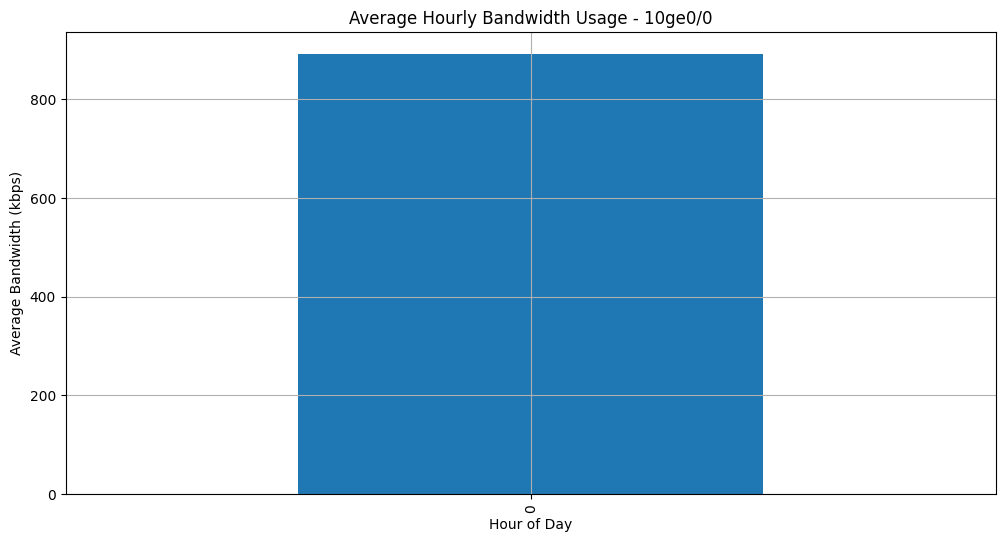

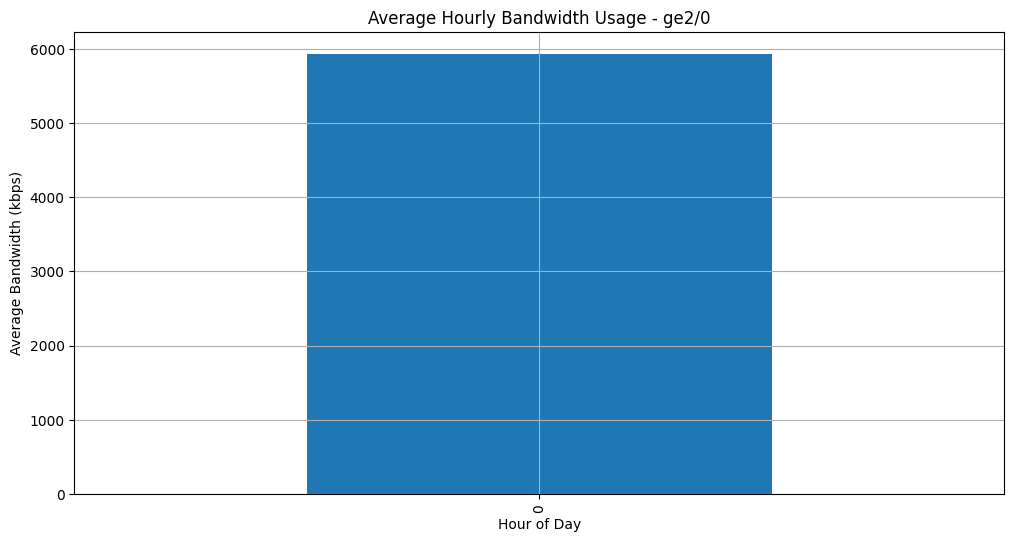

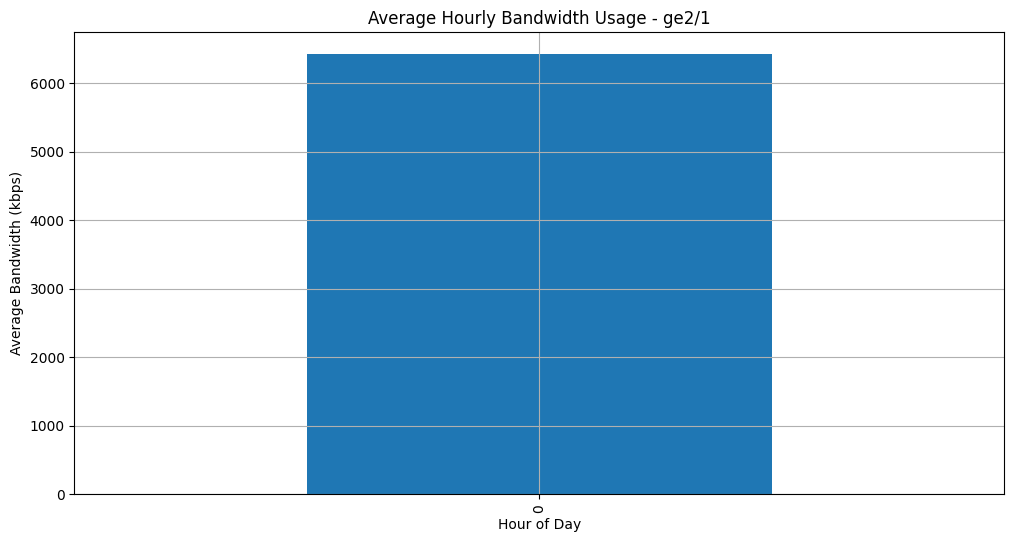

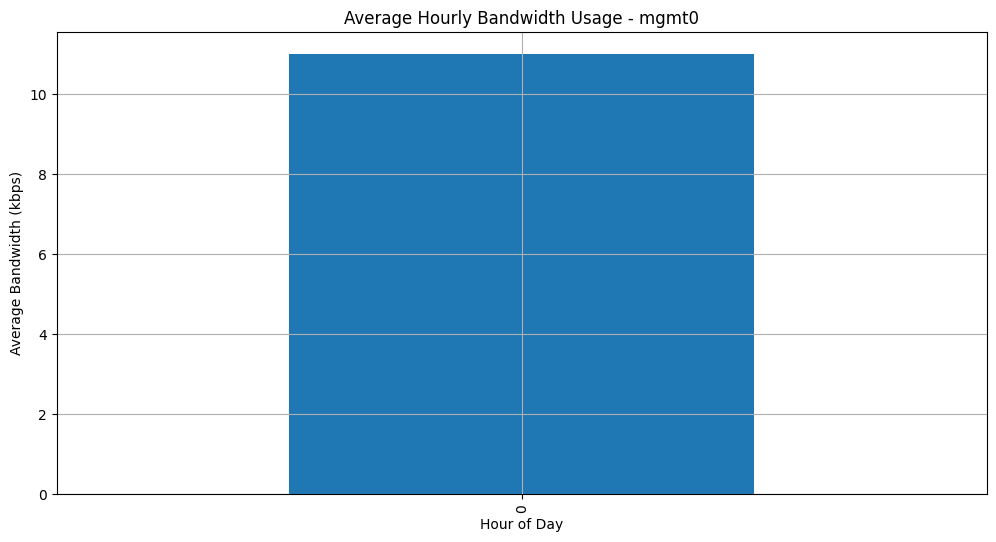


Optimasi bandwidth untuk 10ge0/0:
Level penggunaan saat ini: LOW (11.79%)
Kapasitas total: 10000 kbps
Penggunaan saat ini: 1179.08 kbps

Rekomendasi alokasi bandwidth:
  High Priority: 3000 kbps (30.0%)
  Medium Priority: 4000 kbps (40.0%)
  Low Priority: 3000 kbps (30.0%)


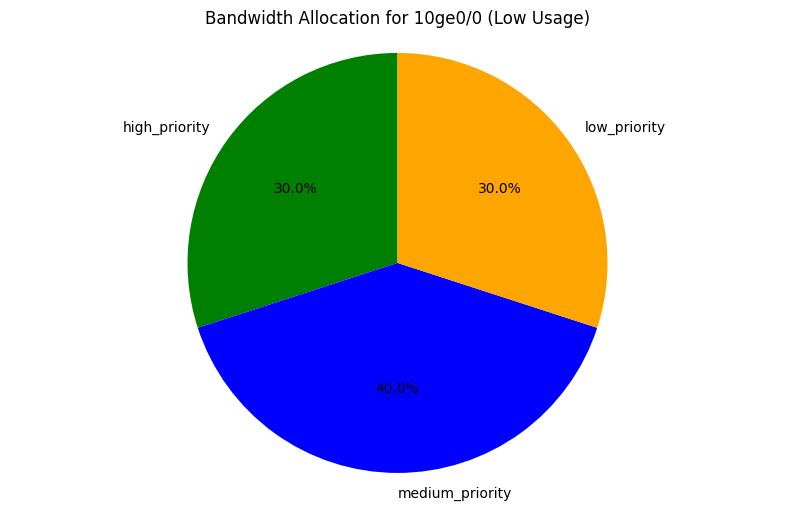


Rekomendasi waktu untuk aktivitas high-bandwidth:
  Jam optimal: 00:00
  Jam dengan traffic terendah: 00:00
  Jam dengan traffic tertinggi (hindari): 00:00

Optimasi bandwidth untuk ge2/0:
Level penggunaan saat ini: HIGH (73.23%)
Kapasitas total: 10000 kbps
Penggunaan saat ini: 7322.65 kbps

Rekomendasi alokasi bandwidth:
  High Priority: 5000 kbps (50.0%)
  Medium Priority: 3500 kbps (35.0%)
  Low Priority: 1500 kbps (15.0%)


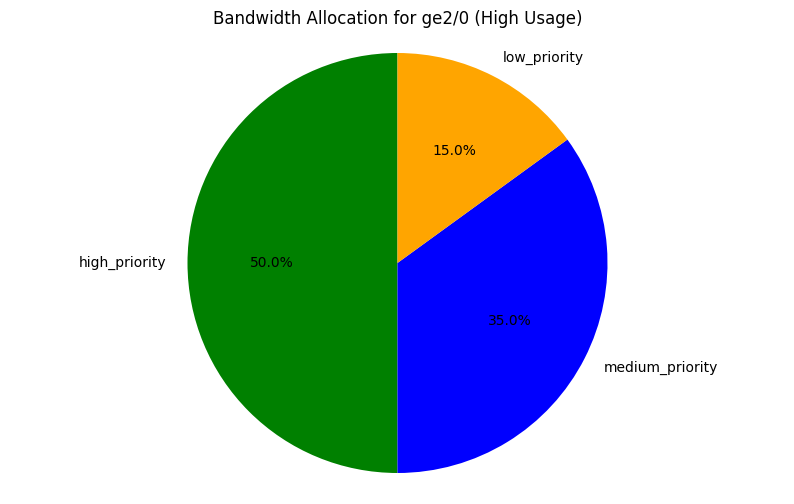


Rekomendasi waktu untuk aktivitas high-bandwidth:
  Jam optimal: 00:00
  Jam dengan traffic terendah: 00:00
  Jam dengan traffic tertinggi (hindari): 00:00

Optimasi bandwidth untuk ge2/1:
Level penggunaan saat ini: HIGH (70.30%)
Kapasitas total: 10000 kbps
Penggunaan saat ini: 7030.31 kbps

Rekomendasi alokasi bandwidth:
  High Priority: 5000 kbps (50.0%)
  Medium Priority: 3500 kbps (35.0%)
  Low Priority: 1500 kbps (15.0%)


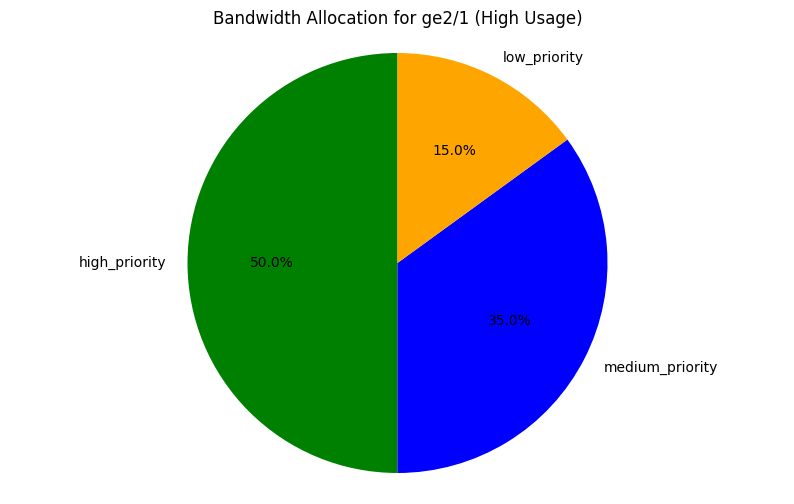


Rekomendasi waktu untuk aktivitas high-bandwidth:
  Jam optimal: 00:00
  Jam dengan traffic terendah: 00:00
  Jam dengan traffic tertinggi (hindari): 00:00

Optimasi bandwidth untuk mgmt0:
Level penggunaan saat ini: LOW (0.11%)
Kapasitas total: 10000 kbps
Penggunaan saat ini: 11.01 kbps

Rekomendasi alokasi bandwidth:
  High Priority: 3000 kbps (30.0%)
  Medium Priority: 4000 kbps (40.0%)
  Low Priority: 3000 kbps (30.0%)


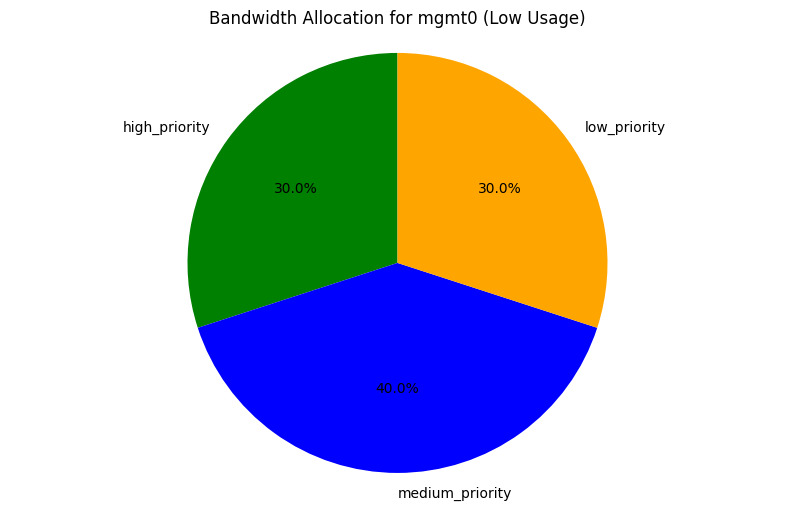


Rekomendasi waktu untuk aktivitas high-bandwidth:
  Jam optimal: 00:00
  Jam dengan traffic terendah: 00:00
  Jam dengan traffic tertinggi (hindari): 00:00

=== STEP 5: MODEL EVALUATION ===

=== Comprehensive Model Evaluation ===

Evaluating TX Bandwidth Models:

Evaluating tx_RandomForest...



Detailed Results for tx_RandomForest:

Regression Metrics:
  Training R2: 0.9785
  Testing R2: 0.9246
  Training RMSE: 71.7115
  Testing RMSE: 151.5332
  Training MAE: 37.7026
  Testing MAE: 104.6249
  Training Relative Accuracy: 96.37%
  Testing Relative Accuracy: 91.16%

Cross-Validation Results:
  Mean CV Score: 0.9399 (+/- 0.0265)

Imbalanced Data Metrics:
  Precision: 0.9286
  Recall: 0.7222
  F1-Score: 0.8125

Model Status: Good Fit


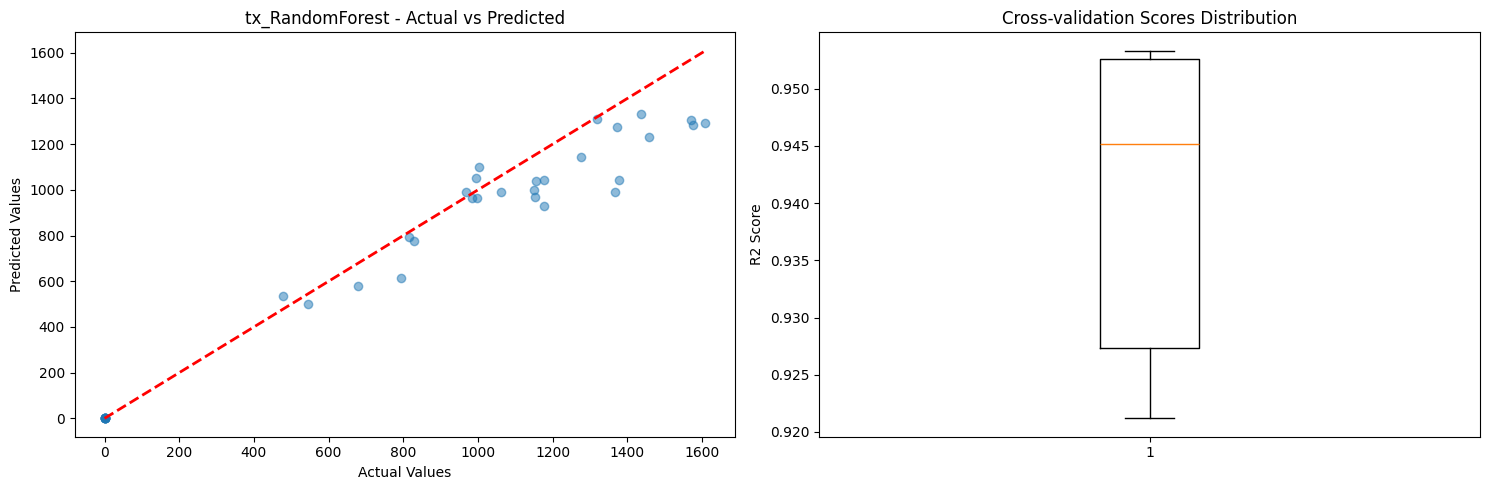


Evaluating tx_XGBoost...



Detailed Results for tx_XGBoost:

Regression Metrics:
  Training R2: 0.9840
  Testing R2: 0.9195
  Training RMSE: 61.9185
  Testing RMSE: 156.5169
  Training MAE: 25.3512
  Testing MAE: 112.9323
  Training Relative Accuracy: -111634263.96%
  Testing Relative Accuracy: -111634271.27%

Cross-Validation Results:
  Mean CV Score: 0.9330 (+/- 0.0252)

Imbalanced Data Metrics:
  Precision: 0.8333
  Recall: 0.8333
  F1-Score: 0.8333

Model Status: Good Fit


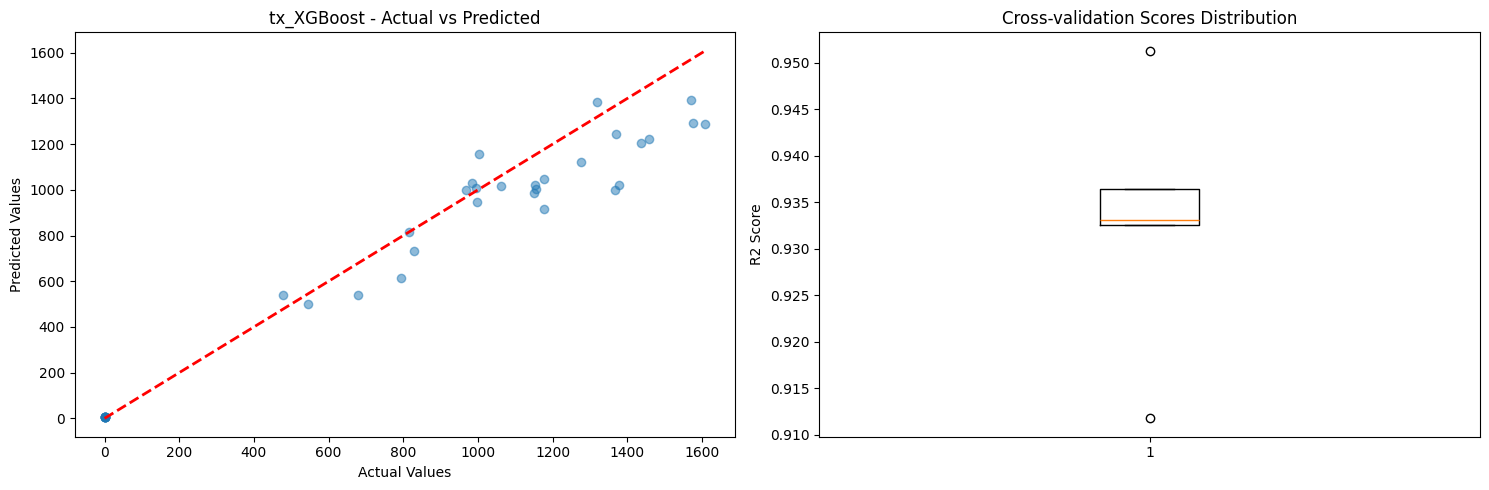


Evaluating tx_LightGBM...

Detailed Results for tx_LightGBM:

Regression Metrics:
  Training R2: 0.9588
  Testing R2: 0.9137
  Training RMSE: 99.2850
  Testing RMSE: 162.1195
  Training MAE: 65.1203
  Testing MAE: 115.4721
  Training Relative Accuracy: -164818599.57%
  Testing Relative Accuracy: -176162400.01%

Cross-Validation Results:
  Mean CV Score: 0.6409 (+/- 0.7085)

Imbalanced Data Metrics:
  Precision: 0.8571
  Recall: 0.6667
  F1-Score: 0.7500

Model Status: Good Fit


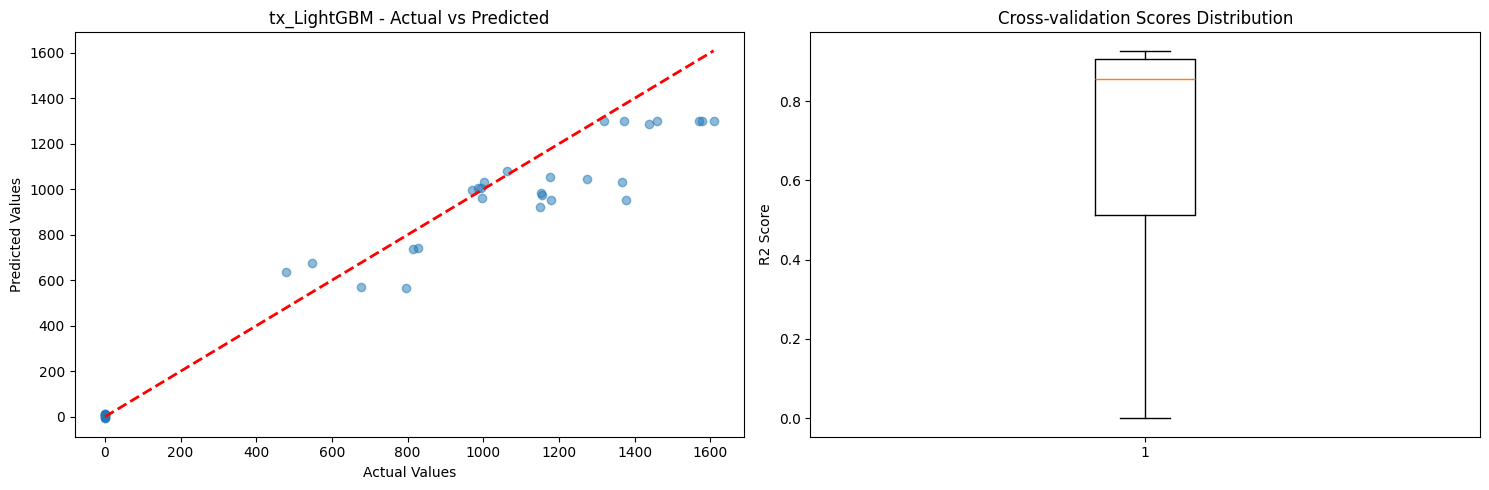


Evaluating RX Bandwidth Models:

Evaluating rx_RandomForest...



Detailed Results for rx_RandomForest:

Regression Metrics:
  Training R2: 0.9871
  Testing R2: 0.9437
  Training RMSE: 310.6365
  Testing RMSE: 732.7216
  Training MAE: 163.4369
  Testing MAE: 418.8629
  Training Relative Accuracy: 96.65%
  Testing Relative Accuracy: 92.89%

Cross-Validation Results:
  Mean CV Score: 0.9388 (+/- 0.0683)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


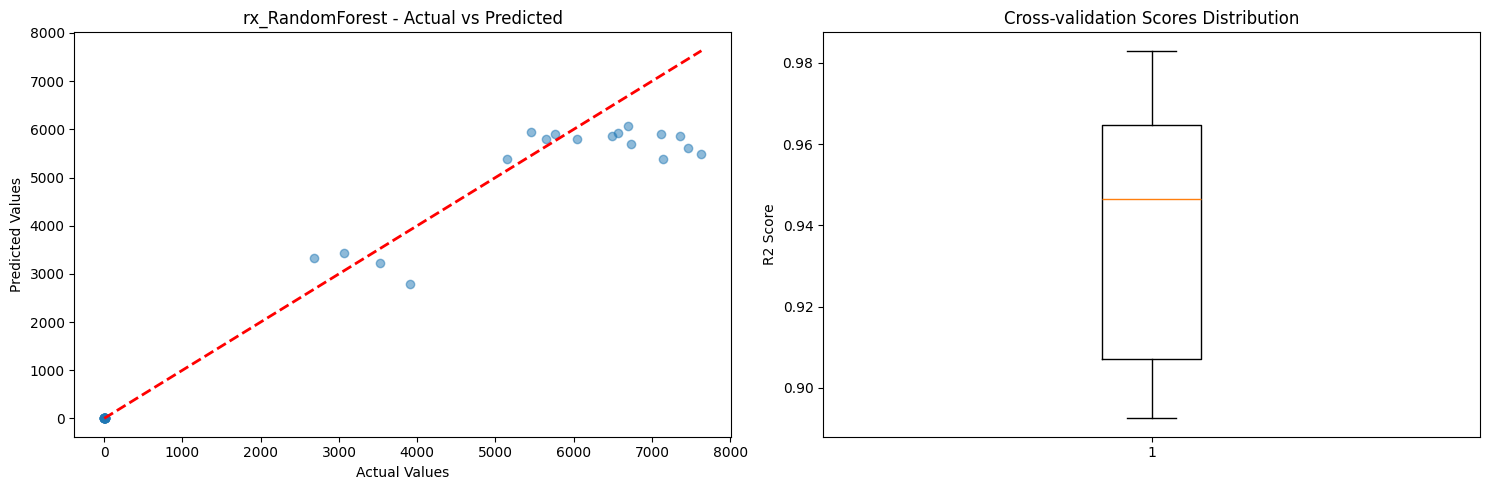


Evaluating rx_XGBoost...



Detailed Results for rx_XGBoost:

Regression Metrics:
  Training R2: 0.9907
  Testing R2: 0.9379
  Training RMSE: 263.7145
  Testing RMSE: 770.0005
  Training MAE: 96.8401
  Testing MAE: 440.9590
  Training Relative Accuracy: -340.43%
  Testing Relative Accuracy: -345.81%

Cross-Validation Results:
  Mean CV Score: 0.9255 (+/- 0.0755)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


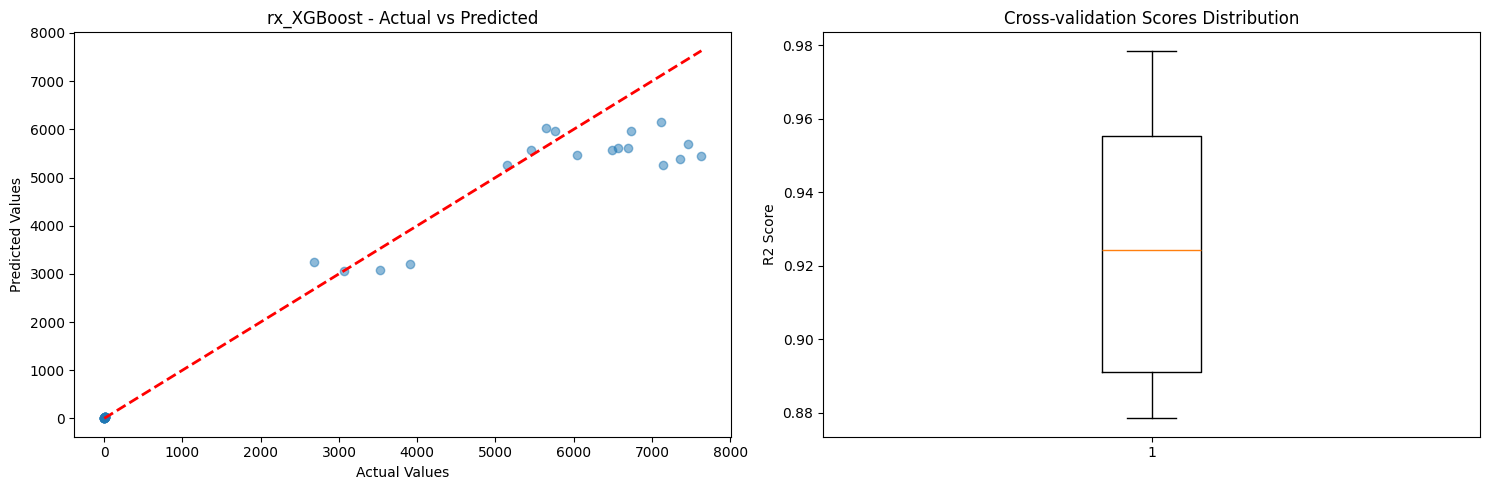


Evaluating rx_LightGBM...

Detailed Results for rx_LightGBM:

Regression Metrics:
  Training R2: 0.9617
  Testing R2: 0.9403
  Training RMSE: 534.9559
  Testing RMSE: 754.6219
  Training MAE: 327.9449
  Testing MAE: 471.3962
  Training Relative Accuracy: -2492.53%
  Testing Relative Accuracy: -2229.96%

Cross-Validation Results:
  Mean CV Score: 0.7268 (+/- 0.7350)

Imbalanced Data Metrics:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Model Status: Good Fit


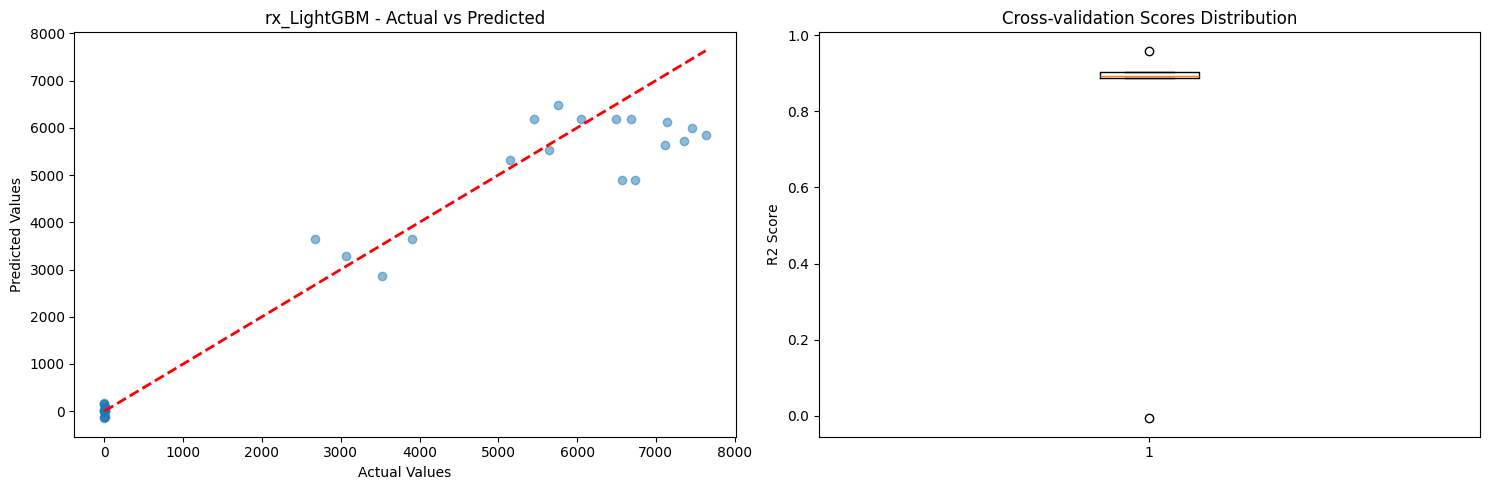


=== BANDWIDTH OPTIMIZATION SUMMARY ===

1. Feature Importance Analysis:
  Top features for tx:
    1. interface_encoded: 0.2579
    2. tx_kbps_rolling3: 0.2416
    3. tx_kbps_lag1: 0.1800
  Top features for rx:
    1. rx_kbps_lag2: 0.4555
    2. rx_kbps_lag1: 0.2189
    3. rx_kbps_rolling3: 0.2154

2. Time Series Analysis:
  Forecasts available for 8 time series

3. Anomaly Detection:
  Total anomalies detected: 120
    Critical: 10
    Major: 20
    Minor: 20

4. Bandwidth Optimization:
  Interface: 10ge0/0
    Usage Level: LOW
    Recommended Allocation:
      High Priority: 3000 kbps
      Medium Priority: 4000 kbps
      Low Priority: 3000 kbps
  Interface: ge2/0
    Usage Level: HIGH
    Recommended Allocation:
      High Priority: 5000 kbps
      Medium Priority: 3500 kbps
      Low Priority: 1500 kbps
  Interface: ge2/1
    Usage Level: HIGH
    Recommended Allocation:
      High Priority: 5000 kbps
      Medium Priority: 3500 kbps
      Low Priority: 1500 kbps
  Interface: mgm

Saved time series model: models/10ge0_0_tx_kbps_sarimax_ts_model.pkl


Saved time series model: models/10ge0_0_rx_kbps_sarimax_ts_model.pkl


Saved time series model: models/ge2_0_tx_kbps_sarimax_ts_model.pkl


Saved time series model: models/ge2_0_rx_kbps_sarimax_ts_model.pkl


Saved time series model: models/ge2_1_tx_kbps_sarimax_ts_model.pkl


Saved time series model: models/ge2_1_rx_kbps_sarimax_ts_model.pkl


Saved time series model: models/mgmt0_tx_kbps_sarimax_ts_model.pkl


Saved time series model: models/mgmt0_rx_kbps_sarimax_ts_model.pkl
All models saved successfully.

Analysis complete!


In [10]:
class BandwidthAnalyzer:
    def __init__(self):
        self.datasets = {}
        self.models = {}
        self.label_encoder = LabelEncoder()
        self.accuracy_metrics = {}
        self.scaler = StandardScaler()
        self.interface_capacity = {
            '10ge0/0': 10000,
            'ge2/0': 10000,
            'ge2/1': 10000,
            'mgmt0': 10000
        }

    def load_data(self, file_path):
        """Load data dari file JSON"""
        if os.path.exists(file_path):
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                df = pd.json_normalize(data['data'])
                print(f"Data berhasil dimuat: {len(df)} baris")
                return df
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print(f"File {file_path} tidak ditemukan")
            return None

    def assess_data(self, df):
        """Melakukan penilaian awal pada data"""
        try:
            # Konversi entry_time ke datetime
            if not pd.api.types.is_datetime64_any_dtype(df['entry_time']):
                df['entry_time'] = pd.to_datetime(df['entry_time'], unit='ms')

            # Menambahkan fitur temporal
            df['hour'] = df['entry_time'].dt.hour
            df['day_of_week'] = df['entry_time'].dt.dayofweek
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['month'] = df['entry_time'].dt.month

            print("Data assessment selesai")
            return df
        except Exception as e:
            print(f"Error in data assessment: {e}")
            return None

    def clean_data(self, df):
        """Membersihkan data"""
        try:
            # Hapus duplikasi
            df_cleaned = df.drop_duplicates()

            # Filter interface
            df_cleaned = df_cleaned[df_cleaned['interface'].isin(self.interface_capacity.keys())]

            # Handle outliers dengan IQR
            q1 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.25)
            q3 = df_cleaned[['tx_kbps', 'rx_kbps']].quantile(0.75)
            iqr = q3 - q1
            df_cleaned = df_cleaned[~((df_cleaned[['tx_kbps', 'rx_kbps']] < (q1 - 1.5 * iqr)) |
                                    (df_cleaned[['tx_kbps', 'rx_kbps']] > (q3 + 1.5 * iqr))).any(axis=1)]

            print("Data cleaning selesai")
            return df_cleaned
        except Exception as e:
            print(f"Error in data cleaning: {e}")
            return None

    def feature_engineering(self, df):
        """Melakukan feature engineering pada dataset"""
        try:
            print("\n=== Feature Engineering ===")

            # Total bandwidth
            print("Menambahkan kolom total_kbps...")
            df['total_kbps'] = df['tx_kbps'] + df['rx_kbps']

            # Usage percentage
            print("Menambahkan kolom usage_percentage...")
            df['usage_percentage'] = df.apply(
                lambda row: (row['total_kbps'] / self.interface_capacity.get(row['interface'], 10000)) * 100,
                axis=1
            )

            # Time since last entry
            print("Menambahkan kolom time_since_last_entry...")
            df['time_since_last_entry'] = df.groupby('interface')['entry_time'].diff().dt.total_seconds().fillna(0)

            # Bandwidth change
            print("Menambahkan kolom bandwidth_change...")
            df['bandwidth_change'] = df.groupby('interface')['total_kbps'].diff().fillna(0)

            # Lag & rolling features: hanya memakai nilai dari periode SEBELUMNYA,
            # sehingga model tidak "melihat" nilai tx/rx yang sedang diprediksi (bebas data leakage)
            print("Menambahkan fitur lag dan rolling (historis)...")
            df = df.sort_values(['interface', 'entry_time'])
            df['interface_encoded'] = self.label_encoder.fit_transform(df['interface'])
            for col in ['tx_kbps', 'rx_kbps']:
                grp = df.groupby('interface')[col]
                df[f'{col}_lag1'] = grp.shift(1)
                df[f'{col}_lag2'] = grp.shift(2)
                df[f'{col}_rolling3'] = grp.transform(lambda s: s.shift(1).rolling(3).mean())
            df = df.sort_values(['entry_time', 'interface'])

            print("\nFeature Engineering selesai.")
            print("Kolom yang tersedia:", df.columns.tolist())
            return df

        except Exception as e:
            print(f"Error dalam feature engineering: {e}")
            return None

    def split_data(self, df):
        """Memisahkan data menjadi training dan testing sets"""
        try:
            print("\n=== Splitting Data ===")

            # Catatan: total_kbps, usage_percentage, dan bandwidth_change dihitung dari tx/rx
            # pada waktu yang sama, jadi TIDAK dipakai sebagai fitur (menghindari data leakage)
            features = ['day_of_week', 'is_weekend', 'interface_encoded',
                        'tx_kbps_lag1', 'tx_kbps_lag2', 'tx_kbps_rolling3',
                        'rx_kbps_lag1', 'rx_kbps_lag2', 'rx_kbps_rolling3']
            target = ['tx_kbps', 'rx_kbps']

            # Validasi kolom
            missing_features = [col for col in features if col not in df.columns]
            missing_target = [col for col in target if col not in df.columns]
            if missing_features or missing_target:
                print(f"Kolom yang tidak ditemukan: {missing_features + missing_target}")
                print("Kolom yang tersedia:", df.columns.tolist())
                raise ValueError("Beberapa kolom yang diperlukan tidak ditemukan")

            # Baris awal tiap interface belum punya histori (lag kosong) -> dibuang
            df_model = df.dropna(subset=features)
            X = df_model[features]
            y = df_model[target]

            # Split kronologis: 80% periode awal untuk training, 20% periode akhir untuk testing
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, shuffle=False
            )

            print(f"Training set shape: {X_train.shape}")
            print(f"Testing set shape: {X_test.shape}")

            self.datasets['X_train'] = X_train
            self.datasets['X_test'] = X_test
            self.datasets['y_train'] = y_train
            self.datasets['y_test'] = y_test

            return X_train, X_test, y_train, y_test

        except Exception as e:
            print(f"Error dalam splitting data: {e}")
            return None, None, None, None

    def train_models(self, X_train, y_train):
        """Melatih berbagai model machine learning"""
        try:
            print("\n=== Training Models ===")

            models = {
                'tx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'tx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'tx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                'rx_XGBoost': XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
                'rx_LightGBM': LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
            }

            trained_models = {}

            # Training TX models
            print("\nTraining models untuk TX Bandwidth...")
            for name in ['tx_RandomForest', 'tx_XGBoost', 'tx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['tx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            # Training RX models
            print("\nTraining models untuk RX Bandwidth...")
            for name in ['rx_RandomForest', 'rx_XGBoost', 'rx_LightGBM']:
                print(f"\nTraining {name}...")
                try:
                    models[name].fit(X_train, y_train['rx_kbps'])
                    trained_models[name] = models[name]
                except Exception as e:
                    print(f"Error training {name}: {e}")

            self.models = trained_models
            return trained_models

        except Exception as e:
            print(f"Error dalam training models: {e}")
            return None

    def analyze_feature_importance(self, trained_models=None, X=None):
        """Menganalisis dan memvisualisasikan feature importance dari model"""
        try:
            print("\n=== Feature Importance Analysis ===")

            if trained_models is None and hasattr(self, 'models'):
                trained_models = self.models

            if X is None and 'X_train' in self.datasets:
                X = self.datasets['X_train']

            if trained_models is None or X is None:
                raise ValueError("Model atau data fitur tidak tersedia")

            feature_names = X.columns
            importance_results = {}

            # Analisis untuk model TX dan RX
            for bandwidth_type in ['tx', 'rx']:
                print(f"\nFeature Importance untuk {bandwidth_type.upper()} Bandwidth:")

                # Preferensi model: RandomForest > XGBoost > LightGBM
                preferred_models = [
                    f"{bandwidth_type}_RandomForest",
                    f"{bandwidth_type}_XGBoost",
                    f"{bandwidth_type}_LightGBM"
                ]

                model_name = None
                for name in preferred_models:
                    if name in trained_models:
                        model_name = name
                        break

                if model_name is None:
                    print(f"Tidak ada model yang tersedia untuk {bandwidth_type}")
                    continue

                model = trained_models[model_name]

                # Ekstrak feature importance
                if model_name.endswith('RandomForest'):
                    importances = model.feature_importances_
                    std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
                    indices = np.argsort(importances)[::-1]

                    # Plot feature importance
                    plt.figure(figsize=(12, 8))
                    plt.title(f'Feature Importance for {model_name}')
                    plt.bar(range(X.shape[1]), importances[indices], yerr=std[indices], align='center')
                    plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
                    plt.xlim([-1, X.shape[1]])
                    plt.tight_layout()
                    plt.show()

                    # Menampilkan feature importance dalam bentuk tabel
                    importance_df = pd.DataFrame({
                        'Feature': feature_names,
                        'Importance': importances
                    }).sort_values(by='Importance', ascending=False)

                    print("\nFeature Importance Ranking:")
                    for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
                        print(f"{i+1}. {feature}: {importance:.4f}")

                    importance_results[bandwidth_type] = importance_df

                elif model_name.endswith('XGBoost') or model_name.endswith('LightGBM'):
                    if hasattr(model, 'feature_importances_'):
                        importances = model.feature_importances_
                        indices = np.argsort(importances)[::-1]

                        # Plot feature importance
                        plt.figure(figsize=(12, 8))
                        plt.title(f'Feature Importance for {model_name}')
                        plt.bar(range(X.shape[1]), importances[indices], align='center')
                        plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
                        plt.xlim([-1, X.shape[1]])
                        plt.tight_layout()
                        plt.show()

                        # Menampilkan feature importance dalam bentuk tabel
                        importance_df = pd.DataFrame({
                            'Feature': feature_names,
                            'Importance': importances
                        }).sort_values(by='Importance', ascending=False)

                        print("\nFeature Importance Ranking:")
                        for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
                            print(f"{i+1}. {feature}: {importance:.4f}")

                        importance_results[bandwidth_type] = importance_df
                    else:
                        print(f"Model {model_name} tidak memiliki atribut feature_importances_")
                else:
                    print(f"Model {model_name} tidak mendukung feature importance")

            # Perbandingan feature importance antar model TX dan RX
            if len(importance_results) == 2:
                tx_importance = importance_results['tx'].set_index('Feature')
                rx_importance = importance_results['rx'].set_index('Feature')

                # Gabungkan importance TX dan RX
                combined_importance = pd.DataFrame({
                    'TX Importance': tx_importance['Importance'],
                    'RX Importance': rx_importance['Importance']
                })

                # Plot perbandingan
                plt.figure(figsize=(12, 8))
                combined_importance.plot(kind='bar', figsize=(12, 8))
                plt.title('Feature Importance Comparison: TX vs RX')
                plt.xlabel('Features')
                plt.ylabel('Importance')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.legend()
                plt.show()

                print("\nFeature Importance Comparison (TX vs RX):")
                print(combined_importance.sort_values(by='TX Importance', ascending=False))

            self.importance_results = importance_results
            return importance_results

        except Exception as e:
            print(f"Error dalam analisis feature importance: {e}")
            return None

    def evaluate_model_performance(self, trained_models, X_train, X_test, y_train, y_test):
        """Mengevaluasi performa model secara komprehensif dengan cross-validation"""
        try:
            print("\n=== Comprehensive Model Evaluation ===")
            performance_results = {}

            # Inisialisasi K-Fold
            kf = TimeSeriesSplit(n_splits=5)  # CV kronologis untuk data time series

            # Evaluasi untuk model TX dan RX
            for bandwidth_type in ['tx', 'rx']:
                print(f"\nEvaluating {bandwidth_type.upper()} Bandwidth Models:")

                model_metrics = {}
                target_col = f'{bandwidth_type}_kbps'

                for model_name in [f'{bandwidth_type}_RandomForest', f'{bandwidth_type}_XGBoost', f'{bandwidth_type}_LightGBM']:
                    print(f"\nEvaluating {model_name}...")
                    model = trained_models[model_name]

                    # Cross-validation scores
                    cv_scores = []
                    for train_idx, val_idx in kf.split(X_train):
                        # Split data
                        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
                        y_train_cv, y_val_cv = y_train[target_col].iloc[train_idx], y_train[target_col].iloc[val_idx]

                        # Train and predict
                        model.fit(X_train_cv, y_train_cv)
                        y_pred_cv = model.predict(X_val_cv)

                        # Calculate score
                        score = r2_score(y_val_cv, y_pred_cv)
                        cv_scores.append(score)

                    # Training metrics
                    train_pred = model.predict(X_train)
                    train_r2 = r2_score(y_train[target_col], train_pred)
                    train_rmse = np.sqrt(mean_squared_error(y_train[target_col], train_pred))
                    train_mae = mean_absolute_error(y_train[target_col], train_pred)
                    train_relative_accuracy = (1 - np.abs(train_pred - y_train[target_col]) / (np.abs(y_train[target_col]) + 1e-6)).mean() * 100

                    # Testing metrics
                    test_pred = model.predict(X_test)
                    test_r2 = r2_score(y_test[target_col], test_pred)
                    test_rmse = np.sqrt(mean_squared_error(y_test[target_col], test_pred))
                    test_mae = mean_absolute_error(y_test[target_col], test_pred)
                    test_relative_accuracy = (1 - np.abs(test_pred - y_test[target_col]) / (np.abs(y_test[target_col]) + 1e-6)).mean() * 100

                    # Calculate additional metrics for imbalanced data
                    threshold = np.median(y_test[target_col])
                    y_test_binary = (y_test[target_col] > threshold).astype(int)
                    y_pred_binary = (test_pred > threshold).astype(int)

                    precision = precision_score(y_test_binary, y_pred_binary)
                    recall = recall_score(y_test_binary, y_pred_binary)
                    f1 = f1_score(y_test_binary, y_pred_binary)

                    metrics = {
                        'train_r2': train_r2,
                        'test_r2': test_r2,
                        'train_rmse': train_rmse,
                        'test_rmse': test_rmse,
                        'train_mae': train_mae,
                        'test_mae': test_mae,
                        'train_relative_accuracy': train_relative_accuracy,
                        'test_relative_accuracy': test_relative_accuracy,
                        'cv_scores_mean': np.mean(cv_scores),
                        'cv_scores_std': np.std(cv_scores),
                        'precision': precision,
                        'recall': recall,
                        'f1_score': f1
                    }

                    # Model status evaluation
                    if (train_r2 - test_r2) > 0.1:
                        metrics['warning'] = 'Possible Overfitting'
                    elif (train_r2 < 0.5) and (test_r2 < 0.5):
                        metrics['warning'] = 'Possible Underfitting'
                    else:
                        metrics['warning'] = 'Good Fit'

                    model_metrics[model_name] = metrics

                    # Print comprehensive results
                    print(f"\nDetailed Results for {model_name}:")
                    print("\nRegression Metrics:")
                    print(f"  Training R2: {train_r2:.4f}")
                    print(f"  Testing R2: {test_r2:.4f}")
                    print(f"  Training RMSE: {train_rmse:.4f}")
                    print(f"  Testing RMSE: {test_rmse:.4f}")
                    print(f"  Training MAE: {train_mae:.4f}")
                    print(f"  Testing MAE: {test_mae:.4f}")
                    print(f"  Training Relative Accuracy: {train_relative_accuracy:.2f}%")
                    print(f"  Testing Relative Accuracy: {test_relative_accuracy:.2f}%")

                    print("\nCross-Validation Results:")
                    print(f"  Mean CV Score: {metrics['cv_scores_mean']:.4f} (+/- {metrics['cv_scores_std']*2:.4f})")

                    print("\nImbalanced Data Metrics:")
                    print(f"  Precision: {metrics['precision']:.4f}")
                    print(f"  Recall: {metrics['recall']:.4f}")
                    print(f"  F1-Score: {metrics['f1_score']:.4f}")

                    print(f"\nModel Status: {metrics['warning']}")

                    # Visualization
                    plt.figure(figsize=(15, 5))
                    plt.subplot(1, 2, 1)
                    plt.scatter(y_test[target_col], test_pred, alpha=0.5)
                    plt.plot([y_test[target_col].min(), y_test[target_col].max()],
                            [y_test[target_col].min(), y_test[target_col].max()],
                            'r--', lw=2)
                    plt.title(f'{model_name} - Actual vs Predicted')
                    plt.xlabel('Actual Values')
                    plt.ylabel('Predicted Values')

                    plt.subplot(1, 2, 2)
                    plt.boxplot(cv_scores)
                    plt.title('Cross-validation Scores Distribution')
                    plt.ylabel('R2 Score')

                    plt.tight_layout()
                    plt.show()

                performance_results[bandwidth_type] = model_metrics

            self.performance_results = performance_results
            return performance_results

        except Exception as e:
            print(f"Error dalam evaluasi model komprehensif: {e}")
            return None

    def train_time_series_model(self, df=None):
        """Melatih model time series untuk prediksi kebutuhan bandwidth"""
        try:
            print("\n=== Time Series Analysis & Forecasting ===")

            if df is None:
                if 'processed' in self.datasets:
                    df = self.datasets['processed']
                else:
                    raise ValueError("Data tidak tersedia untuk analisis time series")

            # Data untuk time series
            print("Menyiapkan data time series...")
            df = df.sort_values('entry_time')

            # Resample data per jam (untuk menjamin intervalnya konsisten)
            interfaces = df['interface'].unique()
            ts_models = {}
            forecasts = {}

            for interface in interfaces:
                print(f"\nAnalisis time series untuk interface: {interface}")
                interface_data = df[df['interface'] == interface].copy()

                # Set index dan resample
                interface_data = interface_data.set_index('entry_time')
                hourly_data = interface_data.resample('h').agg({
                    'tx_kbps': 'mean',
                    'rx_kbps': 'mean',
                    'total_kbps': 'mean'
                }).ffill()

                # Visualisasi data resampled
                plt.figure(figsize=(12, 6))
                hourly_data[['tx_kbps', 'rx_kbps']].plot()
                plt.title(f'Hourly Bandwidth Usage - {interface}')
                plt.xlabel('Time')
                plt.ylabel('Bandwidth (kbps)')
                plt.legend()
                plt.grid(True)
                plt.show()

                # Decompose seasonal data untuk analisis pola
                print("\nDecomposing time series untuk analisis pola...")
                try:
                    decomposition = seasonal_decompose(hourly_data['total_kbps'], model='additive', period=24)

                    # Plot decomposition
                    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10))
                    decomposition.observed.plot(ax=ax1)
                    ax1.set_title('Observed')
                    ax1.set_ylabel('Bandwidth (kbps)')

                    decomposition.trend.plot(ax=ax2)
                    ax2.set_title('Trend')
                    ax2.set_ylabel('Bandwidth (kbps)')

                    decomposition.seasonal.plot(ax=ax3)
                    ax3.set_title('Seasonality')
                    ax3.set_ylabel('Bandwidth (kbps)')

                    decomposition.resid.plot(ax=ax4)
                    ax4.set_title('Residuals')
                    ax4.set_ylabel('Bandwidth (kbps)')

                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f"Tidak dapat melakukan decomposition: {e}")

                # Model SARIMAX untuk prediksi
                print("\nMelatih model SARIMAX untuk prediksi bandwidth...")
                for bandwidth_type in ['tx_kbps', 'rx_kbps']:
                    try:
                        print(f"\nMelatih model untuk {bandwidth_type}...")
                        # Tentukan data training
                        train_data = hourly_data[bandwidth_type].dropna()

                        if len(train_data) < 24:  # Minimal 24 jam data
                            print(f"Data tidak cukup untuk {bandwidth_type}")
                            continue

                        # Latih model SARIMAX dengan parameter yang umum digunakan
                        model = SARIMAX(
                            train_data,
                            order=(1, 1, 1),          # (p, d, q) parameters
                            seasonal_order=(1, 1, 1, 24)  # (P, D, Q, s) seasonal parameters
                        )
                        model_fit = model.fit(disp=False)

                        # Simpan model
                        model_name = f"{interface}_{bandwidth_type}_sarimax"
                        ts_models[model_name] = model_fit

                        # Prediksi 24 jam ke depan
                        horizon = 24  # 24 jam ke depan
                        forecast = model_fit.forecast(steps=horizon)
                        forecasts[model_name] = forecast

                        # Visualisasi hasil forecasting
                        plt.figure(figsize=(12, 6))

                        # Plot data historis
                        plt.plot(train_data.index[-48:], train_data.values[-48:],
                                label='Historical Data', color='blue')

                        # Plot forecasting
                        forecast_index = pd.date_range(
                            start=train_data.index[-1] + pd.Timedelta(hours=1),
                            periods=horizon,
                            freq='h'
                        )
                        plt.plot(forecast_index, forecast,
                                label='Forecast', color='red', linestyle='--')

                        plt.title(f'Time Series Forecast: {bandwidth_type} for {interface}')
                        plt.xlabel('Time')
                        plt.ylabel('Bandwidth (kbps)')
                        plt.legend()
                        plt.grid(True)
                        plt.show()

                        # Analisis akurasi pada data training
                        train_pred = model_fit.predict(dynamic=False)
                        train_rmse = np.sqrt(mean_squared_error(train_data.iloc[1:], train_pred[1:]))
                        print(f"Training RMSE untuk {bandwidth_type}: {train_rmse:.2f} kbps")

                    except Exception as e:
                        print(f"Error melatih model untuk {bandwidth_type}: {e}")

            self.ts_models = ts_models
            self.forecasts = forecasts

            return ts_models, forecasts

        except Exception as e:
            print(f"Error dalam analisis time series: {e}")
            return None, None

    def detect_anomalies(self, df=None):
        """Mendeteksi anomali dalam penggunaan bandwidth"""
        try:
            print("\n=== Threshold-based Anomaly Detection ===")

            if df is None:
                if 'processed' in self.datasets:
                    df = self.datasets['processed']
                else:
                    raise ValueError("Data tidak tersedia untuk deteksi anomali")

            # Hitung threshold berdasarkan distribusi data
            print("Menghitung threshold untuk deteksi anomali...")
            thresholds = {}

            for interface in df['interface'].unique():
                interface_data = df[df['interface'] == interface]

                for bandwidth_type in ['tx_kbps', 'rx_kbps', 'total_kbps']:
                    if bandwidth_type in interface_data.columns:
                        # Hitung threshold untuk tiap jenis bandwidth dan interface
                        q75 = interface_data[bandwidth_type].quantile(0.75)
                        q90 = interface_data[bandwidth_type].quantile(0.90)
                        q95 = interface_data[bandwidth_type].quantile(0.95)
                        q99 = interface_data[bandwidth_type].quantile(0.99)

                        thresholds[f"{interface}_{bandwidth_type}"] = {
                            'warning': q75,
                            'minor': q90,
                            'major': q95,
                            'critical': q99
                        }

                        print(f"\nThreshold untuk {interface} - {bandwidth_type}:")
                        print(f"  Warning: {q75:.2f} kbps")
                        print(f"  Minor: {q90:.2f} kbps")
                        print(f"  Major: {q95:.2f} kbps")
                        print(f"  Critical: {q99:.2f} kbps")
                        # Visualisasi distribusi dan threshold
            for interface in df['interface'].unique():
                interface_data = df[df['interface'] == interface]

                for bandwidth_type in ['tx_kbps', 'rx_kbps', 'total_kbps']:
                    if bandwidth_type in interface_data.columns:
                        plt.figure(figsize=(12, 6))

                        # Plot histogram
                        sns.histplot(interface_data[bandwidth_type], kde=True, bins=50)

                        # Plot threshold lines
                        threshold_key = f"{interface}_{bandwidth_type}"
                        if threshold_key in thresholds:
                            thresh = thresholds[threshold_key]
                            plt.axvline(thresh['warning'], color='yellow', linestyle='--', label='Warning')
                            plt.axvline(thresh['minor'], color='orange', linestyle='--', label='Minor')
                            plt.axvline(thresh['major'], color='red', linestyle='--', label='Major')
                            plt.axvline(thresh['critical'], color='darkred', linestyle='--', label='Critical')

                        plt.title(f'Distribution and Thresholds: {bandwidth_type} for {interface}')
                        plt.xlabel('Bandwidth (kbps)')
                        plt.ylabel('Frequency')
                        plt.legend()
                        plt.grid(True)
                        plt.show()

            # Deteksi anomali berdasarkan threshold
            print("\nMendeteksi anomali...")
            anomalies = []

            for interface in df['interface'].unique():
                interface_data = df[df['interface'] == interface]

                for bandwidth_type in ['tx_kbps', 'rx_kbps', 'total_kbps']:
                    if bandwidth_type not in interface_data.columns:
                        continue

                    threshold_key = f"{interface}_{bandwidth_type}"
                    if threshold_key not in thresholds:
                        continue

                    # Deteksi data yang melebihi threshold
                    thresh = thresholds[threshold_key]
                    critical_mask = interface_data[bandwidth_type] > thresh['critical']
                    major_mask = interface_data[bandwidth_type] > thresh['major']
                    minor_mask = interface_data[bandwidth_type] > thresh['minor']
                    warning_mask = interface_data[bandwidth_type] > thresh['warning']

                    # Tandai level anomali
                    anomaly_data = interface_data[critical_mask].copy()
                    anomaly_data['anomaly_level'] = 'critical'
                    anomaly_data['bandwidth_type'] = bandwidth_type
                    anomalies.append(anomaly_data)

                    anomaly_data = interface_data[major_mask & ~critical_mask].copy()
                    anomaly_data['anomaly_level'] = 'major'
                    anomaly_data['bandwidth_type'] = bandwidth_type
                    anomalies.append(anomaly_data)

                    anomaly_data = interface_data[minor_mask & ~major_mask].copy()
                    anomaly_data['anomaly_level'] = 'minor'
                    anomaly_data['bandwidth_type'] = bandwidth_type
                    anomalies.append(anomaly_data)

                    anomaly_data = interface_data[warning_mask & ~minor_mask].copy()
                    anomaly_data['anomaly_level'] = 'warning'
                    anomaly_data['bandwidth_type'] = bandwidth_type
                    anomalies.append(anomaly_data)

            if anomalies:
                all_anomalies = pd.concat(anomalies)
                all_anomalies = all_anomalies.sort_values('entry_time')

                # Ringkasan anomali yang terdeteksi
                print("\nRingkasan Anomali yang Terdeteksi:")
                print(f"Total anomali: {len(all_anomalies)}")
                anomaly_counts = all_anomalies.groupby(['interface', 'bandwidth_type', 'anomaly_level']).size()
                print(anomaly_counts)

                # Visualisasi anomali time series
                for interface in all_anomalies['interface'].unique():
                    for bandwidth_type in all_anomalies[all_anomalies['interface'] == interface]['bandwidth_type'].unique():
                        plt.figure(figsize=(15, 8))

                        # Plot data normal
                        interface_data = df[df['interface'] == interface]
                        plt.plot(interface_data['entry_time'], interface_data[bandwidth_type],
                                label='Normal', alpha=0.5, color='blue')

                        # Plot anomali berdasarkan level
                        interface_anomalies = all_anomalies[(all_anomalies['interface'] == interface) &
                                                           (all_anomalies['bandwidth_type'] == bandwidth_type)]

                        colors = {'critical': 'red', 'major': 'orange', 'minor': 'yellow', 'warning': 'green'}
                        markers = {'critical': 'X', 'major': 'o', 'minor': 's', 'warning': '^'}

                        for level in ['warning', 'minor', 'major', 'critical']:
                            level_anomalies = interface_anomalies[interface_anomalies['anomaly_level'] == level]
                            if not level_anomalies.empty:
                                plt.scatter(level_anomalies['entry_time'], level_anomalies[bandwidth_type],
                                           color=colors[level], marker=markers[level],
                                           label=f'{level.capitalize()}', alpha=0.8, s=50)

                        plt.title(f'Bandwidth Anomalies: {bandwidth_type} for {interface}')
                        plt.xlabel('Time')
                        plt.ylabel('Bandwidth (kbps)')
                        plt.legend()
                        plt.grid(True)
                        plt.show()

                self.anomalies = all_anomalies
                self.thresholds = thresholds
                return all_anomalies, thresholds
            else:
                print("Tidak ada anomali yang terdeteksi")
                return None, thresholds

        except Exception as e:
            print(f"Error dalam deteksi anomali: {e}")
            return None, None

    def optimize_bandwidth(self, df=None):
        """Mengoptimalkan alokasi bandwidth berdasarkan pola penggunaan"""
        try:
            print("\n=== Rule-based Bandwidth Optimization ===")

            if df is None:
                if 'processed' in self.datasets:
                    df = self.datasets['processed']
                else:
                    raise ValueError("Data tidak tersedia untuk optimasi bandwidth")

            # Analisis pola penggunaan untuk tiap interface
            interface_usage = {}
            for interface in df['interface'].unique():
                interface_data = df[df['interface'] == interface]

                # Hitung statistik penggunaan
                total_capacity = self.interface_capacity.get(interface, 10000)  # Default 10000 kbps
                current_usage = interface_data['total_kbps'].iloc[-1]  # Data terbaru
                avg_usage = interface_data['total_kbps'].mean()
                peak_usage = interface_data['total_kbps'].max()
                usage_percentage = (current_usage / total_capacity) * 100

                # Analisis penggunaan berdasarkan waktu
                hourly_usage = interface_data.groupby('hour')['total_kbps'].mean()
                peak_hour = hourly_usage.idxmax()
                off_peak_hour = hourly_usage.idxmin()

                # Simpan statistik
                interface_usage[interface] = {
                    'capacity': total_capacity,
                    'current_usage': current_usage,
                    'avg_usage': avg_usage,
                    'peak_usage': peak_usage,
                    'usage_percentage': usage_percentage,
                    'peak_hour': peak_hour,
                    'off_peak_hour': off_peak_hour,
                    'hourly_usage': hourly_usage
                }

                # Visualisasi penggunaan per jam
                plt.figure(figsize=(12, 6))
                hourly_usage.plot(kind='bar')
                plt.title(f'Average Hourly Bandwidth Usage - {interface}')
                plt.xlabel('Hour of Day')
                plt.ylabel('Average Bandwidth (kbps)')
                plt.grid(True)
                plt.show()

            # Tentukan aturan alokasi berdasarkan level penggunaan
            allocation_rules = {
                'critical': {
                    'high_priority': 0.6,    # 60% untuk traffic prioritas tinggi
                    'medium_priority': 0.3,  # 30% untuk traffic prioritas menengah
                    'low_priority': 0.1      # 10% untuk traffic prioritas rendah
                },
                'high': {
                    'high_priority': 0.5,    # 50% untuk traffic prioritas tinggi
                    'medium_priority': 0.35, # 35% untuk traffic prioritas menengah
                    'low_priority': 0.15     # 15% untuk traffic prioritas rendah
                },
                'medium': {
                    'high_priority': 0.4,    # 40% untuk traffic prioritas tinggi
                    'medium_priority': 0.4,  # 40% untuk traffic prioritas menengah
                    'low_priority': 0.2      # 20% untuk traffic prioritas rendah
                },
                'low': {
                    'high_priority': 0.3,    # 30% untuk traffic prioritas tinggi
                    'medium_priority': 0.4,  # 40% untuk traffic prioritas menengah
                    'low_priority': 0.3      # 30% untuk traffic prioritas rendah
                }
            }

            # Tentukan QoS berdasarkan penggunaan bandwidth
            optimization_results = {}
            for interface, usage in interface_usage.items():
                print(f"\nOptimasi bandwidth untuk {interface}:")

                # Tentukan level penggunaan
                if usage['usage_percentage'] > 80:
                    usage_level = 'critical'
                elif usage['usage_percentage'] > 60:
                    usage_level = 'high'
                elif usage['usage_percentage'] > 40:
                    usage_level = 'medium'
                else:
                    usage_level = 'low'

                # Terapkan aturan alokasi
                rules = allocation_rules[usage_level]

                # Hitung alokasi bandwidth
                allocation = {
                    priority: int(percentage * usage['capacity'])
                    for priority, percentage in rules.items()
                }

                # Simpan hasil optimasi
                optimization_results[interface] = {
                    'usage_level': usage_level,
                    'allocation': allocation,
                    'stats': usage
                }

                # Print hasil optimasi
                print(f"Level penggunaan saat ini: {usage_level.upper()} ({usage['usage_percentage']:.2f}%)")
                print(f"Kapasitas total: {usage['capacity']} kbps")
                print(f"Penggunaan saat ini: {usage['current_usage']:.2f} kbps")
                print("\nRekomendasi alokasi bandwidth:")
                for priority, bandwidth in allocation.items():
                    print(f"  {priority.replace('_', ' ').title()}: {bandwidth} kbps ({(bandwidth/usage['capacity'])*100:.1f}%)")

                # Visualisasi rekomendasi alokasi
                plt.figure(figsize=(10, 6))
                plt.pie(allocation.values(), labels=allocation.keys(), autopct='%1.1f%%',
                        startangle=90, colors=['green', 'blue', 'orange'])
                plt.axis('equal')
                plt.title(f'Bandwidth Allocation for {interface} ({usage_level.capitalize()} Usage)')
                plt.show()

                # Rekomendasi waktu untuk high-bandwidth tasks
                print("\nRekomendasi waktu untuk aktivitas high-bandwidth:")
                low_usage_hours = hourly_usage.sort_values().index[:5]
                print(f"  Jam optimal: {', '.join([f'{hour:02d}:00' for hour in low_usage_hours])}")
                print(f"  Jam dengan traffic terendah: {usage['off_peak_hour']:02d}:00")
                print(f"  Jam dengan traffic tertinggi (hindari): {usage['peak_hour']:02d}:00")

            self.optimization_results = optimization_results
            return optimization_results

        except Exception as e:
            print(f"Error dalam optimasi bandwidth: {e}")
            return None


def main():
    # Inisialisasi analyzer
    analyzer = BandwidthAnalyzer()

    # Load dan proses data
    file_path = '../data/sample_hub_data.json'
    df_loaded = analyzer.load_data(file_path)

    if df_loaded is not None:
        # Process data
        df_assessed = analyzer.assess_data(df_loaded)
        if df_assessed is not None:
            df_cleaned = analyzer.clean_data(df_assessed)
            if df_cleaned is not None:
                # Feature engineering
                df_featured = analyzer.feature_engineering(df_cleaned)
                if df_featured is not None:
                    # Simpan data yang sudah diproses
                    analyzer.datasets['processed'] = df_featured

                    # Split data
                    X_train, X_test, y_train, y_test = analyzer.split_data(df_featured)
                    if X_train is not None:
                        # Train models
                        trained_models = analyzer.train_models(X_train, y_train)
                        if trained_models is not None:
                            # 1. Analisis Feature Importance
                            print("\n=== STEP 1: FEATURE IMPORTANCE ANALYSIS ===")
                            importance_results = analyzer.analyze_feature_importance(trained_models, X_train)

                            # 2. Time Series Analysis
                            print("\n=== STEP 2: TIME SERIES ANALYSIS ===")
                            ts_models, forecasts = analyzer.train_time_series_model(df_featured)

                            # 3. Threshold-based Anomaly Detection
                            print("\n=== STEP 3: ANOMALY DETECTION ===")
                            anomalies, thresholds = analyzer.detect_anomalies(df_featured)

                            # 4. Rule-based Bandwidth Optimization
                            print("\n=== STEP 4: BANDWIDTH OPTIMIZATION ===")
                            optimization_results = analyzer.optimize_bandwidth(df_featured)

                            # 5. Model Evaluation (optional)
                            print("\n=== STEP 5: MODEL EVALUATION ===")
                            performance_results = analyzer.evaluate_model_performance(
                                trained_models, X_train, X_test, y_train, y_test
                            )

                            # Hasil akhir
                            print("\n=== BANDWIDTH OPTIMIZATION SUMMARY ===")
                            print("\n1. Feature Importance Analysis:")
                            if hasattr(analyzer, 'importance_results') and analyzer.importance_results:
                                for bandwidth_type, importance in analyzer.importance_results.items():
                                    print(f"  Top features for {bandwidth_type}:")
                                    for i, (feature, imp) in enumerate(zip(importance['Feature'].iloc[:3], importance['Importance'].iloc[:3])):
                                        print(f"    {i+1}. {feature}: {imp:.4f}")

                            print("\n2. Time Series Analysis:")
                            if hasattr(analyzer, 'forecasts') and analyzer.forecasts:
                                print(f"  Forecasts available for {len(analyzer.forecasts)} time series")
                            else:
                                print("  No forecasts available")

                            print("\n3. Anomaly Detection:")
                            if hasattr(analyzer, 'anomalies') and analyzer.anomalies is not None:
                                print(f"  Total anomalies detected: {len(analyzer.anomalies)}")
                                anomaly_summary = analyzer.anomalies.groupby('anomaly_level').size()
                                for level, count in anomaly_summary.items():
                                    print(f"    {level.capitalize()}: {count}")
                            else:
                                print("  No anomalies detected")

                            print("\n4. Bandwidth Optimization:")
                            if hasattr(analyzer, 'optimization_results') and analyzer.optimization_results:
                                for interface, result in analyzer.optimization_results.items():
                                    print(f"  Interface: {interface}")
                                    print(f"    Usage Level: {result['usage_level'].upper()}")
                                    print(f"    Recommended Allocation:")
                                    for priority, bandwidth in result['allocation'].items():
                                        print(f"      {priority.replace('_', ' ').title()}: {bandwidth} kbps")
                            else:
                                print("  No optimization results available")

                            # Save models and results
                            print("\nSaving models and results...")
                            try:
                                # Buat direktori untuk menyimpan model jika belum ada
                                os.makedirs('models', exist_ok=True)

                                if hasattr(analyzer, 'models') and analyzer.models:
                                    for name, model in analyzer.models.items():
                                        model_path = os.path.join('models', f"{name}_model.pkl")
                                        joblib.dump(model, model_path)
                                        print(f"Saved model: {model_path}")

                                if hasattr(analyzer, 'ts_models') and analyzer.ts_models:
                                    for name, model in analyzer.ts_models.items():
                                        # Hapus karakter yang tidak valid untuk nama file
                                        safe_name = name.replace('/', '_').replace('\\', '_')
                                        model_path = os.path.join('models', f"{safe_name}_ts_model.pkl")
                                        joblib.dump(model, model_path)
                                        print(f"Saved time series model: {model_path}")

                                print("All models saved successfully.")
                            except Exception as e:
                                print(f"Error saving models: {e}")

                            print("\nAnalysis complete!")
                        else:
                            print("Training model gagal.")
                    else:
                        print("Split data gagal.")
                else:
                    print("Feature engineering gagal.")
            else:
                print("Cleaning data gagal.")
        else:
            print("Assessment data gagal.")
    else:
        print("Loading data gagal.")


if __name__ == "__main__":
    main()

## Random Forest Bandwidth Allocation Model

Section ini memakai **Random Forest** untuk merekomendasikan alokasi bandwidth tiap interface berdasarkan **prediksi kebutuhan periode berikutnya**, bukan hanya pemakaian saat ini.

1. **Target:** total bandwidth (`tx_kbps + rx_kbps`) pada periode berikutnya.
2. **Fitur:** hanya memakai data historis, yaitu lag 1/2/3/7 periode, rolling mean/std/max, porsi TX, utilisasi periode sebelumnya, serta hari dan interface. Dengan begitu tidak ada data leakage.
3. **Hyperparameter tuning:** `GridSearchCV` dengan `TimeSeriesSplit`, sehingga validasi selalu memakai data yang lebih baru dari data training. Parameter yang dicari: `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`.
4. **Evaluasi:** MAE, RMSE, R², dan WAPE di periode test, dibandingkan dengan baseline naive (nilai kemarin dan rata-rata 7 hari).
5. **Rekomendasi:** `recommended = predicted demand + 1.645 × σ_error` (buffer 95%), dibatasi kapasitas interface. Utilisasi hasil rekomendasi menentukan level (Low/Medium/High/Critical), lalu bandwidth dibagi ke kelas prioritas High/Medium/Low.

Data berhasil dimuat: 240 baris
Data assessment selesai


Training: 128 baris (2024-03-08 s/d 2024-04-08)
Testing : 36 baris (2024-04-09 s/d 2024-04-17)



Best hyperparameters: {'max_depth': 5, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 400}
Best CV MAE: 404.86 kbps

=== Evaluasi pada periode test ===


,MAE (kbps),RMSE (kbps),R2,WAPE (%)
Random Forest (tuned),376.650,615.336,0.969,10.056
Baseline (nilai kemarin),816.105,1562.767,0.799,21.789
Baseline (rata-rata 7 hari),816.867,1267.858,0.868,21.810


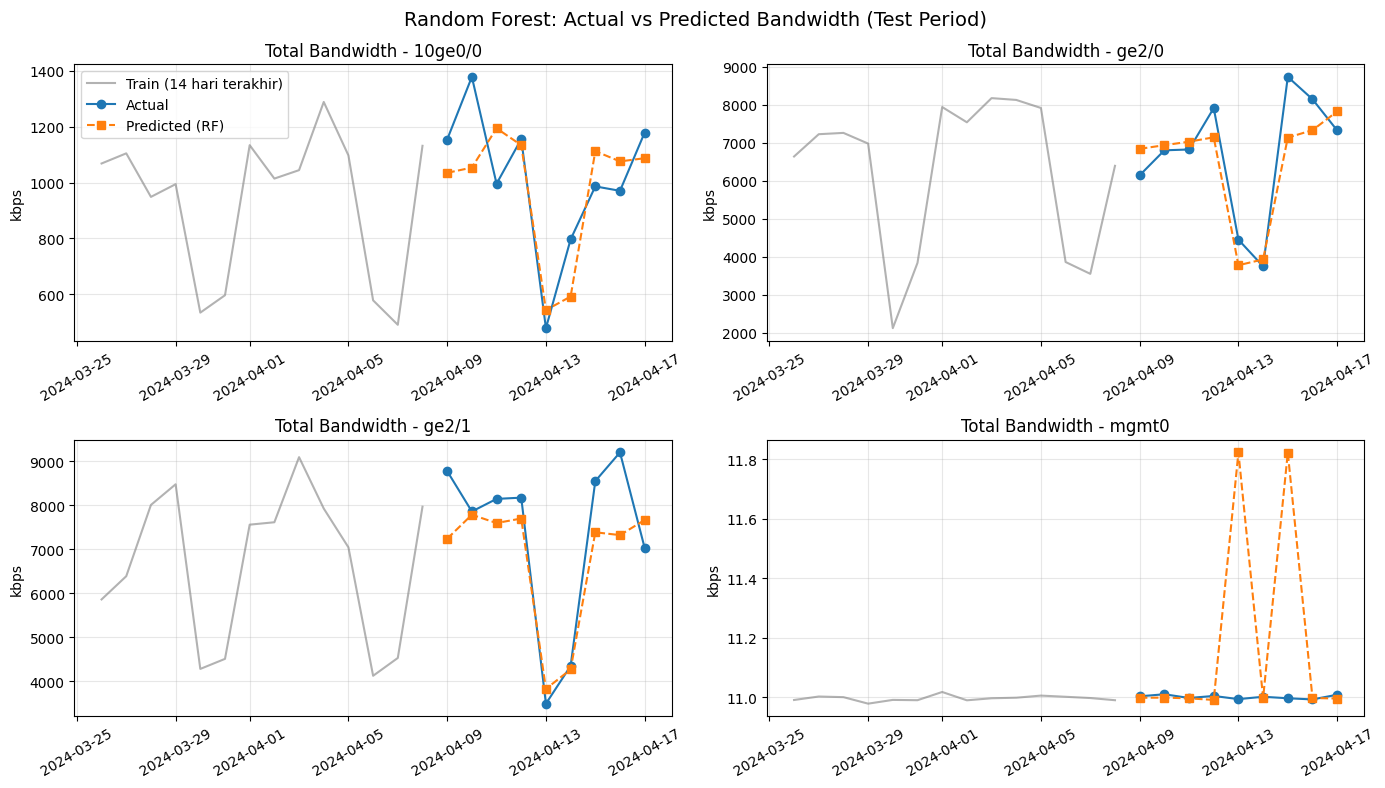

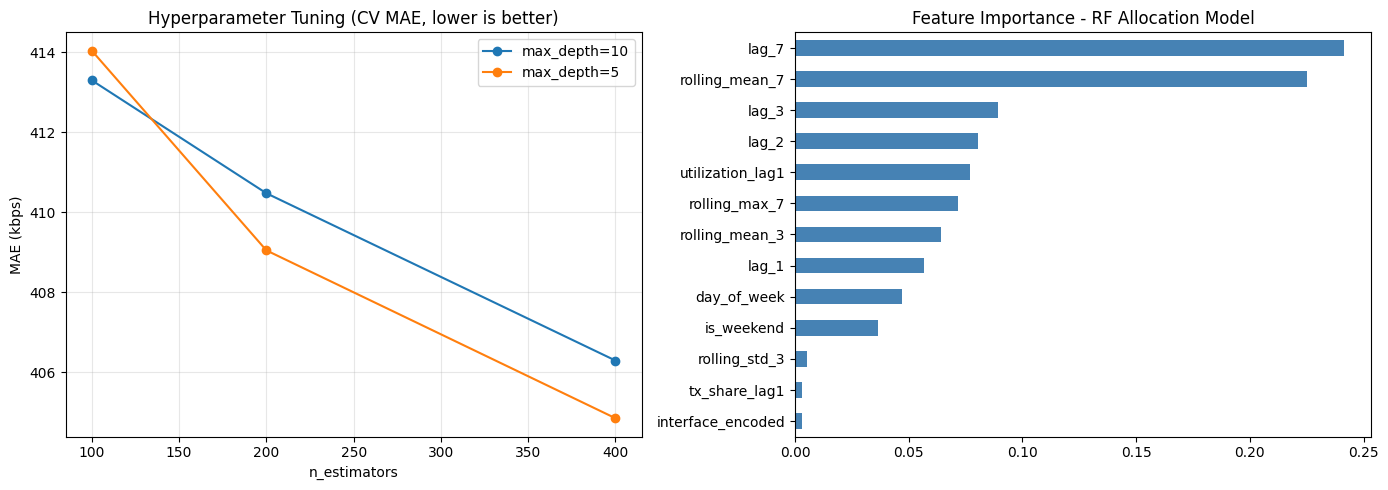


=== Rekomendasi Alokasi Bandwidth untuk 2024-04-18 ===


,predicted_demand_kbps,buffer_kbps,recommended_kbps,capacity_kbps,utilization_%,usage_level,high_priority,medium_priority,low_priority,spare_kbps
interface,,,,,,,,,,
10ge0/0,1082.9,281.0,1363.9,10000,13.6,LOW,409.2,545.5,409.2,8636.1
ge2/0,7647.2,1243.7,8890.9,10000,88.9,CRITICAL,5334.5,2667.3,889.1,1109.1
ge2/1,7687.3,1396.2,9083.5,10000,90.8,CRITICAL,5450.1,2725.1,908.4,916.5
mgmt0,11.0,0.6,11.6,10000,0.1,LOW,3.5,4.6,3.5,9988.4


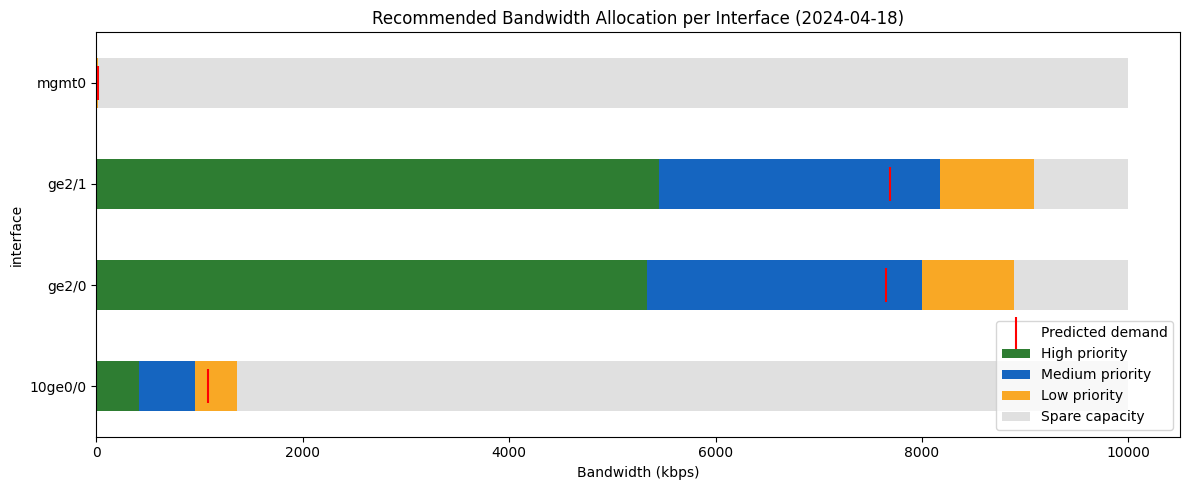

In [11]:
# ============================================================
# Random Forest Bandwidth Allocation Model
# ============================================================
# Alur:
# 1. Siapkan data per interface (tanpa membuang spike, karena spike
#    justru bagian dari kebutuhan bandwidth yang harus diantisipasi)
# 2. Bangun fitur historis (lag & rolling) untuk memprediksi
#    kebutuhan bandwidth total (tx + rx) periode berikutnya
# 3. Hyperparameter tuning Random Forest (GridSearchCV + TimeSeriesSplit)
# 4. Evaluasi di periode test & bandingkan dengan baseline naive
# 5. Prediksi kebutuhan periode berikutnya -> rekomendasi alokasi bandwidth

DATA_PATH = '../data/sample_hub_data.json'
HEADROOM_Z = 1.645   # buffer 95% (one-sided) di atas prediksi
RANDOM_STATE = 42

analyzer = BandwidthAnalyzer()
capacity = analyzer.interface_capacity

# ---------- 1. Persiapan data ----------
raw = analyzer.assess_data(analyzer.load_data(DATA_PATH))
df_alloc = (raw[raw['interface'].isin(capacity.keys())]
            .drop_duplicates()
            .sort_values(['entry_time', 'interface'])
            .reset_index(drop=True))
df_alloc['total_kbps'] = df_alloc['tx_kbps'] + df_alloc['rx_kbps']


# ---------- 2. Feature engineering (tanpa leakage) ----------
def build_allocation_features(data):
    d = data.copy().sort_values(['interface', 'entry_time'])
    d['day_of_week'] = d['entry_time'].dt.dayofweek
    d['is_weekend'] = d['day_of_week'].isin([5, 6]).astype(int)
    d['interface_encoded'] = d['interface'].map({k: i for i, k in enumerate(sorted(capacity))})
    g = d.groupby('interface')['total_kbps']
    for lag in [1, 2, 3, 7]:
        d[f'lag_{lag}'] = g.shift(lag)
    d['rolling_mean_3'] = g.transform(lambda s: s.shift(1).rolling(3).mean())
    d['rolling_std_3'] = g.transform(lambda s: s.shift(1).rolling(3).std())
    d['rolling_mean_7'] = g.transform(lambda s: s.shift(1).rolling(7).mean())
    d['rolling_max_7'] = g.transform(lambda s: s.shift(1).rolling(7).max())
    d['tx_share_lag1'] = d.groupby('interface')['tx_kbps'].shift(1) / (g.shift(1) + 1e-6)
    d['utilization_lag1'] = g.shift(1) / d['interface'].map(capacity) * 100
    return d.sort_values(['entry_time', 'interface'])

ALLOC_FEATURES = ['day_of_week', 'is_weekend', 'interface_encoded',
                  'lag_1', 'lag_2', 'lag_3', 'lag_7',
                  'rolling_mean_3', 'rolling_std_3', 'rolling_mean_7', 'rolling_max_7',
                  'tx_share_lag1', 'utilization_lag1']
TARGET = 'total_kbps'

feat = build_allocation_features(df_alloc).dropna(subset=ALLOC_FEATURES).reset_index(drop=True)

# Split kronologis berdasarkan tanggal (20% periode terakhir = test)
dates = np.sort(feat['entry_time'].unique())
cutoff = dates[int(len(dates) * 0.8)]
train = feat[feat['entry_time'] < cutoff]
test = feat[feat['entry_time'] >= cutoff]
X_tr, y_tr = train[ALLOC_FEATURES], train[TARGET]
X_te, y_te = test[ALLOC_FEATURES], test[TARGET]
print(f"Training: {len(train)} baris ({train['entry_time'].min().date()} s/d {train['entry_time'].max().date()})")
print(f"Testing : {len(test)} baris ({test['entry_time'].min().date()} s/d {test['entry_time'].max().date()})")

# ---------- 3. Hyperparameter tuning ----------
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 1.0],
}
search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=TimeSeriesSplit(n_splits=4),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
search.fit(X_tr, y_tr)
rf_alloc = search.best_estimator_
print("\nBest hyperparameters:", search.best_params_)
print(f"Best CV MAE: {-search.best_score_:.2f} kbps")

# ---------- 4. Evaluasi ----------
def regression_report(y_true, y_pred):
    return {
        'MAE (kbps)': mean_absolute_error(y_true, y_pred),
        'RMSE (kbps)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'WAPE (%)': np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100,
    }

pred_te = rf_alloc.predict(X_te)
eval_table = pd.DataFrame({
    'Random Forest (tuned)': regression_report(y_te, pred_te),
    'Baseline (nilai kemarin)': regression_report(y_te, test['lag_1']),
    'Baseline (rata-rata 7 hari)': regression_report(y_te, test['rolling_mean_7']),
}).T.round(3)
print("\n=== Evaluasi pada periode test ===")
display(eval_table)

# Visualisasi: actual vs predicted per interface
test_plot = test.assign(predicted=pred_te)
ifaces = sorted(test_plot['interface'].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, iface in zip(axes.flat, ifaces):
    t = test_plot[test_plot['interface'] == iface]
    hist = feat[(feat['interface'] == iface) & (feat['entry_time'] < cutoff)].tail(14)
    ax.plot(hist['entry_time'], hist[TARGET], color='gray', alpha=0.6, label='Train (14 hari terakhir)')
    ax.plot(t['entry_time'], t[TARGET], 'o-', label='Actual')
    ax.plot(t['entry_time'], t['predicted'], 's--', label='Predicted (RF)')
    ax.set_title(f'Total Bandwidth - {iface}')
    ax.set_ylabel('kbps')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)
axes.flat[0].legend()
plt.suptitle('Random Forest: Actual vs Predicted Bandwidth (Test Period)', fontsize=14)
plt.tight_layout()
plt.show()

# Visualisasi: hasil tuning & feature importance
cv_res = pd.DataFrame(search.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for depth, grp in cv_res.groupby(cv_res['param_max_depth'].astype(str)):
    best_per_n = grp.groupby('param_n_estimators')['mean_test_score'].max()
    axes[0].plot(best_per_n.index, -best_per_n.values, 'o-', label=f'max_depth={depth}')
axes[0].set_title('Hyperparameter Tuning (CV MAE, lower is better)')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('MAE (kbps)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
imp = pd.Series(rf_alloc.feature_importances_, index=ALLOC_FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance - RF Allocation Model')
plt.tight_layout()
plt.show()

# ---------- 5. Rekomendasi alokasi bandwidth ----------
# Buffer per interface dari error model di periode test
resid_std = (test_plot[TARGET] - test_plot['predicted']).groupby(test_plot['interface']).std()

# Refit model dengan seluruh data sebelum forecast periode berikutnya
rf_alloc.fit(feat[ALLOC_FEATURES], feat[TARGET])

last_time = df_alloc['entry_time'].max()
step = df_alloc['entry_time'].drop_duplicates().sort_values().diff().median()
next_time = last_time + step
future = pd.DataFrame({'entry_time': next_time, 'interface': sorted(capacity),
                       'tx_kbps': np.nan, 'rx_kbps': np.nan, 'total_kbps': np.nan})
future_feat = build_allocation_features(pd.concat([df_alloc, future], ignore_index=True))
future_feat = future_feat[future_feat['entry_time'] == next_time].copy()
future_feat['predicted_kbps'] = rf_alloc.predict(future_feat[ALLOC_FEATURES])

allocation_rules = {
    'critical': {'high_priority': 0.6, 'medium_priority': 0.3, 'low_priority': 0.1},
    'high':     {'high_priority': 0.5, 'medium_priority': 0.35, 'low_priority': 0.15},
    'medium':   {'high_priority': 0.4, 'medium_priority': 0.4, 'low_priority': 0.2},
    'low':      {'high_priority': 0.3, 'medium_priority': 0.4, 'low_priority': 0.3},
}

def usage_level(pct):
    if pct > 80:
        return 'critical'
    if pct > 60:
        return 'high'
    if pct > 40:
        return 'medium'
    return 'low'

rows = []
for _, r in future_feat.iterrows():
    cap = capacity[r['interface']]
    buffer = HEADROOM_Z * resid_std.get(r['interface'], 0)
    recommended = float(np.clip(r['predicted_kbps'] + buffer, 0, cap))
    level = usage_level(recommended / cap * 100)
    split = {k: round(v * recommended, 1) for k, v in allocation_rules[level].items()}
    rows.append({
        'interface': r['interface'],
        'predicted_demand_kbps': round(r['predicted_kbps'], 1),
        'buffer_kbps': round(buffer, 1),
        'recommended_kbps': round(recommended, 1),
        'capacity_kbps': cap,
        'utilization_%': round(recommended / cap * 100, 1),
        'usage_level': level.upper(),
        **split,
        'spare_kbps': round(cap - recommended, 1),
    })
recommendation = pd.DataFrame(rows).set_index('interface')
print(f"\n=== Rekomendasi Alokasi Bandwidth untuk {next_time.date()} ===")
display(recommendation)

# Visualisasi rekomendasi
bar_cols = {'high_priority': 'High priority', 'medium_priority': 'Medium priority',
            'low_priority': 'Low priority', 'spare_kbps': 'Spare capacity'}
ax = recommendation[list(bar_cols)].rename(columns=bar_cols).plot(
    kind='barh', stacked=True, figsize=(12, 5),
    color=['#2e7d32', '#1565c0', '#f9a825', '#e0e0e0'])
ax.scatter(recommendation['predicted_demand_kbps'], range(len(recommendation)),
           color='red', marker='|', s=600, zorder=5, label='Predicted demand')
ax.set_xlabel('Bandwidth (kbps)')
ax.set_title(f'Recommended Bandwidth Allocation per Interface ({next_time.date()})')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
